# Adaptive Quadtree Matching Pursuit (AQMP) Optimization

### Steps to Follow:

1. **Convert Image Format**  
   - Transform the downloaded images from `.tiff` format to `.png`.


2. **Optimize Adaptive Quadtree Matching Pursuit (AQMP)**  
   - Utilize **Optuna** with the **Tree-structured Parzen Estimator (TPE)** search algorithm for hyperparameter optimization.  
   - **Image Sources**:  
     - The images are sourced from [USC-SIPI Image Database](https://sipi.usc.edu/database/).  
     - Additional context: Images from the same database were used in [this study](https://www.tandfonline.com/doi/epdf/10.1080/09500340.2016.1270881?needAccess=true) to explore Lenna variants.


3. **Compare Search Methods**
   - Analyze the effectiveness of the TPE-based optimization against a **Random Search** strategy for hyperparameter tuning.


4. **Compress with MP and Fixed Block Size**  
   - Compare the AQMP approach with a traditional fixed block size method to assess the advantages of adaptivity.

5. **Evaluate Against Quadtree compression with no Matching Pursuit**  

6. **Evaluate Against JPEG**  


# 1. Initial Settings

In [99]:
import sys
import os
import numpy as np
from datetime import datetime
import time
import pickle
import pandas as pd
from PIL import Image

sys.path.append(os.path.abspath(os.path.join('..')))

from aqmp import ImageCompressor

import warnings
from skimage import io, img_as_float
from skimage.metrics import structural_similarity as ssim
                
import plotly
from plotly.io import show
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.samplers import RandomSampler

#tumbnail packages
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# plt.rcParams['font.size'] = 18

plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 14,     # title
    "axes.labelsize": 13,     # x/y labels
    "xtick.labelsize": 11,    
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    'legend.title_fontsize': 12  # global title size
    
})


# Suppress all Optuna logs (only critical errors will be shown)
#optuna.logging.set_verbosity(optuna.logging.ERROR)

In [11]:
def jpeg_compress_and_evaluate(image_path, output_path, quality):
    # Function to compress an image and calculate SSIM and compression rate
    
    # Load the original image
    original_img = Image.open(image_path)
    
    # Save the compressed image
    compressed_image_path = f"{output_path}_q{quality}.jpg"
    original_img.save(compressed_image_path, "JPEG", quality=quality) # , subsampling=0)
    
    # Compute SSIM
    ssim_value = calculate_ssim(image_path, compressed_image_path)    
    
    # Compute compression rate
    original_size = os.path.getsize(image_path)
    compressed_size = os.path.getsize(compressed_image_path)
    compression_rate = original_size / compressed_size

    return ssim_value, compression_rate

def calculate_ssim(image_path1, image_path2):
    """
    Calculate SSIM dynamically based on whether the images are grayscale or multichannel.
    
    Args:
        image_path1 (str): Path to the first image.
        image_path2 (str): Path to the second image.
        
    Returns:
        float: SSIM index.
    """
    # Load images
    image1 = img_as_float(io.imread(image_path1))
    image2 = img_as_float(io.imread(image_path2))
    
    # Determine if the images are multichannel (check number of dimensions)
    if image1.ndim == 3 and image1.shape[-1] in [3, 4]:  # RGB or RGBA
        ssim_index = ssim(image1, image2, data_range=image1.max() - image1.min(), channel_axis=2)
    else:  # Grayscale
        ssim_index = ssim(image1, image2, data_range=image1.max() - image1.min())
    
    return ssim_index

# Function to get all image file names in the folder
def get_images_from_folder(folder_path):
    supported_formats = (".png",) #".jpg", ".jpeg", ".bmp", ".tiff")
    return [f[:-4] for f in os.listdir(folder_path) if f.lower().endswith(supported_formats)]

# Function to get all image file names in the folder
def get_jpg_images_from_folder(folder_path):
    supported_formats = (".jpg",) #".jpg", ".jpeg", ".bmp", ".tiff")
    return [f[:-4] for f in os.listdir(folder_path) if f.lower().endswith(supported_formats)]

def save_and_show_plot(fig, file_name):
    """Save and display the plot."""
    plt.ylim(0, 1) 
    fig.savefig(file_name, dpi=300)
    #print(f"{file_name} saved")
    #plt.show()

def plot_compression_vs_ssim(compression_rates, ssim_values, plot_name, log_xscale):
    """Plot compression rate vs SSIM for all trials."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(compression_rates, ssim_values, "o", label="All Trials")
    ax.set_xlabel('Compression Rate')
    ax.set_ylabel('SSIM')
    if log_xscale:
        ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    save_and_show_plot(fig, f"{plot_name}_compression_vs_ssim.png")



def plot_pareto_front(compression_rates, ssim_values, pareto_compression, pareto_ssim, plot_name, image_name, thumbnail = False):
    """Plot Pareto front and all trials."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(compression_rates, ssim_values, color="grey", label="All Trials")
    ax.plot(pareto_compression, pareto_ssim, 'o--', color="red", label="Pareto Front", markersize=6)

    if thumbnail:
        img = mpimg.imread("test_images/"+image_name+".png")
        # Create main plot
        # Create inset axes: position = [left, bottom, width, height] in axes fraction
        ax = inset_axes(ax, width="25%", height="25%", loc='upper right')
        # Show image inside the inset
        ax.imshow(img)
        ax.axis('off') # Hide axis around image

    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.grid(True)
    plt.ylim(0, 1) 
    ax.legend()
    
    fig.savefig(f"{image_name}_pareto_front.png", dpi=300)
    plt.show()
    
"""
def plot_pareto_front(ax, study, color, label):
    """'Extract and plot the Pareto front for a given study. Also print hyperparams, compression rate, and SSIM.'"""
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])  # sort by compression rate

    pareto_compression = []
    pareto_ssim = []

    #print(f"\n--- Pareto front for study: {study.study_name} ---")
    for trial in pareto_front:
        compression = trial.values[0]
        ssim = trial.values[1]
        params = trial.params

        pareto_compression.append(compression)
        pareto_ssim.append(ssim)

       # print(f"Compression: {compression:.4f}, SSIM: {ssim:.4f}, Hyperparams: {params}")

    ax.plot(pareto_compression, pareto_ssim, 'o--', color=color, label=label, markersize=6)
"""
    
def plot_results(study, plot_name="test", log_xscale=False, image_name="image", thumbnail=None):
    """Main function to plot results from the study."""
    plt.rcParams['font.size'] = 18

    # Collect data from trials
    compression_rates = [trial.user_attrs["compression_rate"] for trial in study.trials]
    ssim_values = [trial.user_attrs["ssim"] for trial in study.trials]

    #plot_compression_vs_ssim(compression_rates, ssim_values, plot_name, log_xscale)

    # Extract Pareto front data
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])  # Sort by compression or another objective
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]

    #print("Results for image:", image_name)

    plot_pareto_front(compression_rates, ssim_values, pareto_compression, pareto_ssim, plot_name, image_name, thumbnail)

def convert_tiff_to_png(folder_path):
    # List all files in the folder
    for filename in os.listdir(folder_path):
        if filename.lower().endswith('.tiff'):
            # Construct full file paths
            tiff_path = os.path.join(folder_path, filename)
            png_filename = filename.rsplit('.', 1)[0] + '.png'
            png_path = os.path.join(folder_path, png_filename)
            
            try:
                # Open and convert the TIFF to PNG
                with Image.open(tiff_path) as img:
                    img.save(png_path, format='PNG')
                print(f"Converted: {filename} -> {png_filename}")
            except Exception as e:
                print(f"Failed to convert {filename}: {e}")

def plot_given_studies(study_names, storage_path="sqlite:///aqmp_studies.db", total_trials = 100):
    fig, ax = plt.subplots(figsize=(10, 6))

    color_map = {
        'TPE': 'red',
        'RandomSampler': 'orange',
        'no_AQ': 'blue'
    }

    for name in study_names:
        study = optuna.load_study(study_name=name, storage=storage_path)
        trials = study.trials
        trial_states = [t.state for t in trials]

        # Filter condition: exactly 100 COMPLETE trials
        if len(trials) == total_trials and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
            # Determine label + color
            if "no_AQ" in name:
                color = color_map['no_AQ']
                label = "MP with Random Sampler"
            elif "RandomSampler" in name:
                color = color_map['RandomSampler']
                label = "AQMP with Random Sampler"
            elif "TPE" in name:
                color = color_map['TPE']
                label = "AQMP with TPE"
            else:
                color = 'gray'
                label = name

            plot_pareto_front(ax, study, color=color, label=label)
        else:
            print(f"Skipping {name} (not {total_trials} complete trials)")

    # Finalize plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    #ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# 2. AQMP with TPE Search

- min_sparcity: porcentaje máximo de coeficientes diferentes de cero permitidos en un cuadrante. Si no se cumple, se particiona en cuatro nuevos cuadrantes.
- max_error: ('tol' argument of OMP) Maximum squared norm of the residual.

In [28]:
def objective(trial):
    #print("image name: ", image_name)
    min_sparcity = trial.suggest_float('min_sparcity', 0.01, 1)
    exponent_min_n = trial.suggest_int('exponent_min_n', 2, 7)
    exponent_max_n = trial.suggest_int('exponent_max_n', exponent_min_n, 7)
    #exponent_max_n = trial.suggest_int('exponent_max_n', 2, 7)
    max_error = trial.suggest_float('max_error', 0.001, 1000, log = True)
    exponent_a_cols = trial.suggest_int("exponent_a_cols", 1, 8)

    a_cols = 2**exponent_a_cols
    min_n = 2**exponent_max_n
    max_n = 2**exponent_max_n
    #print(max_n, min_n)
    assert max_n >= min_n

    #folder_path = "../images/Color/512x512/"
    input_image_path = folder_path+image_name+".png"
    fif_image_path = "compressions/"+image_name+".fif"
    output_image_path = "compressions/"+image_name+"_reconstructed.png"
    
    # ENCODE
    start_time = time.time()    
    newCodec = ImageCompressor(min_sparcity = min_sparcity,
                               min_n = min_n,
                               max_n = max_n,
                               max_error = max_error,
                               a_cols = a_cols,
                               apply_deflate=True
                              )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        newCodec.encode(input_file=input_image_path,
                        output_file=fif_image_path)

    # DECODE
    newCodec.decode(input_file=fif_image_path,
                    output_file=output_image_path)
    end_time = time.time()
    execution_time = end_time - start_time
    #print("execution_time", execution_time)

    # CALCULATE SSIM
    ssim_index = calculate_ssim(input_image_path, output_image_path)
    #print(f"SSIM Index : {ssim_index}\n")

    # COMPRESSION RATE
    image_size = os.path.getsize(input_image_path)
    compressed_image_size = os.path.getsize(output_image_path)
    compression_rate = image_size / compressed_image_size

    # Store additional information in trial attributes
    trial.set_user_attr("execution_time", execution_time)
    trial.set_user_attr("ssim", ssim_index)
    trial.set_user_attr("compression_rate", compression_rate)

    return compression_rate, ssim_index

In [10]:
pwd

'/Users/fcerino/Documents/projects/AQMP/notebooks'

In [30]:
# Get all image names in the folder
folder_path = '../images/DIV2K_valid_HR/DIV2K_valid_HR/'# 'test_images/' # "../images/Color/256x256/"
test_images = get_images_from_folder(folder_path)
test_images

['0878',
 '0850',
 '0844',
 '0893',
 '0887',
 '0886',
 '0892',
 '0845',
 '0851',
 '0879',
 '0847',
 '0853',
 '0884',
 '0890',
 '0891',
 '0885',
 '0852',
 '0846',
 '0842',
 '0856',
 '0881',
 '0895',
 '0894',
 '0880',
 '0857',
 '0843',
 '0855',
 '0841',
 '0869',
 '0896',
 '0882',
 '0883',
 '0897',
 '0868',
 '0840',
 '0854',
 '0833',
 '0827',
 '0826',
 '0832',
 '0818',
 '0824',
 '0830',
 '0831',
 '0825',
 '0819',
 '0821',
 '0835',
 '0809',
 '0808',
 '0834',
 '0820',
 '0836',
 '0822',
 '0823',
 '0837',
 '0812',
 '0806',
 '0807',
 '0813',
 '0839',
 '0805',
 '0811',
 '0810',
 '0804',
 '0838',
 '0814',
 '0828',
 '0829',
 '0815',
 '0801',
 '0817',
 '0803',
 '0802',
 '0816',
 '0859',
 '0871',
 '0865',
 '0864',
 '0870',
 '0858',
 '0866',
 '0872',
 '0899',
 '0898',
 '0873',
 '0867',
 '0863',
 '0877',
 '0888',
 '0889',
 '0876',
 '0862',
 '0900',
 '0874',
 '0860',
 '0848',
 '0849',
 '0861',
 '0875']

In [ ]:
n_trials = 100
seed = 42
for image_name in test_images:
    current_time = datetime.now().strftime("%Y-%m-%d")
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{current_time}"
    sampler = TPESampler(seed=42)
    study = optuna.create_study(directions=['maximize', 'maximize'],
                                study_name=study_name,
                                sampler=sampler,
                                storage="sqlite:///optuna.db"  )
    study.optimize(objective, n_trials=100)

    plot_results(study, log_xscale=True)

[I 2025-09-19 16:59:34,668] A new study created in memory with name: multiobjTPE_trials:100_seed:43_image:0852_time:2025-09-19_16-59-34


image size: (2040, 1152)
3


[I 2025-09-19 16:59:54,212] Trial 0 finished with values: [13.673268045596068, 0.5998221337212409] and parameters: {'min_sparcity': 0.12390402072588116, 'exponent_min_n': 5, 'exponent_max_n': 5, 'max_error': 0.027767560053080172, 'exponent_a_cols': 3}.


image size: (2040, 1152)
3


[I 2025-09-19 17:00:13,446] Trial 1 finished with values: [8.136972583625408, 0.5687514420641621] and parameters: {'min_sparcity': 0.8605461160391117, 'exponent_min_n': 5, 'exponent_max_n': 6, 'max_error': 0.0014930795478222975, 'exponent_a_cols': 6}.


...

image size: (2040, 1152)
3


[I 2025-09-19 17:05:33,304] Trial 14 finished with values: [126.89258818866429, 0.4993421685196666] and parameters: {'min_sparcity': 0.6732890066568104, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 47.322697722237464, 'exponent_a_cols': 3}.


image size: (2040, 1152)
3


[I 2025-09-19 17:05:45,392] Trial 15 finished with values: [36.50055295230929, 0.5431773282807214] and parameters: {'min_sparcity': 0.30753292948838284, 'exponent_min_n': 6, 'exponent_max_n': 6, 'max_error': 2.3736281709079954, 'exponent_a_cols': 2}.


image size: (2040, 1152)
3


In [22]:
plot_results(study, log_xscale=True)

KeyError: 'compression_rate'

# 3. AQMP with Random Search 

Results for image: image
Results for image: image


KeyboardInterrupt: 

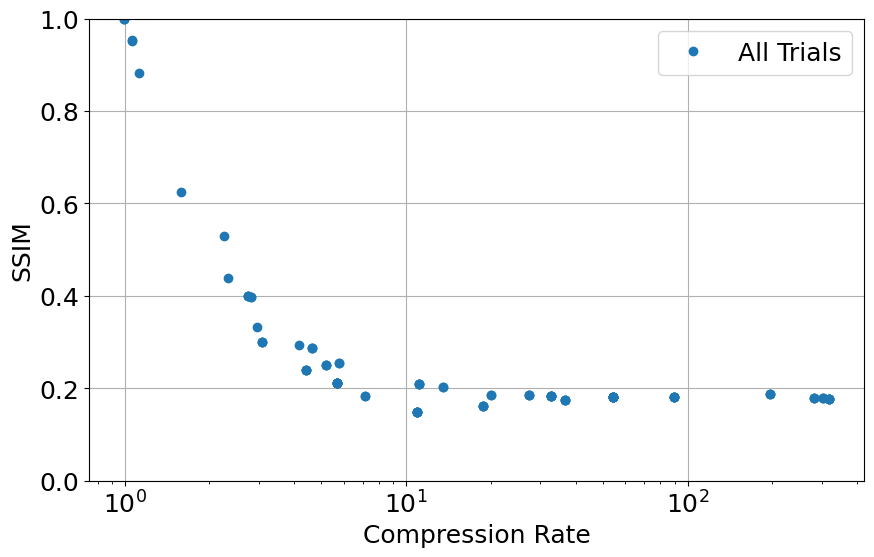

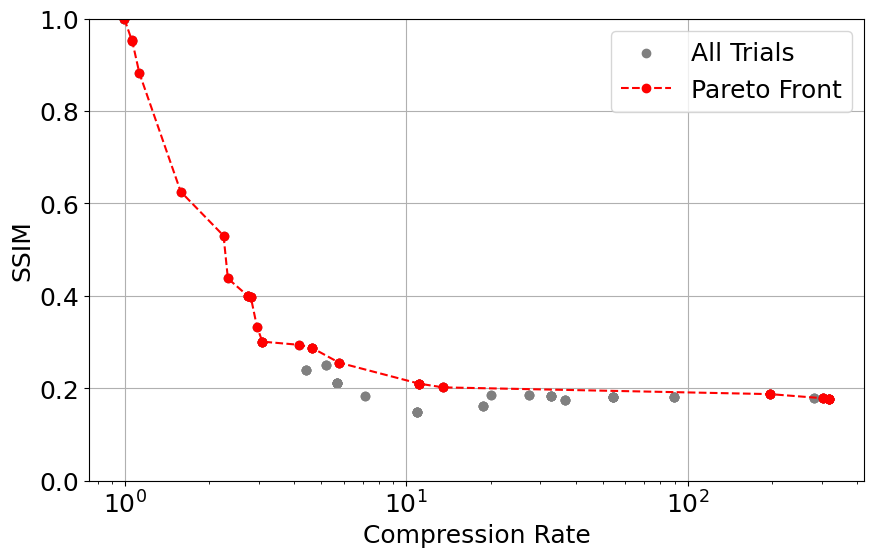

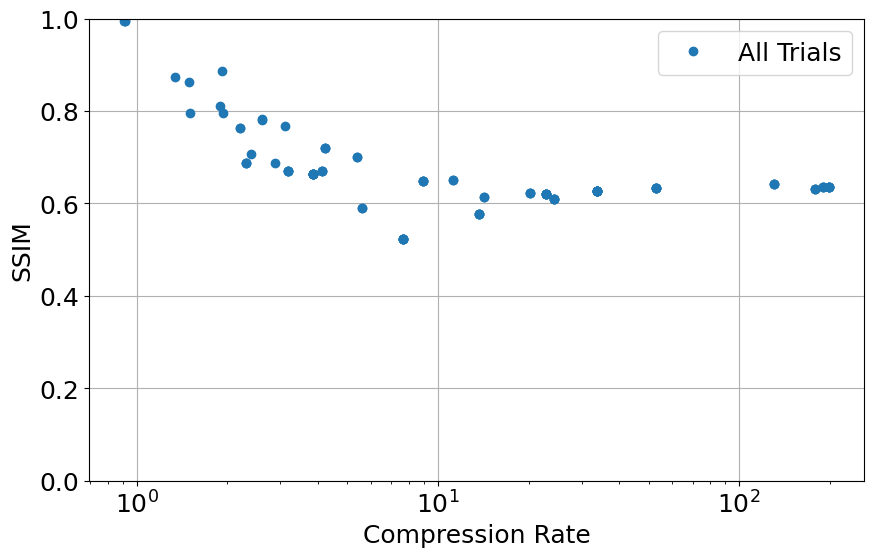

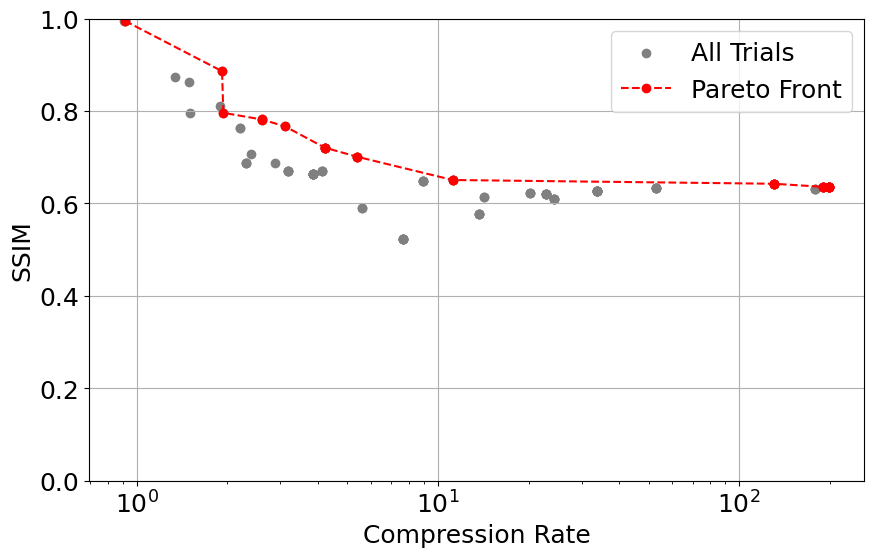

In [10]:
seed = 43
n_trials = 100

# search best hyperparameters of AQMP for each test image
for image_name in test_images:    
    # create study and begin to optimize
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    study_name = f"multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{current_time}"
    storage_path = "sqlite:///"+study_name+".db" 
    sampler = RandomSampler(seed=seed)  # Make the sampler behave in a deterministic way
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    plot_results(study, plot_name="../images/results/"+"random_sampler_"+image_name, log_xscale=True)    

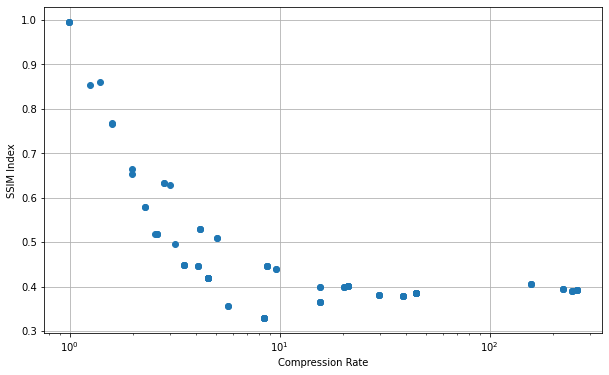

results for image  4.2.07


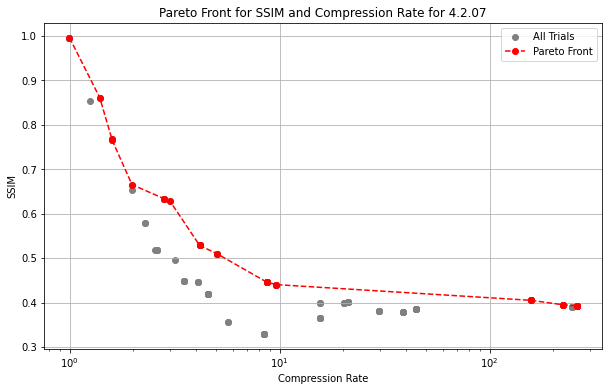

In [18]:
plot_results(study, log_xscale=True)

# 4. MP and Fixed Block Size (no AQ)

In [7]:
def objective_no_aq(trial):
    #exponent_min_n = trial.suggest_int('exponent_min_n', 2, 7)
    exponent_a_cols = trial.suggest_int("exponent_a_cols", 1, 8)    
    min_sparcity = trial.suggest_float('min_sparcity', 0.01, 1)
    max_error = trial.suggest_float('max_error', 0.001, 1000, log = True)

    ### old runs
    # exponent_min_n = trial.suggest_int('exponent_min_n', 3, 7)
    # exponent_a_cols = 8
    ###
    
    a_cols = 2**exponent_a_cols

    exponent_min_n = 3
    exponent_max_n = exponent_min_n # exponent_min_n # trial.suggest_int('exponent_max_n', exponent_min_n, 7)
    min_n = 2**exponent_min_n
    max_n = 2**exponent_max_n
    print(max_n, min_n)
    assert max_n >= min_n

    #print("image name: ", image_name)
    #folder_path = "../images/Color/512x512/"
    input_image_path = folder_path+image_name+".png"
    output_image_path = "../compressions/"+image_name+"_reconstructed.png"
    fif_image_path ="../compressions/"+image_name+".fif"

    # ENCODE
    start_time = time.time()    
    newCodec = ImageCompressor(min_sparcity = min_sparcity,
                               min_n = min_n,
                               max_n = max_n,
                               max_error = max_error,
                               a_cols = a_cols,
                               apply_deflate=True
                              )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        newCodec.encode(input_file=input_image_path, output_file=fif_image_path)

    # DECODE
    newCodec.decode(input_file=fif_image_path, output_file=output_image_path)
    end_time = time.time()
    execution_time = end_time - start_time
    #print("execution_time", execution_time)

    # CALCULATE SSIM
    ssim_index = calculate_ssim(input_image_path, output_image_path)
    #print(f"SSIM Index : {ssim_index}\n")

    # COMPRESSION RATE
    image_size = os.path.getsize(input_image_path)
    compressed_image_size = os.path.getsize(output_image_path)
    compression_rate = image_size / compressed_image_size

    # Store additional information in trial attributes
    trial.set_user_attr("execution_time", execution_time)
    trial.set_user_attr("ssim", ssim_index)
    trial.set_user_attr("compression_rate", compression_rate)

    return compression_rate, ssim_index

In [ ]:
seed = 43
n_trials = 100
for image_name in test_images:
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{current_time}"
    storage_path = "sqlite:///"+study_name+".db" 
    sampler = RandomSampler(seed=seed)  # Make the sampler behave in a deterministic way
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    plot_results(study, plot_name="../images/results/"+"MP_no_AQ_random_sampler_"+image_name, log_xscale=True)    

comparisons

- fixed size block
- aqmp with random search (100 iterations)
- aqmp with TPE search (100 iterations)
- quadtree standard
- jpeg



- [x] guardar todas las imagenes
- [X] poner DEFLATE = True
- [x] agregar guardado de imagenes, dpi 300

# 5. Compress with Quadtrees and no MP

This library implements an image compression algorithm that is based on quadtrees with no MP:

- https://github.com/Inspiaaa/QuadTreeImageCompression

In [ ]:
sys.path.append('/home/fcerino/Documents/proyectos/AQMP')
from quad_tree_compression import compress_image_file, reconstruct_image_from_file, compress_image_data

In [ ]:
folder_path = "../images/Color/512x512/"
input_image = folder_path+f"{image_name}.png"
output_image = f"../compressions/{image_name}.qid"
set_iterations = [5, 10, 100, 1000, 5000, 10_000, 20_000]
for image_name in test_images:
    plt.figure(figsize=(10, 6))  # Adjust the size (width, height in inches)
    plt.xscale("log")
    ssim_values = []
    size_ratio_values = []
    for iterations in set_iterations:
        #print(iterations)
        # Compress the image and encode is a binary file (any file extension can be chosen)
        compress_image_file(input_image, output_image, iterations=iterations)

        # Reconstruct the image from the binary file. (Returns a PIL.Image object)
        image = reconstruct_image_from_file(output_image)

        # image.show()

        # Load the image and convert it to a numpy array
        image = Image.open(input_image)
        image_data = np.array(image)

        # Compress the image
        compressed_data = compress_image_data(image_data, iterations=iterations)

        # Show the simplified image
        compressed_image = Image.fromarray(compressed_data)
        #compressed_image.show()

        # Save the image as a PNG file
        compressed_image.save(output_image, "PNG")

        # Get file sizes
        size1 = os.path.getsize(input_image)
        size2 = os.path.getsize(output_image)

        # Calculate file size ratio
        size_ratio = size1 / size2
        size_ratio_values.append(size_ratio)
        #print(f"File Size Ratio (input/output): {size_ratio:.2f}")

        # Open the images and calculate ssim
        ssim_value = calculate_ssim(input_image, output_image)

        ssim_values.append(ssim_value)
        #print(f"SSIM: {ssim}")

    # Plot compression rate vs SSIM
    plot_compression_vs_ssim(compression_rates,
                             ssim_values,
                             plot_name="../images/results/"+"quadtree_no_MP_"+image_name,
                             log_xscale=True
                        )

# 6. Compress with JPEG

In [ ]:
for image_name in test_images:
    image_path = f"../images/Color/512x512/{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    compression_ssim_path = "../images/results/"+"JPEG_"+image_name
    
    qualities = range(2, 101, 5) # Range of qualities for JPEG compression
    ssim_values = []
    compression_rates = []
    for quality in qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)

    plot_compression_vs_ssim(compression_rates,
                             ssim_values,
                             plot_name=compression_ssim_path,
                             log_xscale=True
                        )

# notas

In [13]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 100
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[2:]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    

    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

NameError: name 'test_images' is not defined

image name: Sailboat_on_lake


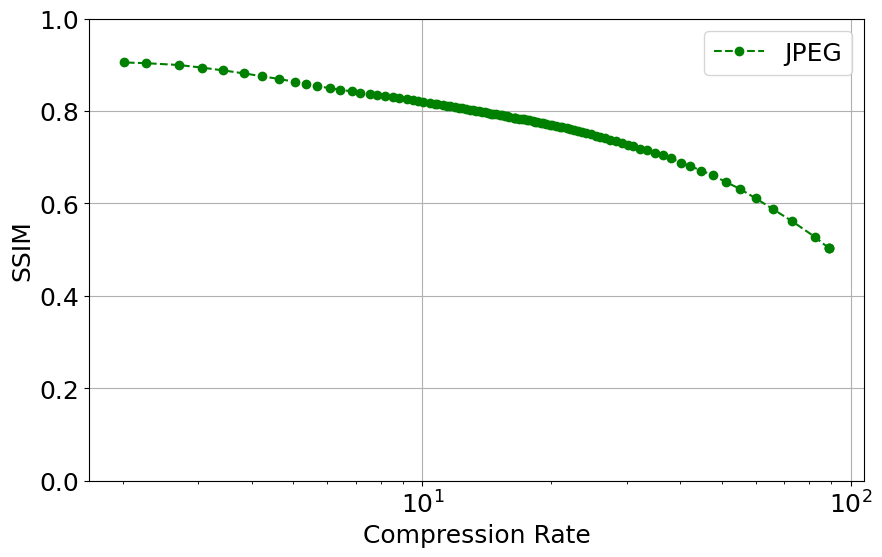

In [20]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 100
jpeg_qualities = range(101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[:1]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    #file_name = f"{image_name}_comparison_pareto_fronts.png"
    #fig.savefig(file_name, dpi=300)
    plt.show()

image name: Sailboat_on_lake


[I 2025-04-09 07:22:05,810] A new study created in RDB with name: multiobjTPE_trials:30_seed:43_image:Sailboat_on_lake_time:2025-04-09_07-22-05
[I 2025-04-09 07:22:07,940] Trial 0 finished with values: [9.557219433336169, 0.3830938056822725] and parameters: {'min_sparcity': 0.12390402072588116, 'exponent_min_n': 5, 'exponent_max_n': 5, 'max_error': 0.027767560053080172, 'exponent_a_cols': 3}.
[I 2025-04-09 07:22:10,183] Trial 1 finished with values: [7.401164935954879, 0.3441759799184621] and parameters: {'min_sparcity': 0.8605461160391117, 'exponent_min_n': 5, 'exponent_max_n': 6, 'max_error': 0.0014930795478222975, 'exponent_a_cols': 6}.
[I 2025-04-09 07:22:13,168] Trial 2 finished with values: [4.27573028404376, 0.39811131712017983] and parameters: {'min_sparcity': 0.4010005182466958, 'exponent_min_n': 6, 'exponent_max_n': 6, 'max_error': 0.0021943688007952746, 'exponent_a_cols': 7}.
[I 2025-04-09 07:22:19,686] Trial 3 finished with values: [2.4866619143971627, 0.5419376101376653] a

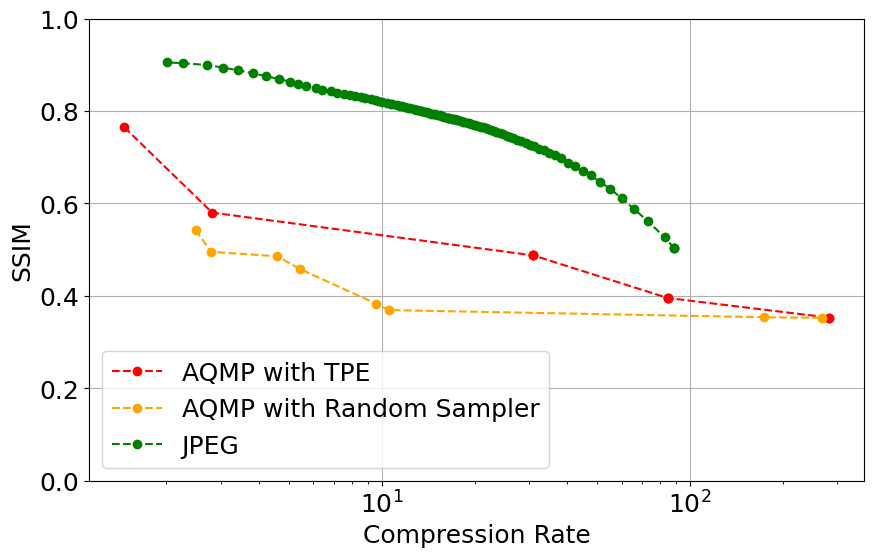

In [23]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 30
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[:1]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    

    # Study without AQ (Random Sampler)
    #study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    #sampler = RandomSampler(seed=seed)
    #study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    #study.optimize(objective_no_aq, n_trials=n_trials)
    #plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    #fig.savefig(file_name, dpi=300)
    plt.show() # jpeg_demo

que es quality?

define la cuantizacion de los coeficientes de DCT de la imagen en cuestion.

a mayor valor de quality se tiene menos contribuciones de los pesos, dando mas compresion y mas perdida de calidad.

empieza en ssim similar a 0.9 porque primero hay un subsampleo

image name: Sailboat_on_lake


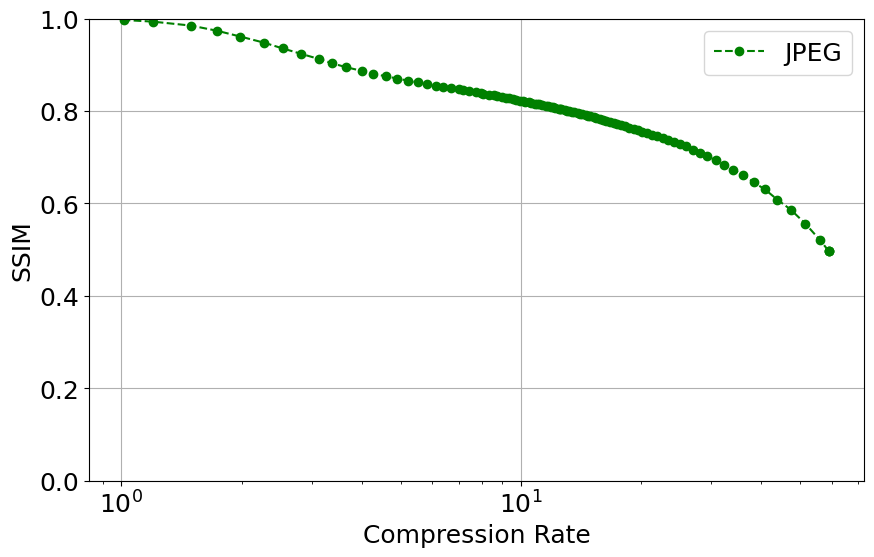

In [46]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 100
jpeg_qualities = range(101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[:1]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    plt.show()

In [9]:
storage_path = "sqlite:///aqmp_studies.db"
study_summaries = optuna.study.get_all_study_summaries(storage=storage_path)

fully_completed_studies = []

for summary in study_summaries:
    study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
    trial_states = [trial.state for trial in study.trials]
    
    if all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
        fully_completed_studies.append(summary.study_name)

# Print the names
for name in fully_completed_studies:
    print(name)

multiobjTPE_trials:3_seed:43_image:4.2.03_time:2025-04-03_16-23-15
multiobjRandomSampler_trials:3_seed:43_image:4.2.03_time:2025-04-03_16-23-15
MP_no_AQ_multiobj_random_sampler_trials:3_seed:43_image:4.2.03_time:2025-04-03_16-23-15
multiobjTPE_trials:3_seed:43_image:4.2.01_time:2025-04-03_16-25-30
multiobjRandomSampler_trials:3_seed:43_image:4.2.01_time:2025-04-03_16-25-30
MP_no_AQ_multiobj_random_sampler_trials:3_seed:43_image:4.2.01_time:2025-04-03_16-25-30
multiobjTPE_trials:3_seed:43_image:4.2.05_time:2025-04-03_16-27-12
multiobjRandomSampler_trials:3_seed:43_image:4.2.05_time:2025-04-03_16-27-12
MP_no_AQ_multiobj_random_sampler_trials:3_seed:43_image:4.2.05_time:2025-04-03_16-27-12
multiobjTPE_trials:3_seed:43_image:4.2.06_time:2025-04-03_16-28-51
multiobjRandomSampler_trials:3_seed:43_image:4.2.06_time:2025-04-03_16-28-51
MP_no_AQ_multiobj_random_sampler_trials:3_seed:43_image:4.2.06_time:2025-04-03_16-28-51
multiobjTPE_trials:3_seed:43_image:4.2.07_time:2025-04-03_16-30-49
multi

In [48]:
valid_studies = []
for summary in study_summaries:
    study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
    trials = study.trials
    trial_states = [trial.state for trial in trials]
    
    if len(trials) == 100 and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
        valid_studies.append(summary.study_name)

for s in valid_studies:
    print(s)

KeyError: 'Record does not exist.'

In [5]:
valid_studies = []
for summary in study_summaries:
    study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
    trials = study.trials
    trial_states = [trial.state for trial in trials]
    
    if len(trials) == 100 and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
        valid_studies.append(summary.study_name)

for s in valid_studies:
    print(s)

NameError: name 'study_summaries' is not defined

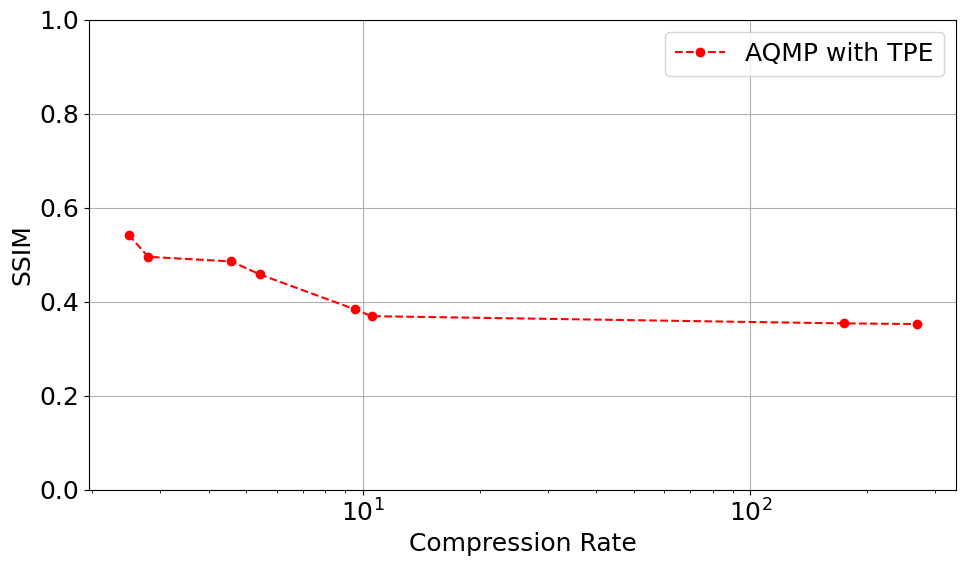

In [79]:
def plot_all_studies():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    storage_path = "sqlite:///aqmp_studies.db"
    
    color_map = {
        'TPE': 'red',
        'RandomSampler': 'orange',
        'no_AQ': 'blue'
    }
    
    study_summaries = optuna.study.get_all_study_summaries(storage=storage_path)

    valid_studies = get_fully_completed_studies()
    for summary in valid_studies[:1]:
        # Determine color and label based on naming
        study_name = summary.study_name
        if "no_AQ" in study_name:
            color = color_map['no_AQ']
            label = "MP with Random Sampler"
        elif "RandomSampler" in study_name:
            color = color_map['RandomSampler']
            label = "AQMP with Random Sampler"
        elif "TPE" in study_name:
            color = color_map['TPE']
            label = "AQMP with TPE"
        else:
            color = 'gray'
            label = study_name  # fallback
    
        plot_pareto_front(ax, study, color=color, label=label)

    # Finalize plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

plot_all_studies()

In [4]:
def get_fully_completed_studies(storage_path="sqlite:///aqmp_studies.db", n_trials_required=100):
    study_summaries = optuna.study.get_all_study_summaries(storage=storage_path)
    valid_studies = []

    for summary in study_summaries:
        study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
        trials = study.trials
        trial_states = [t.state for t in trials]

        if len(trials) == n_trials_required and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
            valid_studies.append(study)

    return valid_studies



--- Pareto front for study: multiobjTPE_trials:100_seed:43_image:San_Francisco_time:2025-04-08_12-52-40 ---
Compression: 0.9559, SSIM: 0.9921, Hyperparams: {'min_sparcity': 0.25271407432092585, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 6.455441028612041, 'exponent_a_cols': 8}
Compression: 0.9812, SSIM: 0.9844, Hyperparams: {'min_sparcity': 0.4636144957904471, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 0.014166427131253682, 'exponent_a_cols': 6}
Compression: 1.2245, SSIM: 0.9312, Hyperparams: {'min_sparcity': 0.32721356670099766, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 111.39277639782031, 'exponent_a_cols': 6}
Compression: 1.6578, SSIM: 0.8429, Hyperparams: {'min_sparcity': 0.5003357002399738, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 155.23479517688085, 'exponent_a_cols': 5}
Compression: 1.7897, SSIM: 0.7786, Hyperparams: {'min_sparcity': 0.2979223966459267, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 1.486430826627794, '

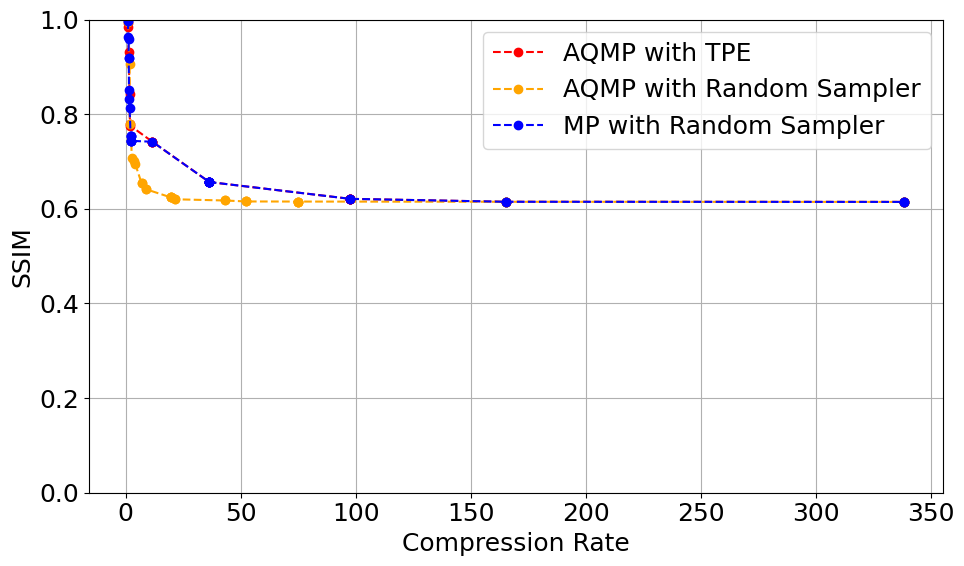

In [130]:
plot_given_studies([
'multiobjTPE_trials:100_seed:43_image:San_Francisco_time:2025-04-08_12-52-40',
'multiobjRandomSampler_trials:100_seed:43_image:San_Francisco_time:2025-04-08_12-52-40',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:San_Francisco_time:2025-04-08_12-52-40'
])


--- Pareto front for study: multiobjTPE_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55 ---
Compression: 0.9968, SSIM: 0.9991, Hyperparams: {'min_sparcity': 0.8248671158162981, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.002767377631559487, 'exponent_a_cols': 7}
Compression: 1.0511, SSIM: 0.9460, Hyperparams: {'min_sparcity': 0.4234097178369484, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 517.2628843998739, 'exponent_a_cols': 8}
Compression: 1.1735, SSIM: 0.8832, Hyperparams: {'min_sparcity': 0.6165969061714877, 'exponent_min_n': 4, 'exponent_max_n': 4, 'max_error': 35.73352702859344, 'exponent_a_cols': 8}
Compression: 1.4424, SSIM: 0.6607, Hyperparams: {'min_sparcity': 0.9867723707578979, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 17.239820210814088, 'exponent_a_cols': 2}
Compression: 1.4424, SSIM: 0.6607, Hyperparams: {'min_sparcity': 0.07299173920498833, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 2.331526477

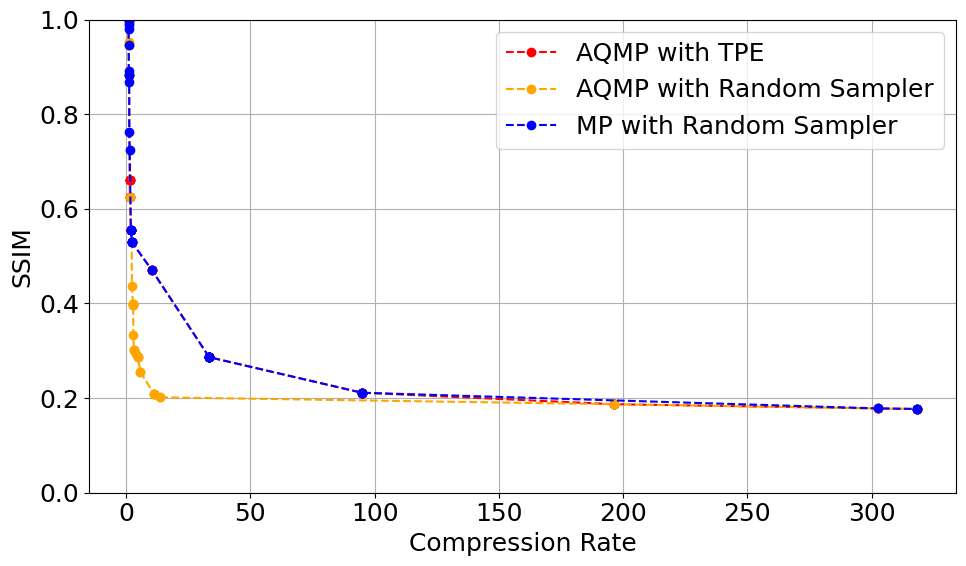

In [131]:
plot_given_studies([
'multiobjTPE_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55',
'multiobjRandomSampler_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55'])

[I 2025-04-10 13:02:11,422] A new study created in RDB with name: multiobjTPE_trials:20_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-10_13-02-11


image name: Mandrill_(a.k.a._Baboon)


[I 2025-04-10 13:02:12,982] Trial 0 finished with values: [11.13329579843761, 0.20959673473824825] and parameters: {'min_sparcity': 0.12390402072588116, 'exponent_min_n': 5, 'exponent_max_n': 5, 'max_error': 0.027767560053080172, 'exponent_a_cols': 3}.
[I 2025-04-10 13:02:15,329] Trial 1 finished with values: [7.134568332750787, 0.1834756156485394] and parameters: {'min_sparcity': 0.8605461160391117, 'exponent_min_n': 5, 'exponent_max_n': 6, 'max_error': 0.0014930795478222975, 'exponent_a_cols': 6}.
[I 2025-04-10 13:02:18,391] Trial 2 finished with values: [4.410636740668456, 0.23992103017526856] and parameters: {'min_sparcity': 0.4010005182466958, 'exponent_min_n': 6, 'exponent_max_n': 6, 'max_error': 0.0021943688007952746, 'exponent_a_cols': 7}.
[I 2025-04-10 13:02:25,010] Trial 3 finished with values: [2.803113329996146, 0.3975935526569498] and parameters: {'min_sparcity': 0.2288187059255276, 'exponent_min_n': 4, 'exponent_max_n': 5, 'max_error': 0.002883873457990516, 'exponent_a_co

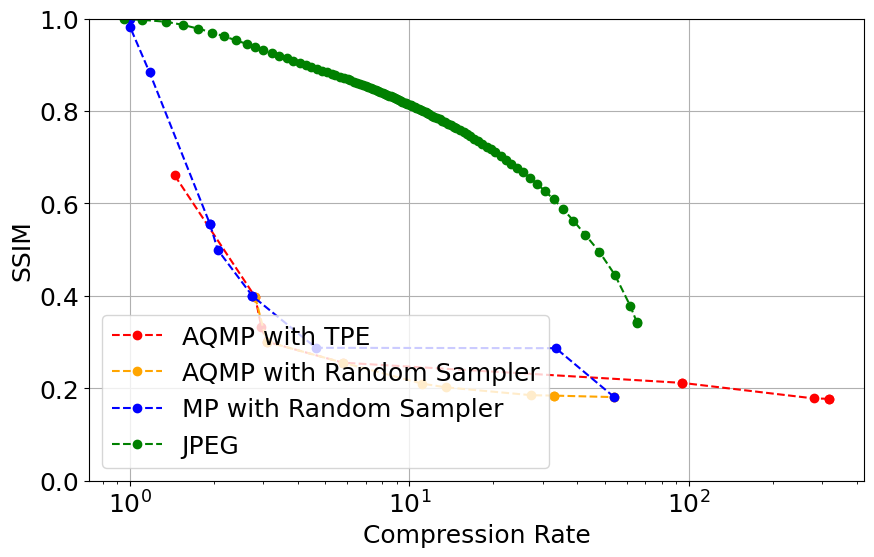

In [88]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 20
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[2:3]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    

    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

[I 2025-04-10 16:26:13,882] A new study created in RDB with name: multiobjTPE_trials:10_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-10_16-26-13


image name: Mandrill_(a.k.a._Baboon)


[I 2025-04-10 16:26:15,438] Trial 0 finished with values: [13.548851251525598, 0.20161001141588075] and parameters: {'min_sparcity': 0.12390402072588116, 'exponent_max_n': 5, 'max_error': 0.006314599125448371, 'exponent_a_cols': 2}.
[I 2025-04-10 16:26:17,151] Trial 1 finished with values: [36.786930992384164, 0.17391822389585399] and parameters: {'min_sparcity': 0.3338676652530284, 'exponent_max_n': 7, 'max_error': 9.920676282679887, 'exponent_a_cols': 5}.
[I 2025-04-10 16:26:20,311] Trial 2 finished with values: [4.410636740668456, 0.23992103017526856] and parameters: {'min_sparcity': 0.0387236861801168, 'exponent_max_n': 6, 'max_error': 0.23426106351002185, 'exponent_a_cols': 7}.
[I 2025-04-10 16:26:56,274] Trial 3 finished with values: [1.4392237673485542, 0.658873248370678] and parameters: {'min_sparcity': 0.26187691460128054, 'exponent_max_n': 2, 'max_error': 158.4498547440748, 'exponent_a_cols': 2}.
[I 2025-04-10 16:27:50,365] Trial 4 finished with values: [0.996883812524616, 0.

4 4


[I 2025-04-10 16:31:44,648] Trial 0 finished with values: [0.9967346360135151, 0.9983331495060849] and parameters: {'exponent_min_n': 2, 'exponent_a_cols': 5, 'min_sparcity': 0.1420570545441284, 'max_error': 0.027767560053080172}.


...

[I 2025-04-10 16:33:55,044] Trial 7 finished with values: [2.0595164088360027, 0.4991646622214771] and parameters: {'exponent_min_n': 3, 'exponent_a_cols': 3, 'min_sparcity': 0.015078253573812381, 'max_error': 1.8164150502902998}.


16 16


[I 2025-04-10 16:34:07,150] Trial 8 finished with values: [1.9301538883889762, 0.5554653107102364] and parameters: {'exponent_min_n': 4, 'exponent_a_cols': 6, 'min_sparcity': 0.9784220927411861, 'max_error': 283.12390975139635}.


128 128


[I 2025-04-10 16:34:08,886] Trial 9 finished with values: [36.786930992384164, 0.17391822389585399] and parameters: {'exponent_min_n': 7, 'exponent_a_cols': 5, 'min_sparcity': 0.11297876035621526, 'max_error': 0.012175521489632335}.


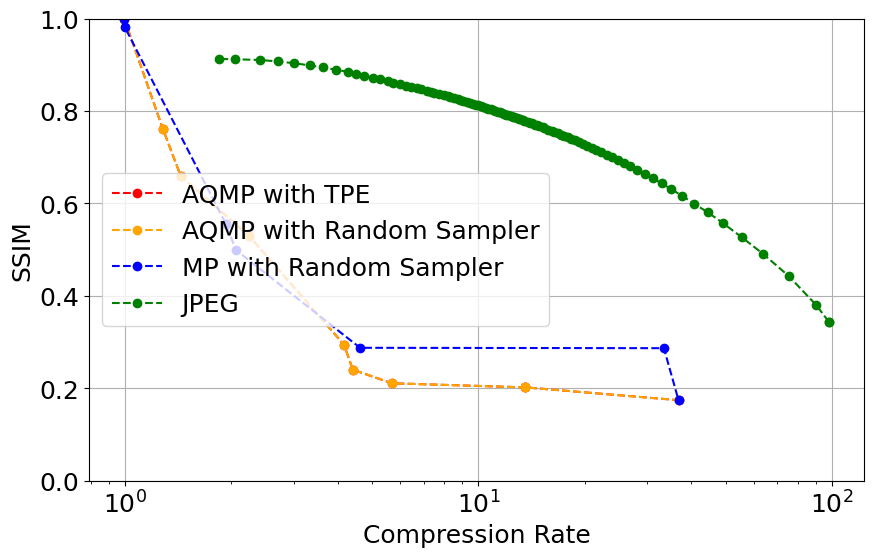

In [118]:

# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 43
n_trials = 10
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[2:3]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    

    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

#### MP vs AQMP

In [105]:
# comparar un max_n fijo con 
# ese max_n fijo y min_n variable,
# para comparar el caso de mp normal con el agregado de AQ a MP

min_sparcity = .01
max_error = 100

a_cols = 2**2
min_n = 2**4
max_n = 2**4
assert max_n >= min_n

image_name = 'Mandrill_(a.k.a._Baboon)'
folder_path = 'test_images/'
input_image_path = folder_path+image_name+".png"
fif_image_path ="../compressions/"+image_name+".fif"
output_image_path = "../compressions/"+image_name+"_reconstructed.png"

# ENCODE
start_time = time.time()    
newCodec = ImageCompressor(min_sparcity = min_sparcity,
                           min_n = min_n,
                           max_n = max_n,
                           max_error = max_error,
                           a_cols = a_cols,
                           apply_deflate=True
                          )

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    newCodec.encode(input_file=input_image_path,
                    output_file=fif_image_path)

# DECODE
newCodec.decode(input_file=fif_image_path,
                output_file=output_image_path)
end_time = time.time()
execution_time = end_time - start_time

# CALCULATE SSIM
ssim_index = calculate_ssim(input_image_path, output_image_path)

# COMPRESSION RATE
image_size = os.path.getsize(input_image_path)
compressed_image_size = os.path.getsize(output_image_path)
compression_rate = image_size / compressed_image_size


print(compression_rate, ssim_index)

5.775575027382256 0.2551073555143876


In [107]:
min_n = 2**3
max_n = 2**4
assert max_n >= min_n

# ENCODE
start_time = time.time()    
newCodec = ImageCompressor(min_sparcity = min_sparcity,
                           min_n = min_n,
                           max_n = max_n,
                           max_error = max_error,
                           a_cols = a_cols,
                           apply_deflate=True
                          )

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    newCodec.encode(input_file=input_image_path,
                    output_file=fif_image_path)

# DECODE
newCodec.decode(input_file=fif_image_path,
                output_file=output_image_path)
end_time = time.time()
execution_time = end_time - start_time

# CALCULATE SSIM
ssim_index = calculate_ssim(input_image_path, output_image_path)

# COMPRESSION RATE
image_size = os.path.getsize(input_image_path)
compressed_image_size = os.path.getsize(output_image_path)
compression_rate = image_size / compressed_image_size


print(compression_rate, ssim_index)

2.741313878732216 0.3992301054044307


In [108]:
min_n = 2**2
max_n = 2**4
assert max_n >= min_n

# ENCODE
start_time = time.time()    
newCodec = ImageCompressor(min_sparcity = min_sparcity,
                           min_n = min_n,
                           max_n = max_n,
                           max_error = max_error,
                           a_cols = a_cols,
                           apply_deflate=True
                          )

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    newCodec.encode(input_file=input_image_path,
                    output_file=fif_image_path)

# DECODE
newCodec.decode(input_file=fif_image_path,
                output_file=output_image_path)
end_time = time.time()
execution_time = end_time - start_time

# CALCULATE SSIM
ssim_index = calculate_ssim(input_image_path, output_image_path)

# COMPRESSION RATE
image_size = os.path.getsize(input_image_path)
compressed_image_size = os.path.getsize(output_image_path)
compression_rate = image_size / compressed_image_size

print(compression_rate, ssim_index)

1.4408361226859758 0.6603250685385776


In [106]:
min_n = 2**1
max_n = 2**4
assert max_n >= min_n

# ENCODE
start_time = time.time()    
newCodec = ImageCompressor(min_sparcity = min_sparcity,
                           min_n = min_n,
                           max_n = max_n,
                           max_error = max_error,
                           a_cols = a_cols,
                           apply_deflate=True
                          )

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    newCodec.encode(input_file=input_image_path,
                    output_file=fif_image_path)

# DECODE
newCodec.decode(input_file=fif_image_path,
                output_file=output_image_path)
end_time = time.time()
execution_time = end_time - start_time

# CALCULATE SSIM
ssim_index = calculate_ssim(input_image_path, output_image_path)

# COMPRESSION RATE
image_size = os.path.getsize(input_image_path)
compressed_image_size = os.path.getsize(output_image_path)
compression_rate = image_size / compressed_image_size


print(compression_rate, ssim_index)

1.0092717386623369 0.877283433384902


prueba de MP sin AQ. viendo hiprpaeametros

[I 2025-04-10 17:03:40,612] A new study created in RDB with name: multiobjTPE_trials:500_seed:2_image:Mandrill_(a.k.a._Baboon)_time:2025-04-10_17-03-40


image name: Mandrill_(a.k.a._Baboon)


[I 2025-04-10 17:03:42,503] Trial 0 finished with values: [7.657433290978399, 0.22668466599214857] and parameters: {'min_sparcity': 0.4416349531205837, 'exponent_min_n': 2, 'exponent_max_n': 5, 'max_error': 0.40919880401596753, 'exponent_a_cols': 4}.
[I 2025-04-10 17:03:43,724] Trial 1 finished with values: [27.36074717862239, 0.18467039327077142] and parameters: {'min_sparcity': 0.3370314727938354, 'exponent_min_n': 3, 'exponent_max_n': 6, 'max_error': 0.06279543048780202, 'exponent_a_cols': 3}.
[I 2025-04-10 17:03:45,186] Trial 2 finished with values: [13.548851251525598, 0.20161001141588075] and parameters: {'min_sparcity': 0.624922494441602, 'exponent_min_n': 5, 'exponent_max_n': 5, 'max_error': 1.2063372198931612, 'exponent_a_cols': 2}.
[I 2025-04-10 17:03:48,718] Trial 3 finished with values: [10.893896875269002, 0.14869331834518829] and parameters: {'min_sparcity': 0.7874817963385067, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 0.9234662423936655, 'exponent_a_cols': 7

16 16


[I 2025-04-10 20:20:20,895] Trial 0 finished with values: [94.85414480587617, 0.21134736656993938] and parameters: {'exponent_min_n': 4, 'exponent_a_cols': 1, 'min_sparcity': 0.5541658530999221, 'max_error': 0.40919880401596753}.


...

[I 2025-04-10 22:24:14,503] Trial 497 finished with values: [2.949064860859312, 0.3330430007414323] and parameters: {'exponent_min_n': 4, 'exponent_a_cols': 4, 'min_sparcity': 0.12489291651999805, 'max_error': 0.0042177239830995}.


4 4


[I 2025-04-10 22:25:13,331] Trial 498 finished with values: [0.9967990119785004, 0.9990878754879997] and parameters: {'exponent_min_n': 2, 'exponent_a_cols': 7, 'min_sparcity': 0.8965917721037544, 'max_error': 0.10948895843613943}.


128 128


[I 2025-04-10 22:25:19,616] Trial 499 finished with values: [5.690907455706449, 0.210500198853245] and parameters: {'exponent_min_n': 7, 'exponent_a_cols': 8, 'min_sparcity': 0.7619874821272482, 'max_error': 0.026099579744287872}.


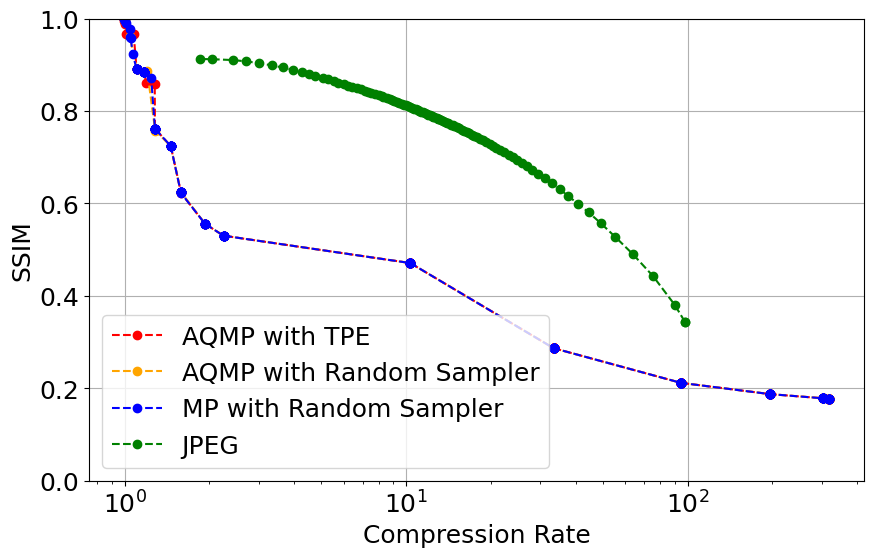

[I 2025-04-10 22:25:30,203] A new study created in RDB with name: multiobjTPE_trials:500_seed:2_image:San_Diego_time:2025-04-10_22-25-30


image name: San_Diego


[I 2025-04-10 22:25:32,390] Trial 0 finished with values: [9.598059019181994, 0.19071490850913983] and parameters: {'min_sparcity': 0.4416349531205837, 'exponent_min_n': 2, 'exponent_max_n': 5, 'max_error': 0.40919880401596753, 'exponent_a_cols': 4}.
[I 2025-04-10 22:25:33,452] Trial 1 finished with values: [38.270756373766126, 0.14720615685959124] and parameters: {'min_sparcity': 0.3370314727938354, 'exponent_min_n': 3, 'exponent_max_n': 6, 'max_error': 0.06279543048780202, 'exponent_a_cols': 3}.
[I 2025-04-10 22:25:34,738] Trial 2 finished with values: [14.477675196444526, 0.1580441966835569] and parameters: {'min_sparcity': 0.624922494441602, 'exponent_min_n': 5, 'exponent_max_n': 5, 'max_error': 1.2063372198931612, 'exponent_a_cols': 2}.
[I 2025-04-10 22:25:38,096] Trial 3 finished with values: [14.906944378921546, 0.15615475962216116] and parameters: {'min_sparcity': 0.7874817963385067, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 0.9234662423936655, 'exponent_a_cols': 7

16 16


[I 2025-04-11 01:14:26,081] Trial 0 finished with values: [94.66222288795686, 0.1630960544683403] and parameters: {'exponent_min_n': 4, 'exponent_a_cols': 1, 'min_sparcity': 0.5541658530999221, 'max_error': 0.40919880401596753}.


...

[I 2025-04-11 09:47:34,115] Trial 497 finished with values: [3.1562584279763866, 0.2887384643706366] and parameters: {'exponent_min_n': 4, 'exponent_a_cols': 4, 'min_sparcity': 0.12489291651999805, 'max_error': 0.0042177239830995}.


4 4


[I 2025-04-11 09:48:55,850] Trial 498 finished with values: [0.9962763684976361, 0.9992463368282088] and parameters: {'exponent_min_n': 2, 'exponent_a_cols': 7, 'min_sparcity': 0.8965917721037544, 'max_error': 0.10948895843613943}.


128 128


[I 2025-04-11 09:49:04,174] Trial 499 finished with values: [7.485785695671744, 0.166331052919774] and parameters: {'exponent_min_n': 7, 'exponent_a_cols': 8, 'min_sparcity': 0.7619874821272482, 'max_error': 0.026099579744287872}.


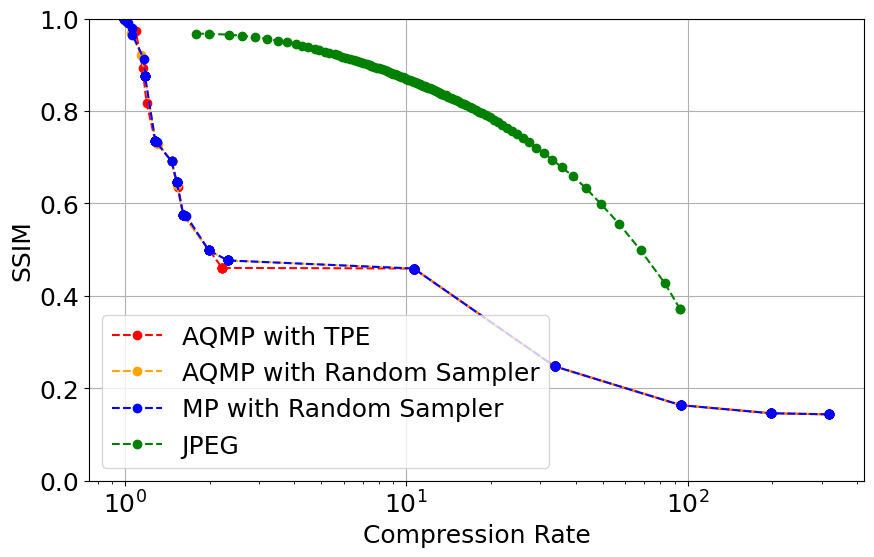

In [123]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 2
n_trials = 500
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Plot Parameters
plt.rcParams['font.size'] = 18

# Train and Save Studies
for image_name in test_images[2:4]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    

    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    
    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

#### JPEG

- empieza en ssim similar a 0.9 porque primero hay un subsampleo

- parametro quality:

    + define la cuantizacion de los coeficientes de DCT de la imagen en cuestion.

    + a mayor valor de quality se tiene menos contribuciones de los pesos, dando mas compresion y mas perdida de calidad.

jpeg_demo

#### AQMP

- agrande la grila de MP. realice busqueda de hiperparametros para comparar en MP sin quadtrees y dan comparables a AQMP. se realiza en bloques 8x8.

- tener en cuenta que varias veces los mejores de AQMP son sin particion.

- buscar imagenes mas heterogeneas?

- al agregar mas profundidad lo que suele pasar es en hay menos compresion y mas ssim como resultado. hay un tradeoff en los casos que vi.

- corridas de una imagen coon 500 trials diferentes en imagen de Mandrill.

[I 2025-04-15 10:25:18,485] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:San_Diego_(Miramar_NAS)_time:2025-04-15_10-25-18


image name: San_Diego_(Miramar_NAS)


[I 2025-04-15 10:25:23,169] Trial 0 finished with values: [54.97944167400019, 0.24237758735242756] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 10:28:06,966] Trial 1 finished with values: [1.0998238109931573, 0.925970932354815] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 10:28:10,602] Trial 2 finished with values: [368.2218402095612, 0.23379898727904083] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 10:28:25,826] Trial 3 finished with values: [2.8595209337215364, 0.39801709325487683] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:San_Diego_(Miramar_NAS)_time:2025-04-15_10-25-18 ---
Compression: 0.9933, SSIM: 0.9775, Hyperparams: {'min_sparcity': 0.38744267471988864, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 44.84139639276013, 'exponent_a_cols': 6}
Compression: 0.9938, SSIM: 0.9756, Hyperparams: {'min_sparcity': 0.6110157078635666, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 48.78160132354689, 'exponent_a_cols': 6}
Compression: 1.0998, SSIM: 0.9260, Hyperparams: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}
Compression: 1.1653, SSIM: 0.9035, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.1653, SSIM: 0.9035, Hyperparams: {'min_sparcity': 0.6439655906738888, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 0.69924700

[I 2025-04-15 11:47:34,504] Trial 0 finished with values: [54.97944167400019, 0.24237758735242756] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 11:50:11,978] Trial 1 finished with values: [1.0998238109931573, 0.925970932354815] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 11:50:15,092] Trial 2 finished with values: [368.2218402095612, 0.23379898727904083] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 11:50:29,603] Trial 3 finished with values: [2.8595209337215364, 0.39801709325487683] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I

...

8 8


[I 2025-04-15 15:56:01,845] Trial 98 finished with values: [2.7904904173392375, 0.48952333195962344] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-15 15:56:36,373] Trial 99 finished with values: [2.7904904173392375, 0.48952333195962344] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:San_Diego_(Miramar_NAS)_time:2025-04-15_10-25-18 ---
Compression: 0.9930, SSIM: 0.9988, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.9931, SSIM: 0.9988, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.9931, SSIM: 0.9986, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.5596488034834677, 'max_error': 1.506272232520005}
Compression: 0.9932, SSIM: 0.9985, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.66103676337734, 'max_error': 2.5695177376559535}
Compression: 0.9935, SSIM: 0.9965, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.6534642914699875, 'max_error': 16.285506249643184}
Compression: 1.0280, SSIM: 0.9758, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.812012260732389, 'max_error': 159.38003265859828}
Compression: 1.0653, S

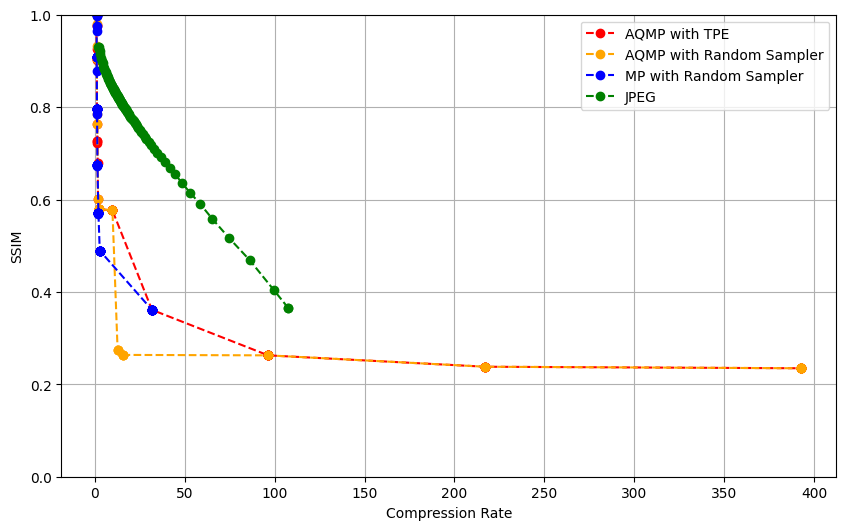

[I 2025-04-15 15:57:18,464] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-04-15_15-57-18


image name: Peppers


[I 2025-04-15 15:57:19,936] Trial 0 finished with values: [33.74587114041387, 0.38189749157252595] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 15:57:55,835] Trial 1 finished with values: [1.1717002985047564, 0.8658130324706903] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 15:57:56,827] Trial 2 finished with values: [246.16809523809525, 0.38983996492857154] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 15:58:00,546] Trial 3 finished with values: [2.5247393226050647, 0.5191024669810619] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-04-15_15-57-18 ---
Compression: 0.9818, SSIM: 0.9969, Hyperparams: {'min_sparcity': 0.5800480299196096, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.009311019656584875, 'exponent_a_cols': 7}
Compression: 1.1380, SSIM: 0.8882, Hyperparams: {'min_sparcity': 0.37934878053117427, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 0.3860053599760677, 'exponent_a_cols': 6}
Compression: 1.2007, SSIM: 0.8823, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.4709, SSIM: 0.7882, Hyperparams: {'min_sparcity': 0.6744914783800473, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.07807430851224681, 'exponent_a_cols': 2}
Compression: 9.8800, SSIM: 0.7111, Hyperparams: {'min_sparcity': 0.547176419850242, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.030201297182473236, '

[I 2025-04-15 16:12:53,700] Trial 0 finished with values: [33.74587114041387, 0.38189749157252595] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 16:13:28,254] Trial 1 finished with values: [1.1717002985047564, 0.8658130324706903] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 16:13:29,172] Trial 2 finished with values: [246.16809523809525, 0.38983996492857154] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 16:13:32,752] Trial 3 finished with values: [2.5247393226050647, 0.5191024669810619] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[

...

8 8


[I 2025-04-15 17:02:33,780] Trial 98 finished with values: [2.752810305073193, 0.6342140925905084] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-15 17:02:44,054] Trial 99 finished with values: [2.752810305073193, 0.6342140925905084] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Peppers_time:2025-04-15_15-57-18 ---
Compression: 0.9819, SSIM: 0.9970, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.9819, SSIM: 0.9970, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.9819, SSIM: 0.9970, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.9819, SSIM: 0.9970, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 0.9823, SSIM: 0.9925, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.6534642914699875, 'max_error': 16.285506249643184}
Compression: 0.9842, SSIM: 0.9795, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.6348272397372903, 'max_error': 58.731057569583825}
Compression: 0.9862, SSIM: 0.9

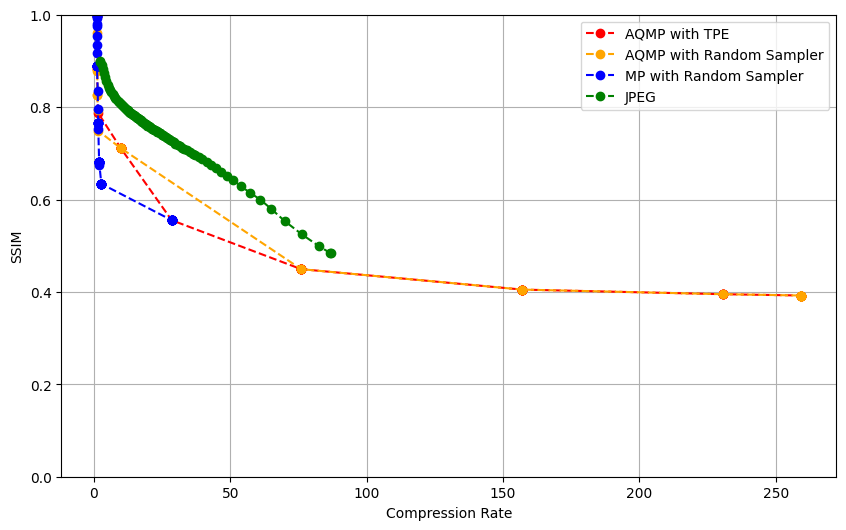

[I 2025-04-15 17:02:57,387] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-04-15_17-02-57


image name: Foster_City,_Ca


[I 2025-04-15 17:02:59,190] Trial 0 finished with values: [80.12887081639036, 0.49404422597711556] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 17:03:40,379] Trial 1 finished with values: [1.2749569493246269, 0.8131573032390293] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 17:03:41,423] Trial 2 finished with values: [251.02596766291035, 0.4922801756964185] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 17:03:46,049] Trial 3 finished with values: [3.3934785632438946, 0.5584520630855448] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-04-15_17-02-57 ---
Compression: 1.1475, SSIM: 0.8827, Hyperparams: {'min_sparcity': 0.3535536152664565, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 44.84139639276013, 'exponent_a_cols': 6}
Compression: 1.2679, SSIM: 0.8780, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.2750, SSIM: 0.8132, Hyperparams: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}
Compression: 1.3121, SSIM: 0.7798, Hyperparams: {'min_sparcity': 0.819597563545742, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 269.9552078161186, 'exponent_a_cols': 7}
Compression: 1.5705, SSIM: 0.7640, Hyperparams: {'min_sparcity': 0.782810772433659, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 47.214788460010155, '

[I 2025-04-15 17:17:47,786] Trial 0 finished with values: [80.12887081639036, 0.49404422597711556] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-15 17:18:25,216] Trial 1 finished with values: [1.2749569493246269, 0.8131573032390293] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-15 17:18:26,156] Trial 2 finished with values: [251.02596766291035, 0.4922801756964185] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-15 17:18:29,795] Trial 3 finished with values: [3.3934785632438946, 0.5584520630855448] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I

...

8 8


[I 2025-04-15 23:09:19,170] Trial 98 finished with values: [3.6557092808368234, 0.5972779177219915] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-15 23:09:28,009] Trial 99 finished with values: [3.6557092808368234, 0.5972779177219915] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Foster_City,_Ca_time:2025-04-15_17-02-57 ---
Compression: 0.9705, SSIM: 0.9961, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.9705, SSIM: 0.9961, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.9705, SSIM: 0.9961, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.9705, SSIM: 0.9961, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.2202157195714934, 'max_error': 0.012329623163659839}
Compression: 0.9707, SSIM: 0.9913, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.7820767903990476, 'max_error': 7.115245297181689}
Compression: 0.9709, SSIM: 0.9905, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.26536221143800404, 'max_error': 9.118098432074813}
Compression: 0.9752, 

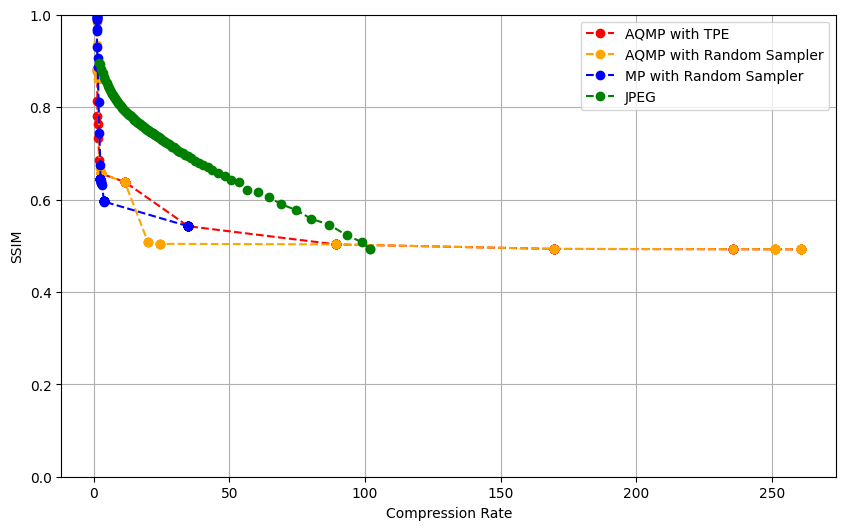

[I 2025-04-15 23:09:40,273] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:Airplane_(U-2)_time:2025-04-15_23-09-40


image name: Airplane_(U-2)


[W 2025-04-15 23:09:44,090] Trial 0 failed with parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5} because of the following error: ValueError('Input images must have the same dimensions.').
Traceback (most recent call last):
  File "/Users/fcerino/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_1403/2889485630.py", line 44, in objective
    ssim_index = calculate_ssim(input_image_path, output_image_path)
  File "/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_1403/3272849031.py", line 40, in calculate_ssim
    ssim_index = ssim(image1, image2, data_range=image1.max() - image1.min())
  File "/Users/fcerino/Library/Python/3.9/lib/python/site-packages/skimage/metrics/_structural_similarity.py", line 118, in structural_similarity
    check

ValueError: Input images must have the same dimensions.

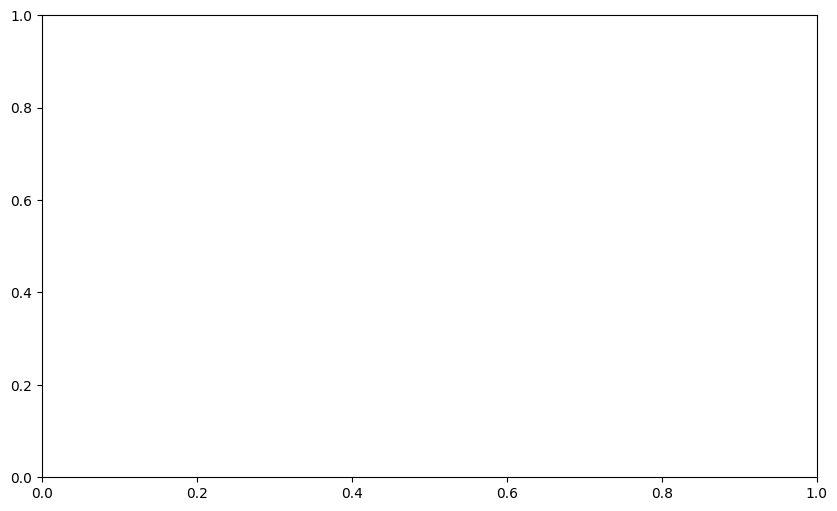

In [15]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 42
n_trials = 100
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Train and Save Studies
for image_name in test_images[8:]:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    
    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)

    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.legend()
    plt.legend(loc='best')
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

# cuadro

multiobjTPE_trials:100_seed:43_image:Splash_time:2025-04-08_11-49-59
multiobjRandomSampler_trials:100_seed:43_image:Splash_time:2025-04-08_11-49-59
MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Splash_time:2025-04-08_11-49-59
multiobjTPE_trials:100_seed:43_image:Splash_time:2025-04-08_17-08-40
multiobjRandomSampler_trials:100_seed:43_image:Splash_time:2025-04-08_17-08-40
multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52
multiobjRandomSampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52
MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52

--- Pareto front for study: multiobjTPE_trials:100_seed:43_image:Splash_time:2025-04-08_11-49-59 ---
Compression: 0.9098, SSIM: 0.9943, Hyperparams: {'min_sparcity': 0.6325042683035962, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.02386435124987524, 'exponent_a_cols': 6}
Compression: 0.9508, SSIM: 0.9442, Hyperparams: {'min_sparcity': 0.6279169218244538, 'expon

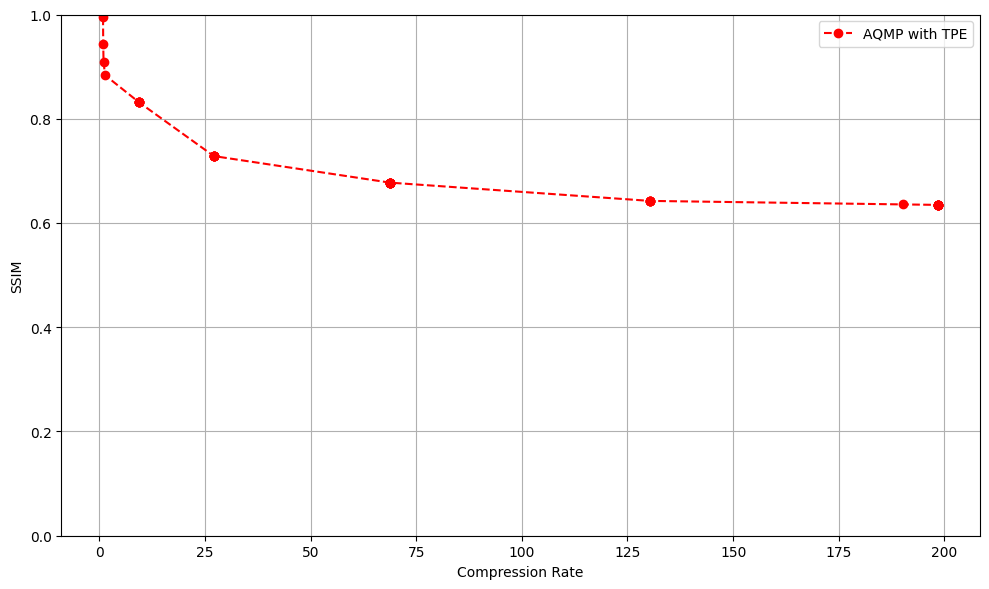

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_exponent_a_cols,params_exponent_max_n,params_exponent_min_n,params_max_error,params_min_sparcity,user_attrs_compression_rate,user_attrs_execution_time,user_attrs_ssim,state
0,0,8.903858,0.648958,2025-04-08 11:49:59.218638,2025-04-08 11:50:00.623216,0 days 00:00:01.404578,3,5,5,0.027768,0.123904,8.903858,1.271737,0.648958,COMPLETE
1,1,5.611004,0.589424,2025-04-08 11:50:00.635768,2025-04-08 11:50:02.495753,0 days 00:00:01.859985,6,6,5,0.001493,0.860546,5.611004,1.737015,0.589424,COMPLETE
2,2,3.184502,0.669613,2025-04-08 11:50:02.508506,2025-04-08 11:50:05.313866,0 days 00:00:02.805360,7,6,6,0.002194,0.401001,3.184502,2.683933,0.669613,COMPLETE
3,3,2.204034,0.762938,2025-04-08 11:50:05.325770,2025-04-08 11:50:10.718412,0 days 00:00:05.392642,7,5,4,0.002884,0.228819,2.204034,5.276777,0.762938,COMPLETE
4,4,3.833291,0.662581,2025-04-08 11:50:10.741490,2025-04-08 11:50:17.279377,0 days 00:00:06.537887,8,7,7,0.205240,0.850450,3.833291,6.422945,0.662581,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,1.356752,0.883023,2025-04-08 12:02:43.561124,2025-04-08 12:03:19.082240,0 days 00:00:35.521116,2,2,2,14.983644,0.562846,1.356752,35.374459,0.883023,COMPLETE
96,96,179.094288,0.630603,2025-04-08 12:03:19.098484,2025-04-08 12:03:19.983786,0 days 00:00:00.885302,1,6,5,2.686994,0.429352,179.094288,0.725499,0.630603,COMPLETE
97,97,11.195296,0.650477,2025-04-08 12:03:19.994233,2025-04-08 12:03:21.314984,0 days 00:00:01.320751,2,5,4,1.093828,0.676762,11.195296,1.174983,0.650477,COMPLETE
98,98,9.450366,0.831379,2025-04-08 12:03:21.330473,2025-04-08 12:03:53.530134,0 days 00:00:32.199661,1,2,2,0.014362,0.644390,9.450366,32.048656,0.831379,COMPLETE


In [6]:
storage_path = "sqlite:///aqmp_studies.db"
study_summaries = optuna.study.get_all_study_summaries(storage=storage_path)

fully_completed_splash_studies = []

for summary in study_summaries:
    if "Splash" in summary.study_name:
        study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
        trial_states = [trial.state for trial in study.trials]

        if trial_states and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
            fully_completed_splash_studies.append(summary.study_name)

# Print the names
for name in fully_completed_splash_studies:
    print(name)

plot_given_studies(
fully_completed_splash_studies[:1]
)

study = optuna.load_study(study_name=fully_completed_splash_studies[0], storage=storage_path)   
df = study.trials_dataframe()
df

In [3]:
storage_path = "sqlite:///aqmp_studies.db"

study = optuna.load_study(study_name='multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52',
                          storage=storage_path)

pareto_trials = [t.number for t in study.best_trials]

df = study.trials_dataframe()

df = df.loc[pareto_trials].reset_index(drop=True)

# Drop unwanted columns
drop_cols = [col for col in df.columns if col.startswith("datetime") or col.startswith("values_") or  col.startswith("number") or  col.startswith("state") or  col.startswith("duration")]
df = df.drop(columns=drop_cols)

column_order = [
    'user_attrs_ssim',
    'user_attrs_compression_rate',
    'params_max_error',
    'params_min_sparcity',
    'params_exponent_min_n',
    'params_exponent_max_n',
    'params_exponent_a_cols',
    "user_attrs_execution_time"
]

# Ensure only columns that exist in the DataFrame are selected (avoids KeyError)
ordered_columns = [col for col in column_order if col in df.columns]
df = df[ordered_columns]

# Define new column names
rename_map = {
    "user_attrs_compression_rate": "Compression Rate",
    "user_attrs_ssim": "SSIM",
    "user_attrs_execution_time": "Execution Time",
    
    "params_min_sparcity": "Min Sparsity",
    "params_max_error": "Max Error",
    'params_exponent_min_n': 'exponent_min_n',
    'params_exponent_max_n': 'exponent_max_n',
    'params_exponent_a_cols': 'exponent_a_cols',

    "user_attrs_execution_time": "Duration (s)",
}

df = df.rename(columns=rename_map)
df = df.round(4)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Sort in descending order (highest SSIM first)
df = df.sort_values(by="SSIM", ascending=False).reset_index(drop=True)
df = df.iloc[::4].reset_index(drop=True)
#df = df.iloc[:-1]

df

,SSIM,Compression Rate,Max Error,Min Sparsity,exponent_min_n,exponent_max_n,exponent_a_cols,Duration (s)
0,0.9962,0.9172,0.0015,0.2084,2,2,8,65.5338
1,0.9032,1.2377,0.0082,0.3298,3,3,5,16.9183
2,0.8314,9.4504,0.0016,0.6256,2,2,1,28.6854
3,0.8314,9.4504,47.2277,0.4394,2,2,1,30.7702
4,0.7284,27.1236,261.8908,0.9236,2,3,1,7.4893
5,0.7284,27.1236,424.6535,0.8930,2,3,1,7.8326
6,0.6774,68.8056,0.0022,0.7279,3,4,1,2.4761
7,0.6774,68.8056,0.0032,0.6841,3,4,1,2.8326
8,0.6424,130.3471,0.0055,0.2468,3,5,1,1.0816
9,0.6356,190.1261,30.2875,0.2801,3,7,2,0.6998


In [4]:
# Select columns starting with 'exponent_'
exp_cols = df.filter(regex='^exponent_')

# Transform values: 2 ** value
transformed = exp_cols.applymap(lambda x: 2 ** x)

# Rename columns by removing 'exponent_'
transformed.columns = [col.replace('exponent_', '') for col in transformed.columns]

# Merge back into original df, or use `transformed` alone if you prefer
df = df.drop(columns=exp_cols.columns).join(transformed)

column_to_move = 'Duration (s)'
new_order = [col for col in df.columns if col != column_to_move] + [column_to_move]
df = df[new_order]

print(df)

      SSIM  Compression Rate  Max Error  Min Sparsity  min_n  max_n  a_cols  \
0   0.9962            0.9172     0.0015        0.2084      4      4     256   
1   0.9032            1.2377     0.0082        0.3298      8      8      32   
2   0.8314            9.4504     0.0016        0.6256      4      4       2   
3   0.8314            9.4504    47.2277        0.4394      4      4       2   
4   0.7284           27.1236   261.8908        0.9236      4      8       2   
5   0.7284           27.1236   424.6535        0.8930      4      8       2   
6   0.6774           68.8056     0.0022        0.7279      8     16       2   
7   0.6774           68.8056     0.0032        0.6841      8     16       2   
8   0.6424          130.3471     0.0055        0.2468      8     32       2   
9   0.6356          190.1261    30.2875        0.2801      8    128       4   
10  0.6347          198.5337     0.0373        0.5549     64    128       2   
11  0.6347          198.5337    48.6796        0.681

/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_34365/2833539921.py:5: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [5]:
# Export to LaTeX without index
latex_code = df.to_latex(
    index=False,
    escape=True,
    float_format="%.4f",
    column_format="r" * len(df.columns)
)

print(latex_code)

\begin{tabular}{rrrrrrrr}
\toprule
SSIM & Compression Rate & Max Error & Min Sparsity & min\_n & max\_n & a\_cols & Duration (s) \\
\midrule
0.9962 & 0.9172 & 0.0015 & 0.2084 & 4 & 4 & 256 & 65.5338 \\
0.9032 & 1.2377 & 0.0082 & 0.3298 & 8 & 8 & 32 & 16.9183 \\
0.8314 & 9.4504 & 0.0016 & 0.6256 & 4 & 4 & 2 & 28.6854 \\
0.8314 & 9.4504 & 47.2277 & 0.4394 & 4 & 4 & 2 & 30.7702 \\
0.7284 & 27.1236 & 261.8908 & 0.9236 & 4 & 8 & 2 & 7.4893 \\
0.7284 & 27.1236 & 424.6535 & 0.8930 & 4 & 8 & 2 & 7.8326 \\
0.6774 & 68.8056 & 0.0022 & 0.7279 & 8 & 16 & 2 & 2.4761 \\
0.6774 & 68.8056 & 0.0032 & 0.6841 & 8 & 16 & 2 & 2.8326 \\
0.6424 & 130.3471 & 0.0055 & 0.2468 & 8 & 32 & 2 & 1.0816 \\
0.6356 & 190.1261 & 30.2875 & 0.2801 & 8 & 128 & 4 & 0.6998 \\
0.6347 & 198.5337 & 0.0373 & 0.5549 & 64 & 128 & 2 & 0.7511 \\
0.6347 & 198.5337 & 48.6796 & 0.6815 & 8 & 128 & 2 & 0.7679 \\
\bottomrule
\end{tabular}



In [7]:
import optuna
from datetime import timedelta

storage_path = "sqlite:///aqmp_studies.db"
study_name = "multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52"

# Load study
study = optuna.load_study(study_name=study_name, storage=storage_path)

# Get start and end times from all trials
start_times = [trial.datetime_start for trial in study.trials if trial.datetime_start is not None]
end_times = [trial.datetime_complete for trial in study.trials if trial.datetime_complete is not None]

# Compute total duration
if start_times and end_times:
    total_time = max(end_times) - min(start_times)
    print(f"Total optimization time: {total_time} (hh:mm:ss)")
else:
    print("Some trials are missing timestamps.")

Total optimization time: 0:16:57.788916 (hh:mm:ss)


# Text Images

In [22]:
from pathlib import Path
from PIL import Image

def simple_convert_to_png(source_dir: str, target_dir: str):
    """
    Converts all .tif, .tiff, .jpg, .jpeg, .bmp images in source_dir to .png in target_dir.
    """
    source_folder = Path(source_dir)
    target_folder = Path(target_dir)
    target_folder.mkdir(parents=True, exist_ok=True)

    for img_file in source_folder.glob("*"):
        if img_file.suffix.lower() in (".tif", ".tiff", ".jpg", ".jpeg", ".bmp"):
            img = Image.open(img_file)
            png_file = target_folder / (img_file.stem + ".png")
            img.save(png_file, format="PNG")
            print(f"Saved {png_file}")

#simple_convert_to_png(
#     source_dir="/Users/fcerino/Downloads/H_DIBCO2010_test_images/",
#     target_dir="/Users/fcerino/Downloads/H_DIBCO2010_test_images_png/"
# )

/Users/fcerino/Library/Python/3.9/lib/python/site-packages/PIL/TiffImagePlugin.py:949: UserWarning:

Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 



Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H01.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H03.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H06.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H07.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H10.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H05.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H02.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H08.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H09.png
Saved /Users/fcerino/Downloads/H_DIBCO2010_test_images_png/H04.png


In [24]:
# Get all image names in the folder
folder_path = '/Users/fcerino/Downloads/H_DIBCO2010_test_images_png/' # "../images/Color/256x256/"
test_images = get_images_from_folder(folder_path)
test_images

['H07', 'H06', 'H04', 'H10', 'H05', 'H01', 'H02', 'H03', 'H08', 'H09']

[I 2025-04-21 20:26:32,326] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H07_time:2025-04-21_20-26-32


image name: H07


[I 2025-04-21 20:26:35,638] Trial 0 finished with values: [46.92105047189167, 0.3469565809990443] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-21 20:28:16,162] Trial 1 finished with values: [0.6107775667308354, 0.928778832015046] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-21 20:28:18,451] Trial 2 finished with values: [143.04053039779834, 0.3483630474683597] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-21 20:28:27,248] Trial 3 finished with values: [1.9415266439370271, 0.5521096784512874] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H07_time:2025-04-21_20-26-32 ---
Compression: 0.5371, SSIM: 0.9825, Hyperparams: {'min_sparcity': 0.3535536152664565, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 27.12710045167522, 'exponent_a_cols': 7}
Compression: 0.9304, SSIM: 0.9652, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.0731, SSIM: 0.8784, Hyperparams: {'min_sparcity': 0.9801690014549813, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 0.1753340378322379, 'exponent_a_cols': 7}
Compression: 1.0751, SSIM: 0.8783, Hyperparams: {'min_sparcity': 0.6385910599584225, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 302.97964962505665, 'exponent_a_cols': 7}
Compression: 1.1520, SSIM: 0.8725, Hyperparams: {'min_sparcity': 0.11892664798690278, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.5295014014018349, 'exponent_

[I 2025-04-21 21:03:35,292] Trial 0 finished with values: [46.92105047189167, 0.3469565809990443] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-21 21:05:13,758] Trial 1 finished with values: [0.6107775667308354, 0.928778832015046] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-21 21:05:16,145] Trial 2 finished with values: [143.04053039779834, 0.3483630474683597] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-21 21:05:24,768] Trial 3 finished with values: [1.9415266439370271, 0.5521096784512874] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2

...

8 8


[I 2025-04-21 23:04:08,762] Trial 98 finished with values: [1.408993676282857, 0.6510153480646824] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-21 23:04:41,333] Trial 99 finished with values: [2.038525443550687, 0.6513480065805449] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H07_time:2025-04-21_20-26-32 ---
Compression: 0.7902, SSIM: 0.9893, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 0.7918, SSIM: 0.9893, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 0.7927, SSIM: 0.9893, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.8139, SSIM: 0.9807, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.812012260732389, 'max_error': 159.38003265859828}
Compression: 0.8483, SSIM: 0.9758, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.9401039521485473, 'max_error': 233.86439256208715}
Compression: 0.8929, SSIM: 0.9455, Hyperparams: {'exponent_a_cols': 6, 'min_sparcity': 0.03037864935284442, 'max_error': 659.871107205407}
Compression: 0.9517, SSIM: 0.9088, Hyper

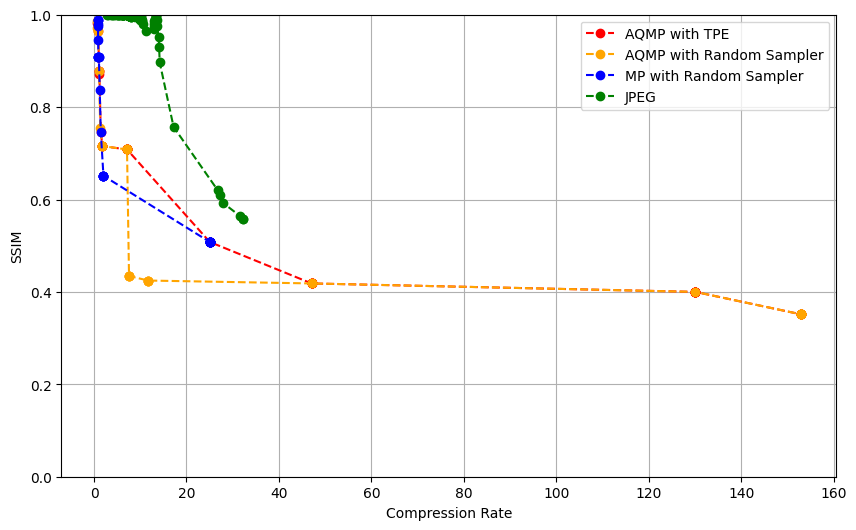

[I 2025-04-21 23:05:20,231] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H06_time:2025-04-21_23-05-20


image name: H06


[I 2025-04-21 23:05:22,222] Trial 0 finished with values: [127.92540398346486, 0.41617169648792435] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-21 23:06:17,316] Trial 1 finished with values: [1.3707259128018765, 0.8068731939521507] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-21 23:06:18,462] Trial 2 finished with values: [335.37881773399016, 0.41705707334795555] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-21 23:06:24,049] Trial 3 finished with values: [3.5745097524479563, 0.569851369978499] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H06_time:2025-04-21_23-05-20 ---
Compression: 1.0040, SSIM: 0.9913, Hyperparams: {'min_sparcity': 0.5697377966634142, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.21361121359925972, 'exponent_a_cols': 7}
Compression: 1.2015, SSIM: 0.8687, Hyperparams: {'min_sparcity': 0.5428099754196685, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 4.303218042749878, 'exponent_a_cols': 6}
Compression: 1.3721, SSIM: 0.8490, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.6780, SSIM: 0.7608, Hyperparams: {'min_sparcity': 0.5814221286882726, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 19.15124160727716, 'exponent_a_cols': 2}
Compression: 11.3360, SSIM: 0.6755, Hyperparams: {'min_sparcity': 0.5165490113362541, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.18358463334432154, 'exponent

[I 2025-04-21 23:23:23,777] Trial 0 finished with values: [127.92540398346486, 0.41617169648792435] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-21 23:24:12,037] Trial 1 finished with values: [1.3707259128018765, 0.8068731939521507] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-21 23:24:13,209] Trial 2 finished with values: [335.37881773399016, 0.41705707334795555] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-21 23:24:18,370] Trial 3 finished with values: [3.5745097524479563, 0.569851369978499] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[

...

8 8


[I 2025-04-22 00:29:05,251] Trial 98 finished with values: [3.642379464572321, 0.6288135435763991] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 00:29:16,698] Trial 99 finished with values: [3.642379464572321, 0.6288135435763991] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H06_time:2025-04-21_23-05-20 ---
Compression: 1.0145, SSIM: 0.9813, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 1.0145, SSIM: 0.9813, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 1.0147, SSIM: 0.9792, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.2471662717603027, 'max_error': 0.007402343469704424}
Compression: 1.0147, SSIM: 0.9768, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.26536221143800404, 'max_error': 9.118098432074813}
Compression: 1.0155, SSIM: 0.9760, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.6534642914699875, 'max_error': 16.285506249643184}
Compression: 1.0208, SSIM: 0.9613, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.6348272397372903, 'max_error': 58.731057569583825}
Compression: 1.0236, SSIM: 0.9572, 

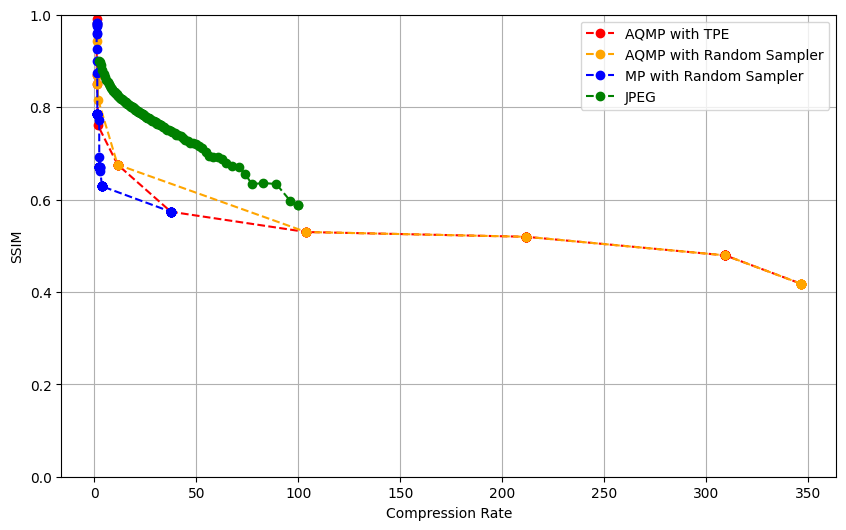

[I 2025-04-22 00:29:28,475] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H04_time:2025-04-22_00-29-28


image name: H04


[I 2025-04-22 00:29:30,666] Trial 0 finished with values: [40.363612565445024, 0.5911087807225149] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 00:30:30,172] Trial 1 finished with values: [0.6285257736371289, 0.8165183710343088] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 00:30:31,610] Trial 2 finished with values: [102.86124082721814, 0.6159208281367665] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 00:30:39,049] Trial 3 finished with values: [2.070554268640682, 0.6908038772598745] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H04_time:2025-04-22_00-29-28 ---
Compression: 0.5721, SSIM: 0.9906, Hyperparams: {'min_sparcity': 0.6840185829342464, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.002557091172309978, 'exponent_a_cols': 7}
Compression: 0.6750, SSIM: 0.9863, Hyperparams: {'min_sparcity': 0.8133624203773346, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 2.4649156439639843, 'exponent_a_cols': 7}
Compression: 0.8692, SSIM: 0.9731, Hyperparams: {'min_sparcity': 0.6903313044417919, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 1.8353636545515983, 'exponent_a_cols': 3}
Compression: 0.9444, SSIM: 0.9548, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 0.9898, SSIM: 0.9329, Hyperparams: {'min_sparcity': 0.7921092095048557, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 360.8214494569023, 'exponent

[I 2025-04-22 01:00:10,894] Trial 0 finished with values: [40.363612565445024, 0.5911087807225149] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 01:01:12,830] Trial 1 finished with values: [0.6285257736371289, 0.8165183710343088] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 01:01:14,235] Trial 2 finished with values: [102.86124082721814, 0.6159208281367665] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 01:01:19,619] Trial 3 finished with values: [2.070554268640682, 0.6908038772598745] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 

...

8 8


[I 2025-04-22 02:00:24,578] Trial 98 finished with values: [1.57572877545285, 0.7889353056554961] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 02:00:41,736] Trial 99 finished with values: [2.429665463828178, 0.7893557919317166] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H04_time:2025-04-22_00-29-28 ---
Compression: 0.7435, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 0.7620, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 0.7689, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.7715, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.7716, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.2202157195714934, 'max_error': 0.012329623163659839}
Compression: 0.7718, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.7723, SSIM: 0.98

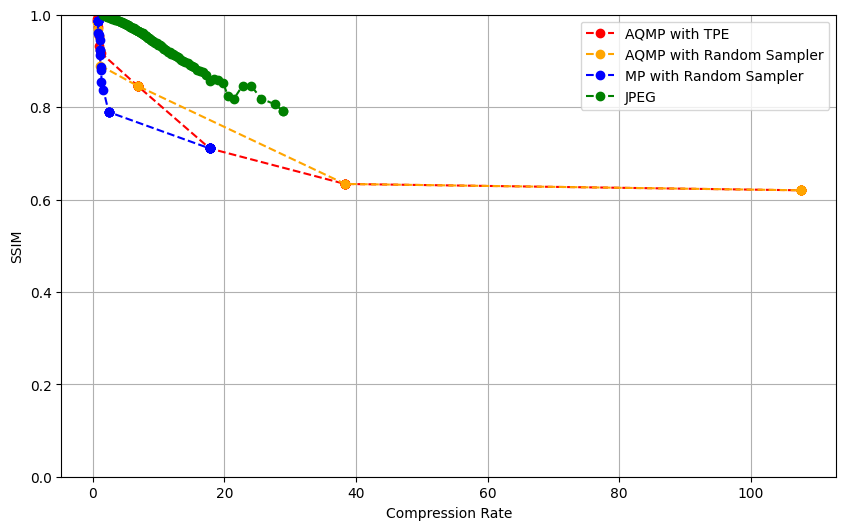

[I 2025-04-22 02:00:59,432] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H10_time:2025-04-22_02-00-59


image name: H10


[I 2025-04-22 02:01:03,182] Trial 0 finished with values: [45.09475440760357, 0.6322069631115427] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 02:03:10,178] Trial 1 finished with values: [0.6982971212732324, 0.8333138040210123] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 02:03:13,028] Trial 2 finished with values: [117.4269790289061, 0.6303796287394037] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 02:03:24,804] Trial 3 finished with values: [2.0859530481767994, 0.7900173549114774] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H10_time:2025-04-22_02-00-59 ---
Compression: 0.5665, SSIM: 0.9944, Hyperparams: {'min_sparcity': 0.4852043130271341, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.00283965337549372, 'exponent_a_cols': 8}
Compression: 0.8685, SSIM: 0.9770, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.3090, SSIM: 0.9378, Hyperparams: {'min_sparcity': 0.7208042185354675, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.002855622175154503, 'exponent_a_cols': 2}
Compression: 1.3090, SSIM: 0.9378, Hyperparams: {'min_sparcity': 0.7661592827706074, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 1.8698795490254025, 'exponent_a_cols': 2}
Compression: 1.3090, SSIM: 0.9378, Hyperparams: {'min_sparcity': 0.3246427308916084, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.009090467214755694, 'expo

[I 2025-04-22 02:43:13,999] Trial 0 finished with values: [45.09475440760357, 0.6322069631115427] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 02:45:21,372] Trial 1 finished with values: [0.6982971212732324, 0.8333138040210123] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 02:45:24,091] Trial 2 finished with values: [117.4269790289061, 0.6303796287394037] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 02:45:36,249] Trial 3 finished with values: [2.0859530481767994, 0.7900173549114774] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2

...

8 8


[I 2025-04-22 04:51:20,360] Trial 98 finished with values: [1.5505111484750362, 0.8562084190981446] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 04:51:57,379] Trial 99 finished with values: [2.5238193852275956, 0.8564441384732394] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H10_time:2025-04-22_02-00-59 ---
Compression: 0.7437, SSIM: 0.9940, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.7455, SSIM: 0.9940, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.7456, SSIM: 0.9940, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.2202157195714934, 'max_error': 0.012329623163659839}
Compression: 0.7456, SSIM: 0.9940, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.7459, SSIM: 0.9940, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.8260, SSIM: 0.9753, Hyperparams: {'exponent_a_cols': 6, 'min_sparcity': 0.8727459842858405, 'max_error': 66.37926838138381}
Compression: 1.0565, SSIM: 0.961

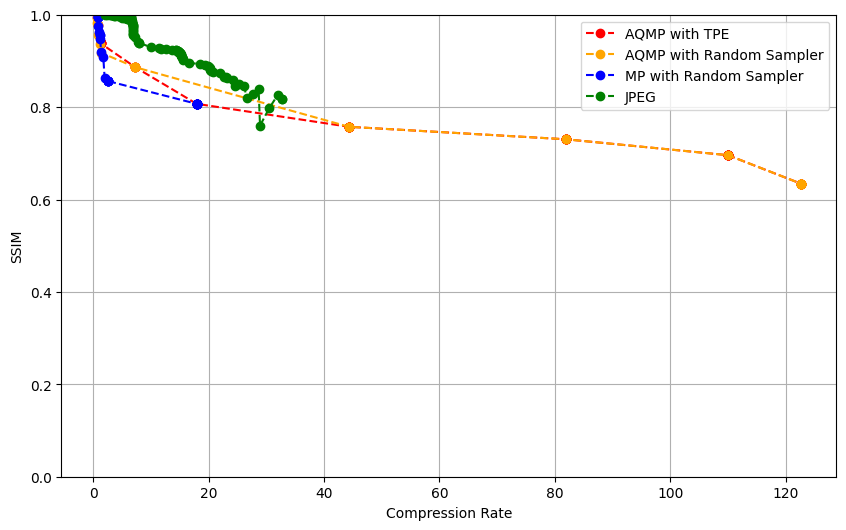

[I 2025-04-22 04:52:33,005] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H05_time:2025-04-22_04-52-32


image name: H05


[I 2025-04-22 04:52:36,690] Trial 0 finished with values: [32.67788948114163, 0.39331961247396324] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 04:53:58,430] Trial 1 finished with values: [0.597415044696438, 0.9315944948697097] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 04:54:00,415] Trial 2 finished with values: [144.52969262906595, 0.3840927377977846] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 04:54:07,513] Trial 3 finished with values: [1.8973556373893286, 0.5622567661770183] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H05_time:2025-04-22_04-52-32 ---
Compression: 0.6388, SSIM: 0.9886, Hyperparams: {'min_sparcity': 0.4461660281817127, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.019320691855691824, 'exponent_a_cols': 8}
Compression: 0.6838, SSIM: 0.9688, Hyperparams: {'min_sparcity': 0.5986245803645358, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 132.4518781776861, 'exponent_a_cols': 8}
Compression: 0.9454, SSIM: 0.9572, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 0.9456, SSIM: 0.9572, Hyperparams: {'min_sparcity': 0.8538477541997039, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 41.03578856738708, 'exponent_a_cols': 8}
Compression: 1.0114, SSIM: 0.9508, Hyperparams: {'min_sparcity': 0.6965237870232485, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 984.5175344538734, 'exponent_a

[I 2025-04-22 05:29:09,107] Trial 0 finished with values: [32.67788948114163, 0.39331961247396324] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 05:30:30,627] Trial 1 finished with values: [0.597415044696438, 0.9315944948697097] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 05:30:32,708] Trial 2 finished with values: [144.52969262906595, 0.3840927377977846] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 05:30:40,677] Trial 3 finished with values: [1.8973556373893286, 0.5622567661770183] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 

...

8 8


[I 2025-04-22 06:53:16,450] Trial 98 finished with values: [1.3856847755181452, 0.6720013934144169] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 06:53:38,344] Trial 99 finished with values: [2.018323810952613, 0.6720459241488697] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H05_time:2025-04-22_04-52-32 ---
Compression: 0.7803, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 0.7807, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.7813, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.2202157195714934, 'max_error': 0.012329623163659839}
Compression: 0.7813, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.7814, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.7814, SSIM: 0.9783, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.8108, SSIM: 0.9

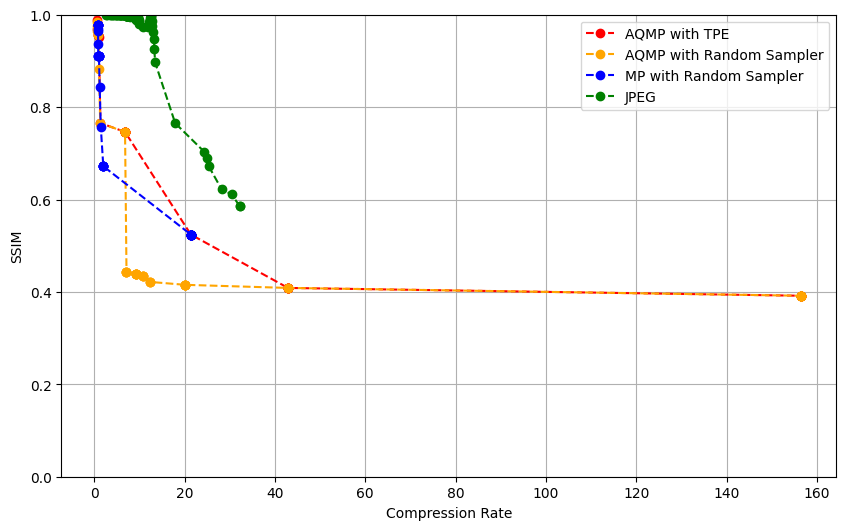

[I 2025-04-22 06:54:04,516] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H01_time:2025-04-22_06-54-04


image name: H01


[I 2025-04-22 06:54:06,580] Trial 0 finished with values: [114.26820693119036, 0.19038210022635993] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 06:55:22,535] Trial 1 finished with values: [1.2537238421785262, 0.7717443352298194] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 06:55:23,811] Trial 2 finished with values: [401.81561285764747, 0.18424650737511525] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 06:55:31,397] Trial 3 finished with values: [3.2634103518908466, 0.3557403015658375] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.



--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H01_time:2025-04-22_06-54-04 ---
Compression: 0.9988, SSIM: 0.9964, Hyperparams: {'min_sparcity': 0.5322089835197499, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.17360211153938548, 'exponent_a_cols': 7}
Compression: 0.9988, SSIM: 0.9964, Hyperparams: {'min_sparcity': 0.5697377966634142, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.21361121359925972, 'exponent_a_cols': 7}
Compression: 1.0099, SSIM: 0.9831, Hyperparams: {'min_sparcity': 0.040478769697670836, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 0.5700728038007931, 'exponent_a_cols': 8}
Compression: 1.0525, SSIM: 0.8568, Hyperparams: {'min_sparcity': 0.15933044186927015, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 1.5148976098108415, 'exponent_a_cols': 4}
Compression: 1.2537, SSIM: 0.7717, Hyperparams: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'expone

[I 2025-04-22 07:22:54,756] Trial 0 finished with values: [114.26820693119036, 0.19038210022635993] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 07:24:08,757] Trial 1 finished with values: [1.2537238421785262, 0.7717443352298194] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 07:24:10,059] Trial 2 finished with values: [401.81561285764747, 0.18424650737511525] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 07:24:17,618] Trial 3 finished with values: [3.2634103518908466, 0.3557403015658375] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.


...

8 8


[I 2025-04-22 09:03:05,139] Trial 98 finished with values: [3.492321767375033, 0.3892986493523101] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 09:03:23,881] Trial 99 finished with values: [3.492321767375033, 0.3892986493523101] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H01_time:2025-04-22_06-54-04 ---
Compression: 1.0089, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 1.0089, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 1.0090, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 1.0090, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 1.0091, SSIM: 0.9863, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 1.0094, SSIM: 0.9859, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.5596488034834677, 'max_error': 1.506272232520005}
Compression: 1.0094, SSIM: 0.9855, H

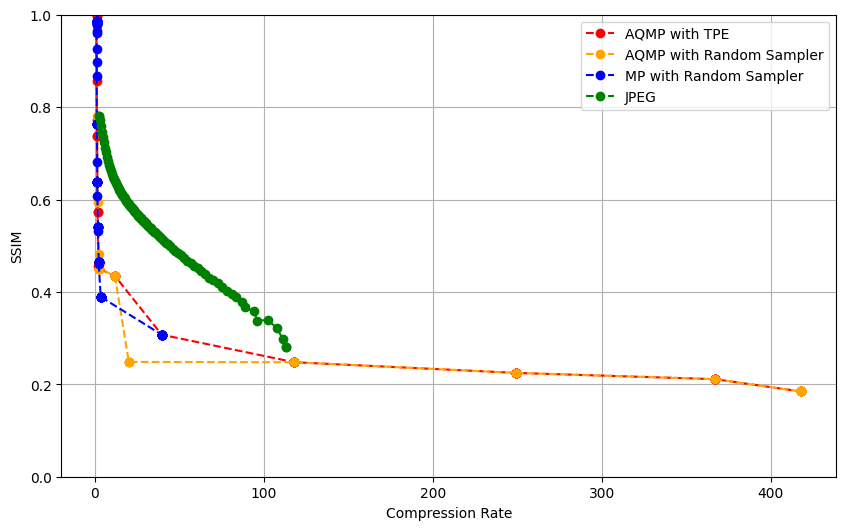

[I 2025-04-22 09:03:46,449] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46


image name: H02


[I 2025-04-22 09:03:51,726] Trial 0 finished with values: [49.73656404904774, 0.6511181235489748] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 09:06:24,613] Trial 1 finished with values: [0.7053905099496045, 0.8046620303646362] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 09:06:28,390] Trial 2 finished with values: [116.2972395912765, 0.6502153807343799] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 09:06:43,722] Trial 3 finished with values: [2.1957597152795376, 0.7474053303883199] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46 ---
Compression: 0.7187, SSIM: 0.9920, Hyperparams: {'min_sparcity': 0.8588172187092555, 'exponent_min_n': 3, 'exponent_max_n': 3, 'max_error': 0.16618110531791752, 'exponent_a_cols': 7}
Compression: 0.9124, SSIM: 0.9652, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.5943, SSIM: 0.8486, Hyperparams: {'min_sparcity': 0.7059458186634266, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 745.8764458520631, 'exponent_a_cols': 8}
Compression: 7.2619, SSIM: 0.8416, Hyperparams: {'min_sparcity': 0.9523751422057474, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 23.585231243148908, 'exponent_a_cols': 1}
Compression: 7.2619, SSIM: 0.8416, Hyperparams: {'min_sparcity': 0.9474784166555423, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 18.946814542050667, 'exponent_

[I 2025-04-22 10:05:30,513] Trial 0 finished with values: [49.73656404904774, 0.6511181235489748] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 10:08:27,690] Trial 1 finished with values: [0.7053905099496045, 0.8046620303646362] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 10:08:31,678] Trial 2 finished with values: [116.2972395912765, 0.6502153807343799] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 10:08:47,883] Trial 3 finished with values: [2.1957597152795376, 0.7474053303883199] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2

...

8 8


[I 2025-04-22 12:48:32,478] Trial 98 finished with values: [1.5843579760069477, 0.805934610672243] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 12:49:19,342] Trial 99 finished with values: [2.5919904554400253, 0.8062354961009316] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46 ---
Compression: 0.7144, SSIM: 0.9920, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 0.7332, SSIM: 0.9920, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 0.7396, SSIM: 0.9920, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.7416, SSIM: 0.9920, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 0.7967, SSIM: 0.9677, Hyperparams: {'exponent_a_cols': 6, 'min_sparcity': 0.8727459842858405, 'max_error': 66.37926838138381}
Compression: 0.9902, SSIM: 0.9515, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.812012260732389, 'max_error': 159.38003265859828}
Compression: 1.0010, SSIM: 0.9377, Hype

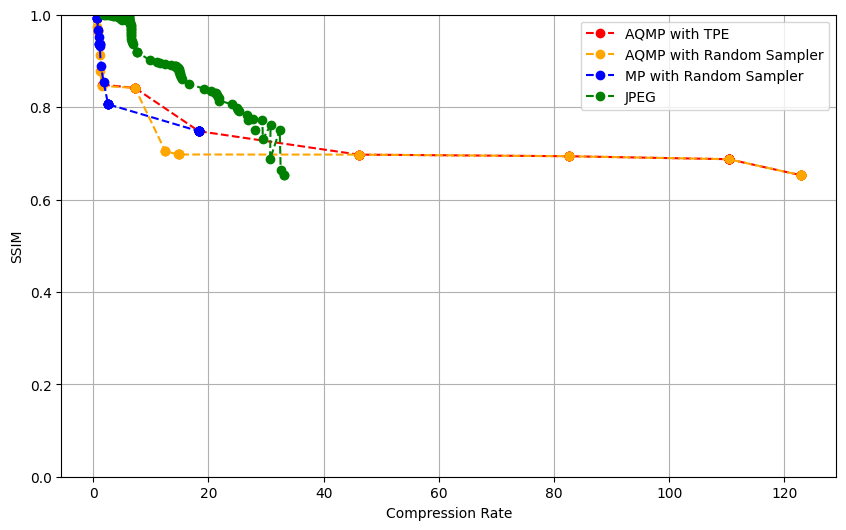

[I 2025-04-22 12:50:06,222] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H03_time:2025-04-22_12-50-06


image name: H03


[I 2025-04-22 12:50:07,897] Trial 0 finished with values: [83.56561769960149, 0.500454475481437] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 12:50:48,955] Trial 1 finished with values: [1.3266814583074262, 0.8624644801430374] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 12:50:50,005] Trial 2 finished with values: [282.70897257089723, 0.5119976989071123] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 12:50:54,605] Trial 3 finished with values: [3.3262971917426074, 0.589506501405891] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 20


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H03_time:2025-04-22_12-50-06 ---
Compression: 1.1338, SSIM: 0.9239, Hyperparams: {'min_sparcity': 0.8489959978323228, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 57.997250197228865, 'exponent_a_cols': 5}
Compression: 1.1772, SSIM: 0.9165, Hyperparams: {'min_sparcity': 0.9070539796198723, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 2.2189558775466853, 'exponent_a_cols': 6}
Compression: 1.1780, SSIM: 0.9161, Hyperparams: {'min_sparcity': 0.764739443382388, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 34.97807455470175, 'exponent_a_cols': 6}
Compression: 1.2998, SSIM: 0.9157, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.2998, SSIM: 0.9157, Hyperparams: {'min_sparcity': 0.9666866353335763, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 0.7367920218351394, 'exponent_a_

[I 2025-04-22 13:08:18,897] Trial 0 finished with values: [83.56561769960149, 0.500454475481437] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 13:08:59,156] Trial 1 finished with values: [1.3266814583074262, 0.8624644801430374] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 13:09:00,244] Trial 2 finished with values: [282.70897257089723, 0.5119976989071123] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 13:09:04,844] Trial 3 finished with values: [3.3262971917426074, 0.589506501405891] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 20

...

8 8


[I 2025-04-22 14:03:57,687] Trial 98 finished with values: [3.2638474419802916, 0.639690911363786] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 14:04:08,625] Trial 99 finished with values: [3.2638824779673024, 0.6396908652568379] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H03_time:2025-04-22_12-50-06 ---
Compression: 1.0121, SSIM: 0.9792, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.86212327742378, 'max_error': 0.0011008110571039537}
Compression: 1.0151, SSIM: 0.9737, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.6534642914699875, 'max_error': 16.285506249643184}
Compression: 1.0500, SSIM: 0.9593, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.6348272397372903, 'max_error': 58.731057569583825}
Compression: 1.0694, SSIM: 0.9557, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.9659757127438138, 'max_error': 70.85721663941601}
Compression: 1.3317, SSIM: 0.9321, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.812012260732389, 'max_error': 159.38003265859828}
Compression: 1.5419, SSIM: 0.9165, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.9401039521485473, 'max_error': 233.86439256208715}
Compression: 1.5977, SSIM: 0.9049, Hyperp

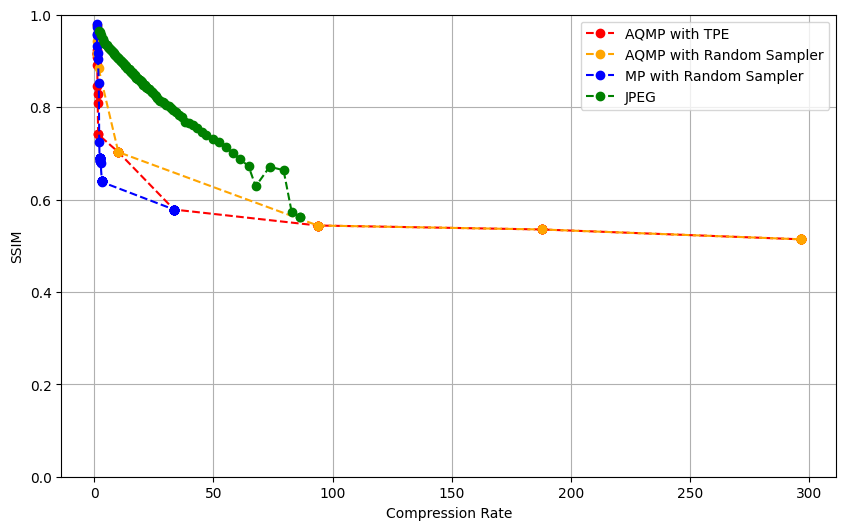

[I 2025-04-22 14:04:22,136] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H08_time:2025-04-22_14-04-22


image name: H08


[I 2025-04-22 14:04:25,038] Trial 0 finished with values: [61.59720021130481, 0.545200986093615] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 14:05:51,657] Trial 1 finished with values: [0.6887806261158753, 0.8143584720212226] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 14:05:53,719] Trial 2 finished with values: [140.1484375, 0.5506268289394697] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 14:06:01,963] Trial 3 finished with values: [2.313607412845493, 0.6799718216087433] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2025-04-2


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H08_time:2025-04-22_14-04-22 ---
Compression: 0.7258, SSIM: 0.9764, Hyperparams: {'min_sparcity': 0.33865642019889675, 'exponent_min_n': 2, 'exponent_max_n': 3, 'max_error': 0.45802543068538254, 'exponent_a_cols': 7}
Compression: 0.8853, SSIM: 0.9735, Hyperparams: {'min_sparcity': 0.4188815810525183, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 1.1107718444184205, 'exponent_a_cols': 3}
Compression: 0.9644, SSIM: 0.9500, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.3619, SSIM: 0.8969, Hyperparams: {'min_sparcity': 0.10349040795580483, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.0570533965945609, 'exponent_a_cols': 2}
Compression: 1.3619, SSIM: 0.8969, Hyperparams: {'min_sparcity': 0.38215832415826634, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 0.03954490775881338, 'expo

[I 2025-04-22 14:45:27,544] Trial 0 finished with values: [61.59720021130481, 0.545200986093615] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 14:47:03,646] Trial 1 finished with values: [0.6887806261158753, 0.8143584720212226] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 14:47:05,954] Trial 2 finished with values: [140.1484375, 0.5506268289394697] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 14:47:14,356] Trial 3 finished with values: [2.313607412845493, 0.6799718216087433] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2025-04-2

...

8 8


[I 2025-04-22 16:20:15,443] Trial 98 finished with values: [1.677591304410379, 0.7604411785177501] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 16:20:57,763] Trial 99 finished with values: [2.675051761615536, 0.7606911164468179] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H08_time:2025-04-22_14-04-22 ---
Compression: 0.7561, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3015044031488898, 'max_error': 0.2044496500917521}
Compression: 0.7725, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8911052883993906, 'max_error': 0.10665247570647046}
Compression: 0.7788, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.8971303869242583, 'max_error': 0.08091347435997563}
Compression: 0.7807, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.7808, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.2202157195714934, 'max_error': 0.012329623163659839}
Compression: 0.7808, SSIM: 0.9764, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 0.7811, SSIM: 0.97

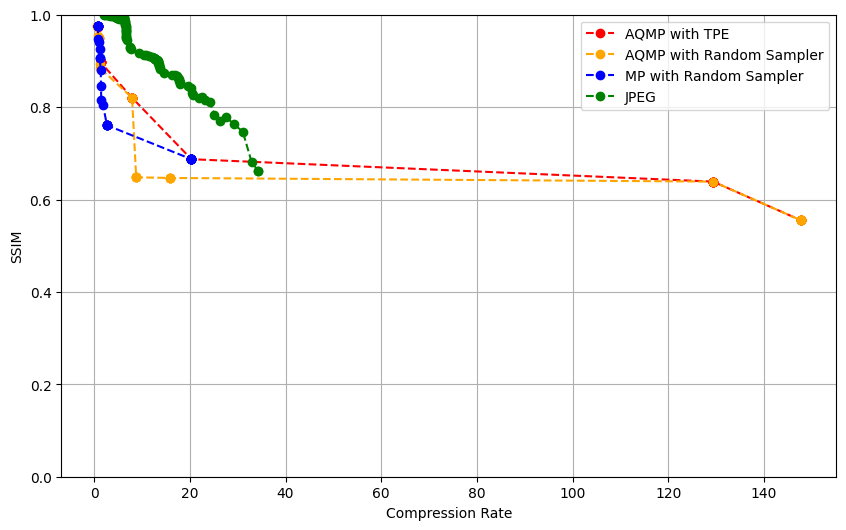

[I 2025-04-22 16:21:31,312] A new study created in RDB with name: multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31


image name: H09


[I 2025-04-22 16:21:35,888] Trial 0 finished with values: [45.653412419449324, 0.6793141047981869] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 16:23:07,875] Trial 1 finished with values: [0.8826599162139701, 0.846324126121897] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 16:23:10,390] Trial 2 finished with values: [157.03853904282116, 0.6810422667585575] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 16:23:19,646] Trial 3 finished with values: [1.989758270938256, 0.7907435034088593] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2


--- Pareto front for study: multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31 ---
Compression: 0.9011, SSIM: 0.9848, Hyperparams: {'min_sparcity': 0.8588172187092555, 'exponent_min_n': 3, 'exponent_max_n': 3, 'max_error': 0.16618110531791752, 'exponent_a_cols': 7}
Compression: 1.0390, SSIM: 0.9589, Hyperparams: {'min_sparcity': 0.44575096880220527, 'exponent_min_n': 2, 'exponent_max_n': 4, 'max_error': 0.001608166928363465, 'exponent_a_cols': 8}
Compression: 1.0543, SSIM: 0.9182, Hyperparams: {'min_sparcity': 0.661827664009737, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 0.6815891546515946, 'exponent_a_cols': 7}
Compression: 6.1006, SSIM: 0.8881, Hyperparams: {'min_sparcity': 0.5288882408093285, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 3.4960212839446423, 'exponent_a_cols': 1}
Compression: 6.1006, SSIM: 0.8881, Hyperparams: {'min_sparcity': 0.313698653132231, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 38.51375134520855, 'exponent_a_

[I 2025-04-22 16:50:17,591] Trial 0 finished with values: [45.653412419449324, 0.6793141047981869] and parameters: {'min_sparcity': 0.3807947176588889, 'exponent_min_n': 7, 'exponent_max_n': 7, 'max_error': 24.658329458549105, 'exponent_a_cols': 5}.
[I 2025-04-22 16:51:57,034] Trial 1 finished with values: [0.8826599162139701, 0.846324126121897] and parameters: {'min_sparcity': 0.16445845403801215, 'exponent_min_n': 2, 'exponent_max_n': 2, 'max_error': 157.41890047456639, 'exponent_a_cols': 5}.
[I 2025-04-22 16:51:59,314] Trial 2 finished with values: [157.03853904282116, 0.6810422667585575] and parameters: {'min_sparcity': 0.710991852018085, 'exponent_min_n': 2, 'exponent_max_n': 7, 'max_error': 98.77700294007911, 'exponent_a_cols': 2}.
[I 2025-04-22 16:52:08,807] Trial 3 finished with values: [1.989758270938256, 0.7907435034088593] and parameters: {'min_sparcity': 0.19000671753502962, 'exponent_min_n': 3, 'exponent_max_n': 4, 'max_error': 1.40779231399724, 'exponent_a_cols': 4}.
[I 2

...

8 8


[I 2025-04-22 22:40:39,608] Trial 98 finished with values: [2.136644664240231, 0.8444623597331308] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.5270208274542564, 'max_error': 41.68322557207813}.


8 8


[I 2025-04-22 22:41:05,566] Trial 99 finished with values: [2.093453456276905, 0.8453357971336649] and parameters: {'exponent_a_cols': 2, 'min_sparcity': 0.6266615710608102, 'max_error': 0.0032515077235891676}.



--- Pareto front for study: MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31 ---
Compression: 0.9146, SSIM: 0.9849, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.32757226432201847, 'max_error': 0.013155612184703926}
Compression: 0.9146, SSIM: 0.9849, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.3237527851047149, 'max_error': 0.010398159624859404}
Compression: 1.0036, SSIM: 0.9708, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.6348272397372903, 'max_error': 58.731057569583825}
Compression: 1.0471, SSIM: 0.9685, Hyperparams: {'exponent_a_cols': 8, 'min_sparcity': 0.9659757127438138, 'max_error': 70.85721663941601}
Compression: 1.1763, SSIM: 0.9577, Hyperparams: {'exponent_a_cols': 6, 'min_sparcity': 0.8727459842858405, 'max_error': 66.37926838138381}
Compression: 1.5609, SSIM: 0.9555, Hyperparams: {'exponent_a_cols': 7, 'min_sparcity': 0.812012260732389, 'max_error': 159.38003265859828}
Compression: 1.7622, SSIM: 0.9493, Hyp

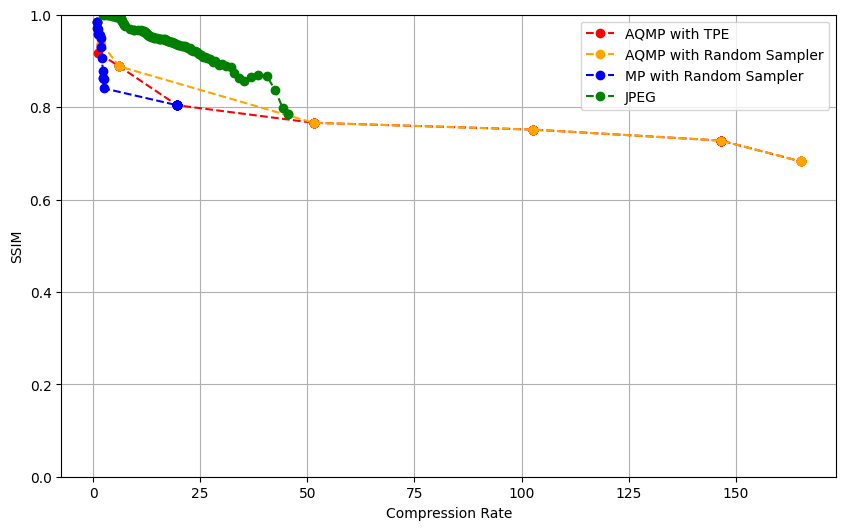

In [31]:
# Global Storage
storage_path = "sqlite:///aqmp_studies.db"

# Experiment Parameters
seed = 42
n_trials = 100
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression

# Train and Save Studies
for image_name in test_images:
    print(f'image name: {image_name}')
    fig, ax = plt.subplots(figsize=(10, 6))
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # Study with AQMP (TPE Sampler)
    study_name = f"multiobjTPE_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="red", label=f"AQMP with TPE")

    # Study with AQMP (Random Sampler)
    study_name = f"multiobjRandomSampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective, n_trials=n_trials)
    plot_pareto_front(ax, study, color="orange", label=f"AQMP with Random Sampler")
    
    # Study without AQ (Random Sampler)
    study_name = f"MP_no_AQ_multiobj_random_sampler_trials:{n_trials}_seed:{seed}_image:{image_name}_time:{timestamp}"
    sampler = RandomSampler(seed=seed)
    study = optuna.create_study(directions=['maximize', 'maximize'], study_name=study_name, sampler=sampler, storage=storage_path)
    study.optimize(objective_no_aq, n_trials=n_trials)
    plot_pareto_front(ax, study, color="blue", label=f"MP with Random Sampler")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path    
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)

    # Formatting the plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    ax.legend()
    plt.legend(loc='best')
    ax.grid(True)
    plt.ylim(0, 1)

    # Save the figure
    file_name = f"{image_name}_comparison_pareto_fronts.png"
    fig.savefig(file_name, dpi=300)
    plt.show()

# Images for paper

In [8]:
storage_path = "sqlite:///aqmp_studies.db"

valid_studies = []
for summary in study_summaries:
    study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
    trials = study.trials
    trial_states = [trial.state for trial in trials]
    
    if len(trials) == 100 and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
        valid_studies.append(summary.study_name)

for s in valid_studies:
    print(s)

NameError: name 'study_summaries' is not defined

In [74]:
storage_path = "sqlite:///aqmp_studies.db"

valid_studies = []
study_summaries = optuna.get_all_study_summaries(storage=storage_path)

for summary in study_summaries:
    if "Clock" not in summary.study_name:
        continue

    study = optuna.load_study(study_name=summary.study_name, storage=storage_path)
    trials = study.trials
    trial_states = [trial.state for trial in trials]

    if len(trials) == 100 and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
        valid_studies.append(summary.study_name)

for s in valid_studies:
    print(s)

multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04


In [ ]:
path_images = 'test_images/'

image_names = [
'Female_(NTSC_test_image)',
'San_Diego',
'San_Francisco',
'Splash',
'H02',
'H09',
'Clock_rgb',
'Airplane_(U-2)_rgb'
]

In [1]:
storage_path = "sqlite:///aqmp_studies.db"

studies_all_types = [
('multiobjTPE_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13',
'multiobjRandomSampler_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13'
),

(
'multiobjTPE_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08',
'multiobjRandomSampler_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08'
),

(
'multiobjTPE_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06',
'multiobjRandomSampler_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06'
),

(
'multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52',
'multiobjRandomSampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52'
),

(
'multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46',
'multiobjRandomSampler_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46'
),
    
(
'multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31',
'multiobjRandomSampler_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31'
),

(
'multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04',
'multiobjRandomSampler_trials:100_seed:43_image:Clock_rgb_time:2025-05-15_15-18-31',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Clock_rgb_time:2025-05-15_15-18-31',
),

(
'multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08',
'multiobjRandomSampler_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-15_15-32-33',
'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-15_15-32-33',
)
    
]

study_names_tpe = [
    tuple_[0] for tuple_ in studies_all_types
]
study_names_tpe

['multiobjTPE_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13',
 'multiobjTPE_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08',
 'multiobjTPE_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06',
 'multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52',
 'multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46',
 'multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31',
 'multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04',
 'multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08']

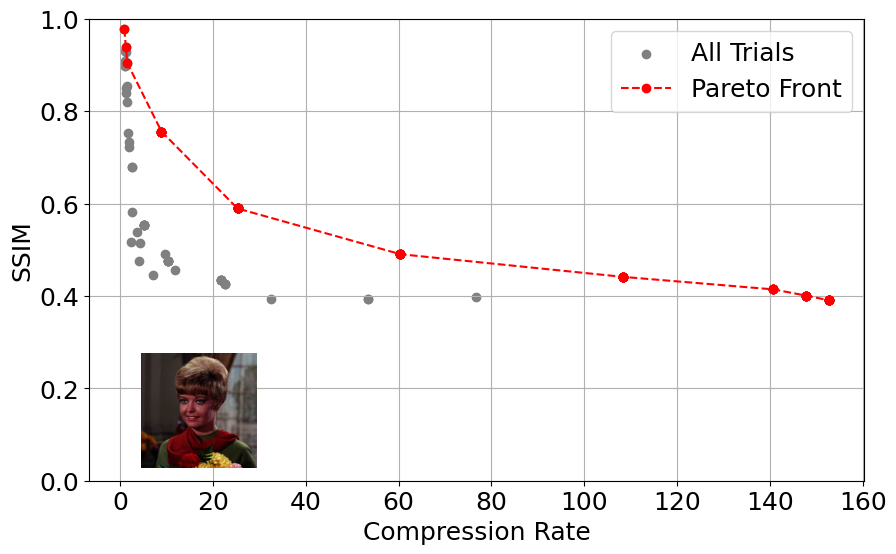

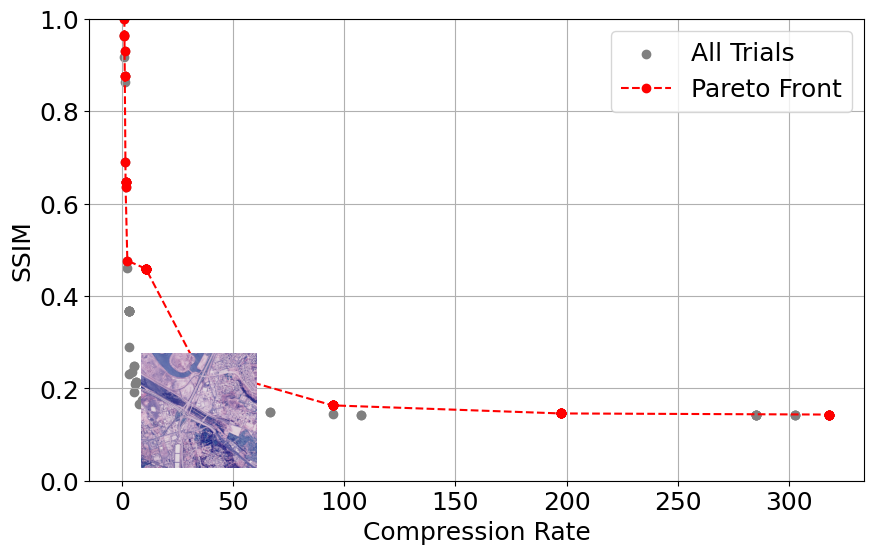

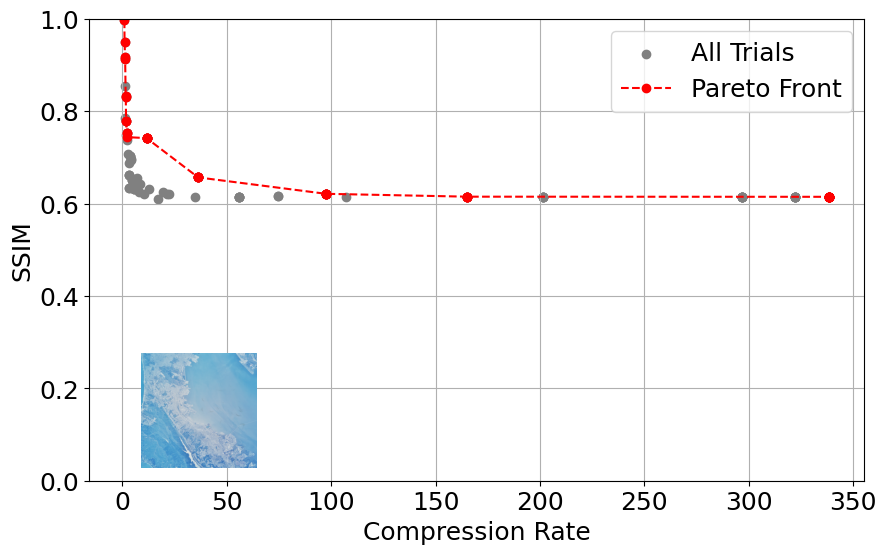

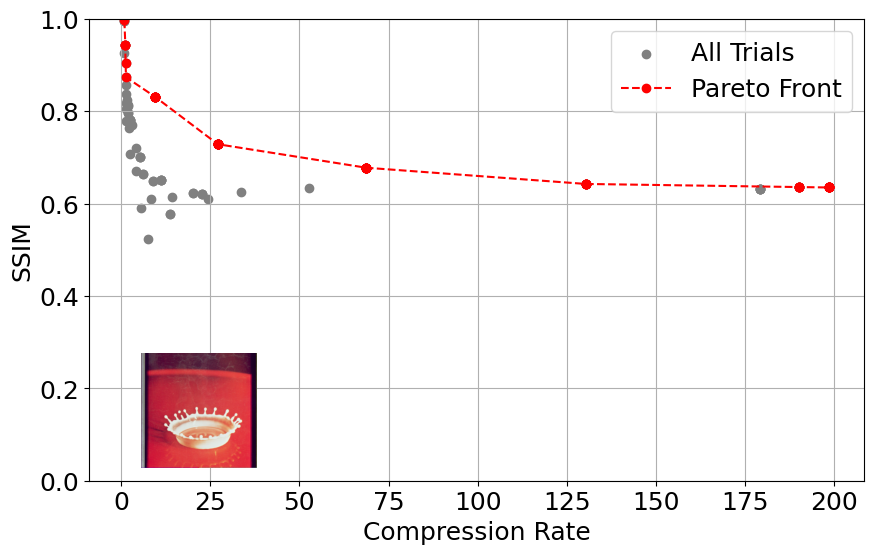

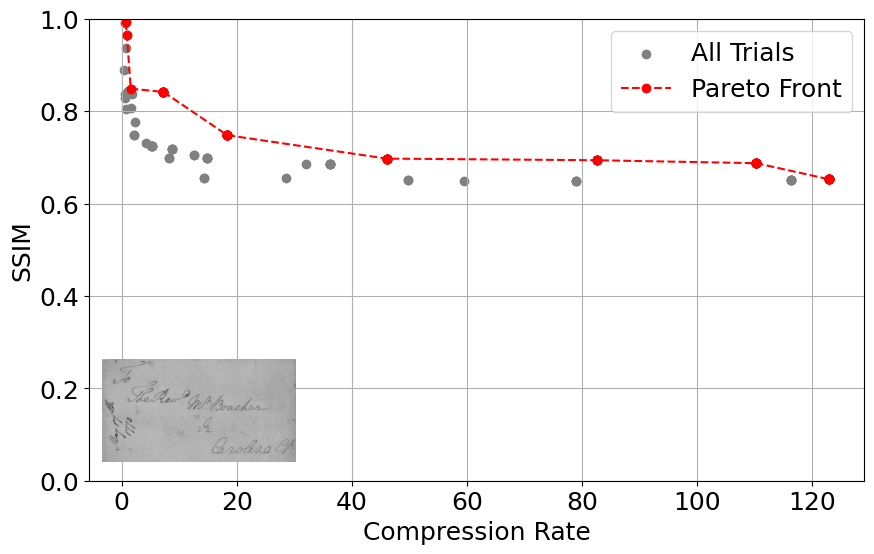

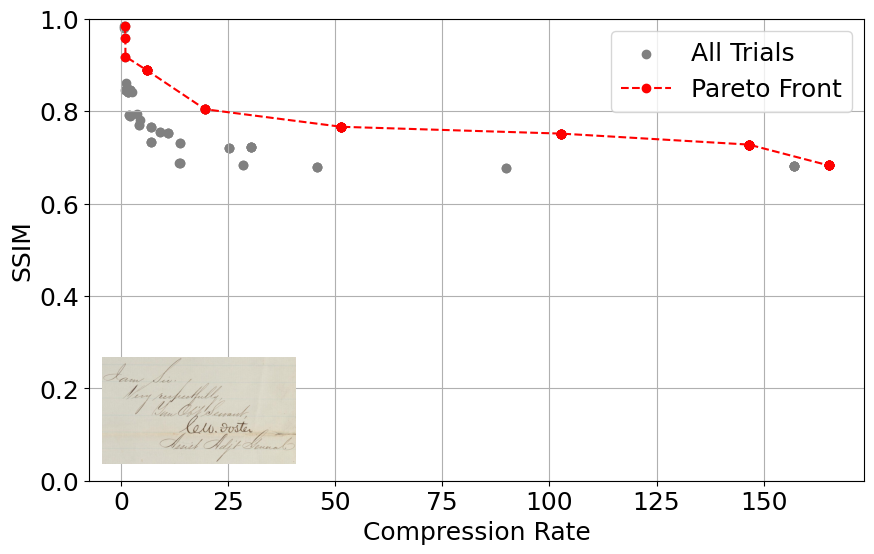

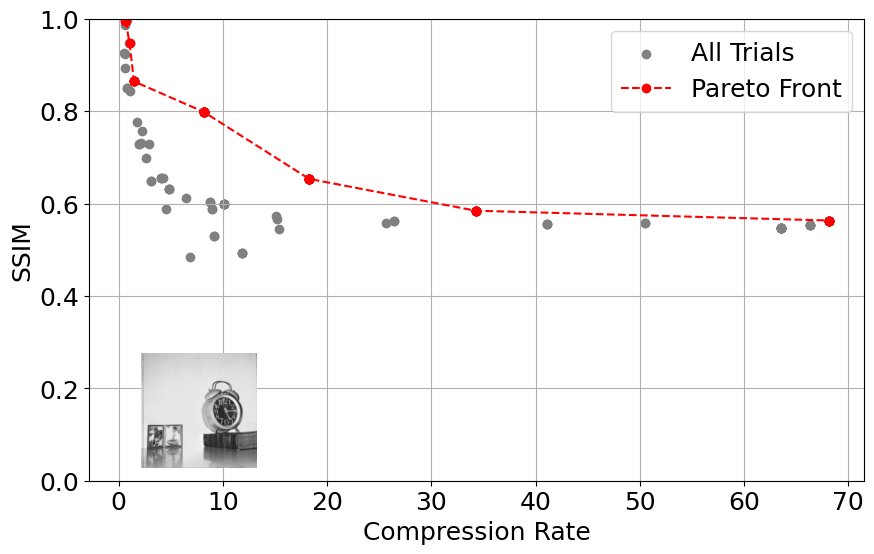

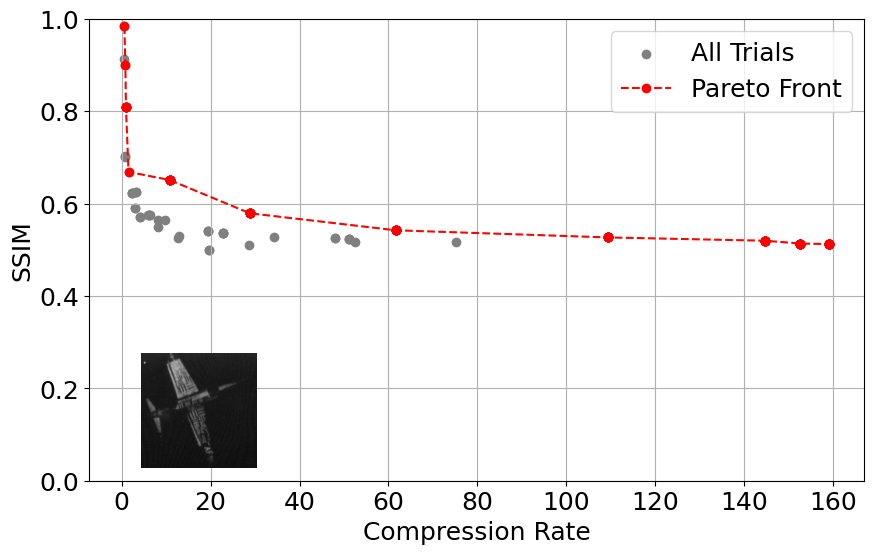

In [18]:
for study_name, image_name in zip(study_names_tpe, image_names):
    study = optuna.load_study(study_name=study_name,
                              storage=storage_path
                             )
    
    compression_rates = [trial.user_attrs["compression_rate"] for trial in study.trials]
    ssim_values = [trial.user_attrs["ssim"] for trial in study.trials]
    
    
    # Extract Pareto front data
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])  # Sort by compression or another objective
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]
    
    """Plot Pareto front and all trials."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(compression_rates, ssim_values, color="grey", label="All Trials")
    ax.plot(pareto_compression, pareto_ssim, 'o--', color="red", label="Pareto Front", markersize=6)
    
    img = mpimg.imread("test_images/"+image_name+".png")
    plt.ylim(0, 1) 
    
    # Create main plot
    # Create inset axes: position = [left, bottom, width, height] in axes fraction
    inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower left')
    # Show image inside the inset
    inset_ax.imshow(img)
    inset_ax.set_zorder(10)  # Force on top

    inset_ax.axis('off') # Hide axis around image

    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    #ax.set_xscale("log")
    ax.grid(True)
    ax.legend()

    fig.savefig(f"{image_name}_pareto_front.png", dpi=300)
    plt.show()

['multiobjTPE_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13', 'multiobjRandomSampler_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13']
Female_(NTSC_test_image)


/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_34365/2995033887.py:70: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



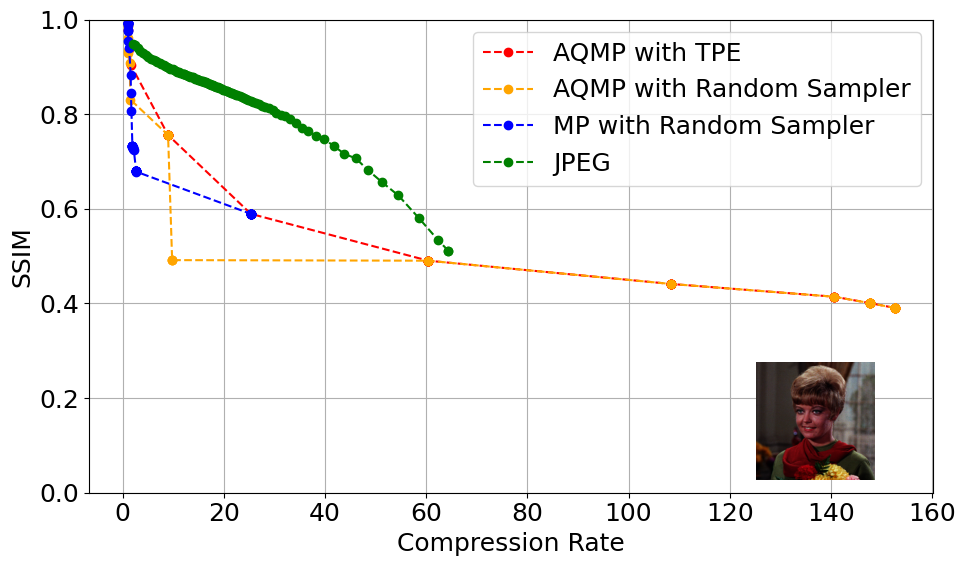

['multiobjTPE_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08', 'multiobjRandomSampler_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08']
San_Diego


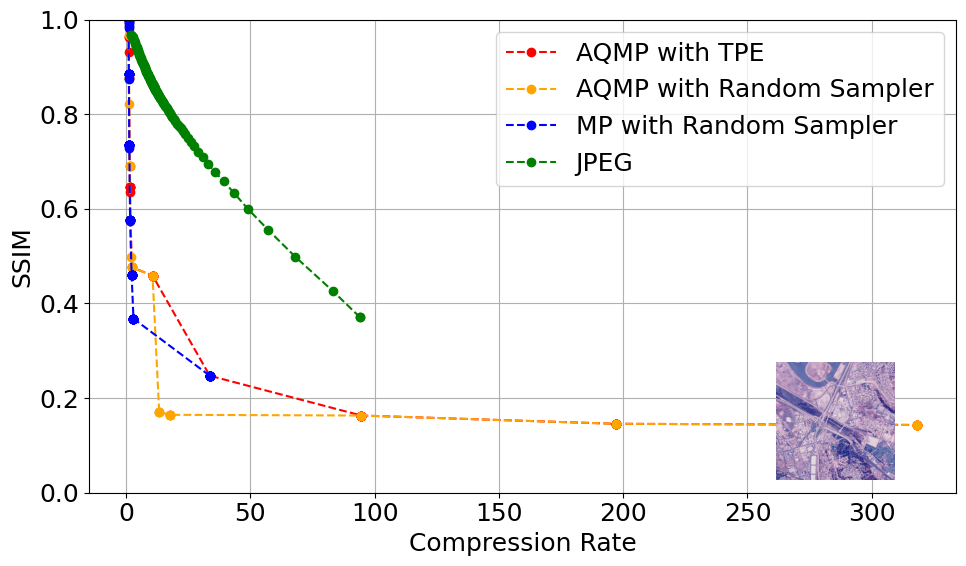

['multiobjTPE_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06', 'multiobjRandomSampler_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06']
San_Francisco


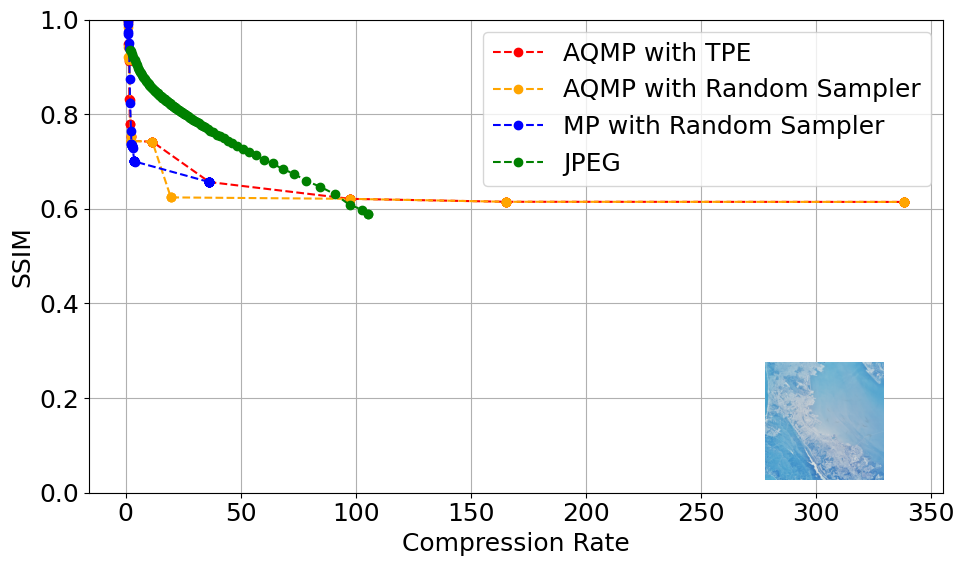

['multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52', 'multiobjRandomSampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52']
Splash


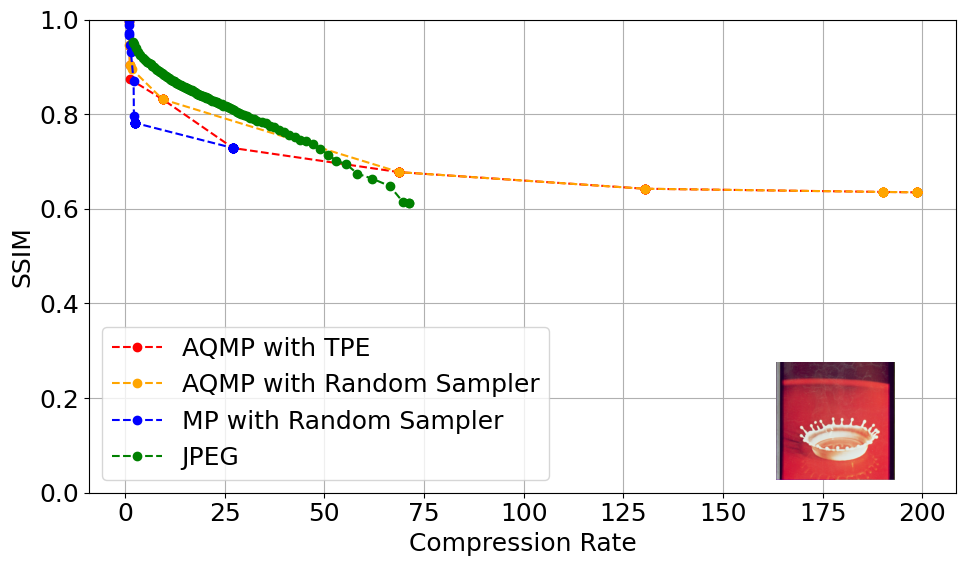

['multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46', 'multiobjRandomSampler_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46']
H02


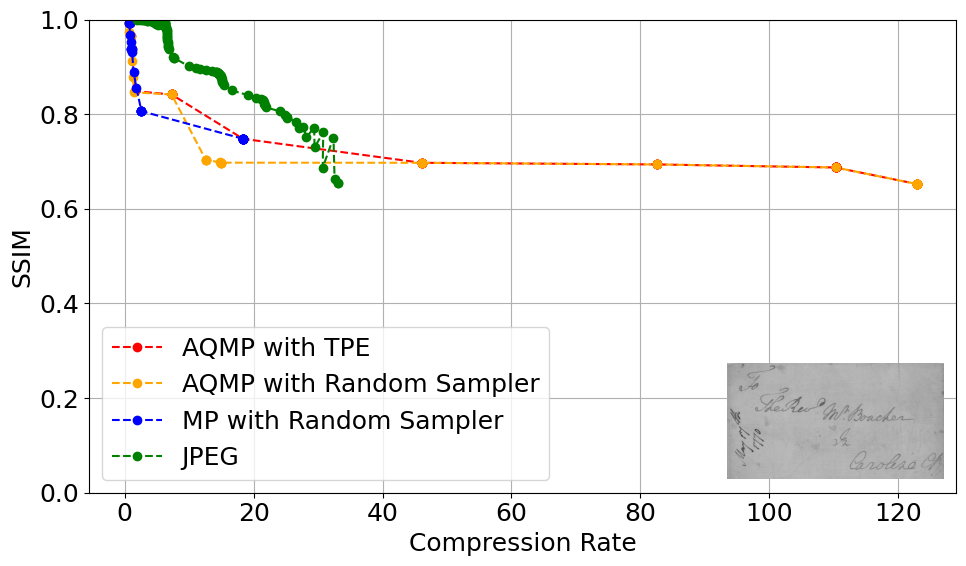

['multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31', 'multiobjRandomSampler_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31']
H09


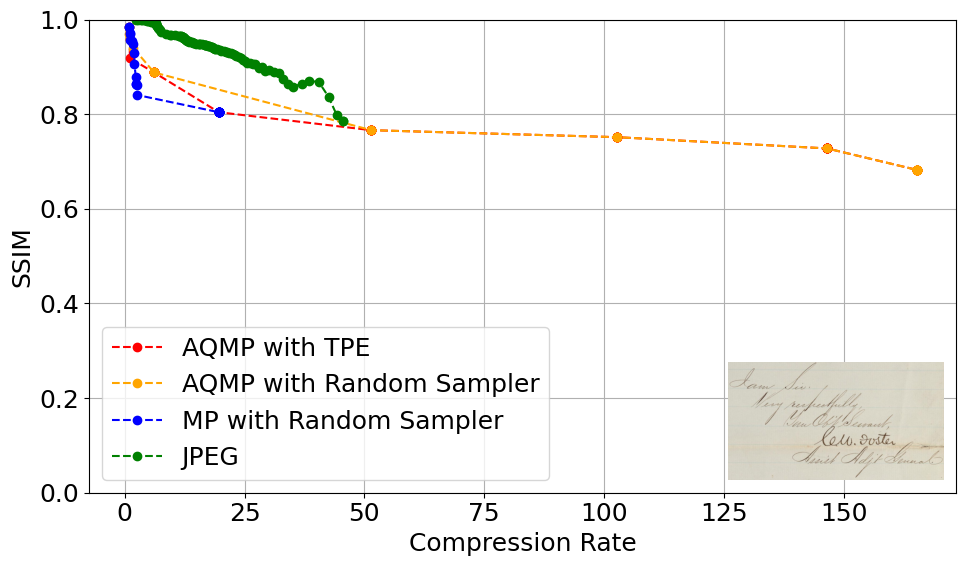

['multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04', 'multiobjRandomSampler_trials:100_seed:43_image:Clock_rgb_time:2025-05-15_15-18-31', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Clock_rgb_time:2025-05-15_15-18-31']
Clock_rgb


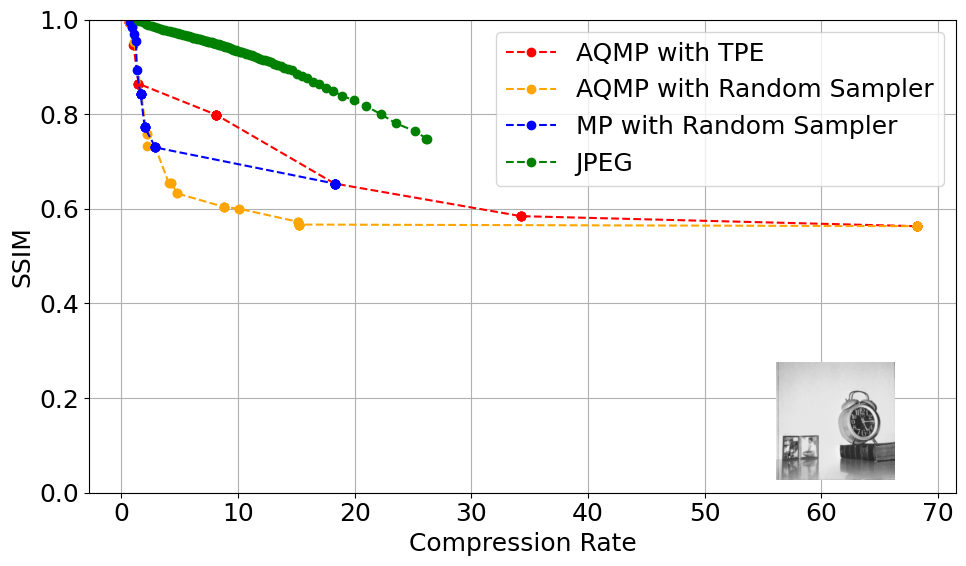

['multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08', 'multiobjRandomSampler_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-15_15-32-33', 'MP_no_AQ_multiobj_random_sampler_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-15_15-32-33']
Airplane_(U-2)_rgb


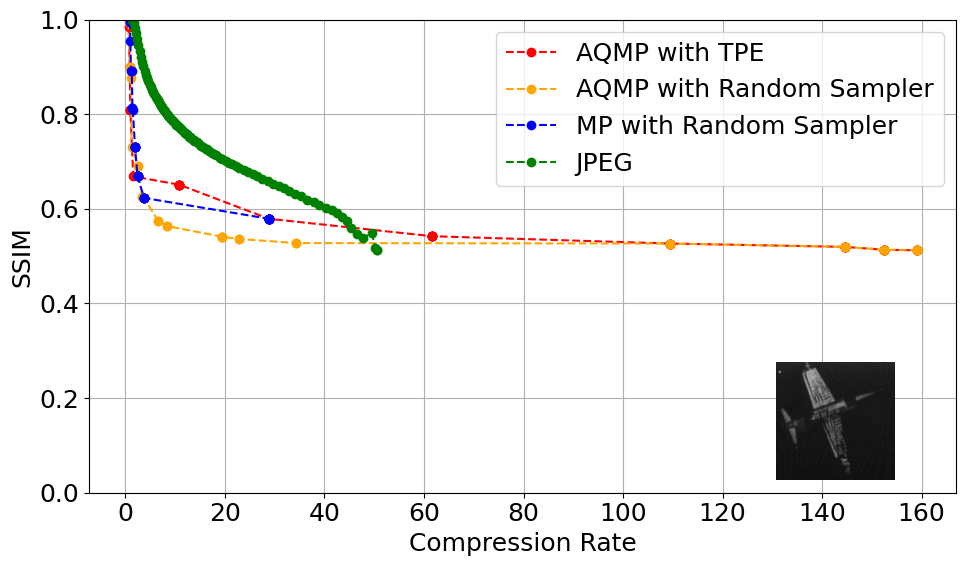

In [19]:
color_map = {
    'TPE': 'red',
    'RandomSampler': 'orange',
    'no_AQ': 'blue'
}
folder_path = 'test_images/'
storage_path = "sqlite:///aqmp_studies.db"
total_trials = 100
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression


for index in range(8):
    study_names = list(studies_all_types[index])
    image_name = image_names[index]
    print(study_names)
    print(image_name)
    fig, ax = plt.subplots(figsize=(10, 6))
    for name in study_names:
        study = optuna.load_study(study_name=name, storage=storage_path)
        trials = study.trials
        trial_states = [t.state for t in trials]
    
        # Filter condition: exactly 100 COMPLETE trials
        if len(trials) == total_trials and all(state == optuna.trial.TrialState.COMPLETE for state in trial_states):
            # Determine label + color
            if "no_AQ" in name:
                color = color_map['no_AQ']
                label = "MP with Random Sampler"
            elif "RandomSampler" in name:
                color = color_map['RandomSampler']
                label = "AQMP with Random Sampler"
            elif "TPE" in name:
                color = color_map['TPE']
                label = "AQMP with TPE"
            else:
                color = 'gray'
                label = name

            plot_pareto_front(ax, study, color=color, label=label)
        else:
            print(f"Skipping {name} (not {total_trials} complete trials)")

    # JPEG
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path
    output_path = "../compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', color="green", label=f"JPEG", markersize=6)
    plt.ylim(0, 1)

    # Create main plot
    # Create inset axes: position = [left, bottom, width, height] in axes fraction
    inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right')
    # Show image inside the inset
    img = mpimg.imread("test_images/"+image_name+".png")
    inset_ax.imshow(img)
    inset_ax.set_zorder(10)  # Force on top
    inset_ax.axis('off') # Hide axis around image
    
    # Finalize plot
    ax.set_xlabel("Compression Rate")
    ax.set_ylabel("SSIM")
    #ax.set_xscale("log")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    fig.savefig(f"{image_name}_comparison.png", dpi=300)
    plt.show()

In [1]:
import platform
import psutil
import subprocess

# CPU info
cpu_name = subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
cores = psutil.cpu_count(logical=False)
threads = psutil.cpu_count(logical=True)

# RAM info
ram_gb = round(psutil.virtual_memory().total / 1e9, 1)

# OS info
os_name = platform.system()
os_version = platform.mac_ver()[0]

# Print formatted system specs
print(f"System: {os_name} {os_version}")
print(f"Processor: {cpu_name} ({cores} cores / {threads} threads)")
print(f"Memory: {ram_gb} GB RAM")

System: Darwin 14.5
Processor: Intel(R) Core(TM) i9-9980HK CPU @ 2.40GHz (8 cores / 16 threads)
Memory: 68.7 GB RAM


# graficos de resultados globales

## AQMP con MOTPE vs JPEG

### imagenes varias

/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_2729/3232882160.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



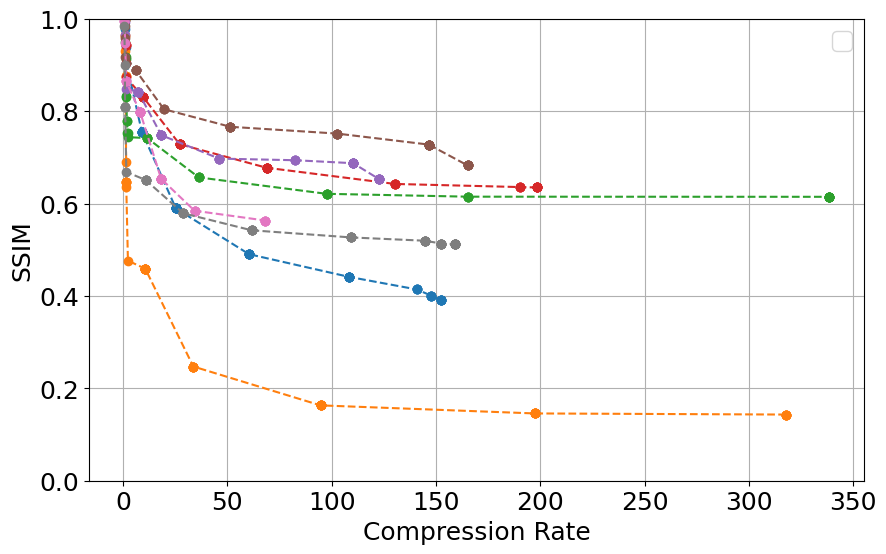

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for study_name, image_name in zip(study_names_tpe, image_names):
    study = optuna.load_study(study_name=study_name,
                              storage=storage_path)
    compression_rates = [trial.user_attrs["compression_rate"] for trial in study.trials]
    ssim_values = [trial.user_attrs["ssim"] for trial in study.trials]
    
    # Extract Pareto front data
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0]) # Sort by compression or another objective
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]
    
    ax.plot(pareto_compression, pareto_ssim, 'o--', markersize=6)
    
plt.ylim(0, 1)
plt.Xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)
ax.legend()
fig.savefig(f"pareto_fronts.png", dpi=300)
plt.show()

/var/folders/qm/f_y2072j25zbg71lhlp9f1dw0000gn/T/ipykernel_2729/945114145.py:20: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



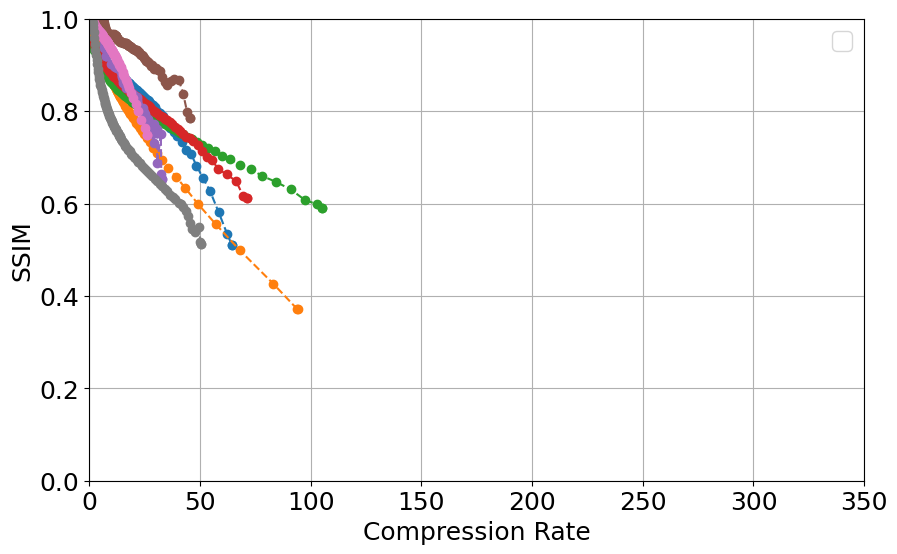

In [24]:
folder_path = 'test_images/'
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression
fig, ax = plt.subplots(figsize=(10, 6))
for index in range(len(image_names):
    image_name = image_names[index]
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path
    output_path = "compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', markersize=6)

plt.ylim(0, 1)
plt.xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.legend()
ax.grid(True)
fig.savefig(f"jpeg_global.png", dpi=300)
plt.show()

AQMP

- mas dispersion de resultados entre imagen e imagen que para JPEG
- se llega a tasas de compresion mas altas, en varios casos con SSIM similar
- es mas lento de entrenar y a priori no sabemos que resultado da cada hiperparametro.

se puede hacer una curva promedio de resultados para AQMP y otra para JPEG.

en los graficos los ejes x tienen diferentes escalas y sesgan la percepcion de los resultados

In [ ]:
#folders
dibco_folder = 'H_DIBCO2010_test_images_png'

In [55]:

storage_path = "sqlite:///aqmp_studies.db"

studies = optuna.study.get_all_study_summaries(storage=storage_path)

In [45]:
# Filter studies whose name starts with "s.study_name"
prefix = "multiobjTPE"  # replace with the actual prefix you want
filtered_studies = [s for s in studies if s.study_name.startswith(prefix)]

for s in filtered_studies:
    if s.n_trials > 90:
            print(f"Study name: {s.study_name}, Trials: {s.n_trials}")

Study name: multiobjTPE_trials:100_seed:43_image:4.2.03_time:2025-04-03_16-43-46, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:4.2.01_time:2025-04-03_17-49-47, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:4.2.05_time:2025-04-03_18-48-33, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:4.2.06_time:2025-04-03_19-42-46, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:4.2.07_time:2025-04-03_20-41-37, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:house_time:2025-04-03_21-39-55, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:Sailboat_on_lake_time:2025-04-07_18-36-51, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:Sailboat_on_lake_time:2025-04-07_19-01-07, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55, Trials: 100
Study name: multiobjTPE_trials:100_seed:43_image:San_Diego_time:2025-04-08_10-51-15, Trials: 100
Study name: multiobj

In [47]:
h_images_prefix = "multiobjTPE_trials:100_seed:42_image:H"  # and storage_path = "sqlite:///aqmp_studies.db"
h_filtered_studies = [s for s in studies if s.study_name.startswith(h_images_prefix)]

for s in h_filtered_studies:
    if s.n_trials > 90:
            print(f"Study name: {s.study_name}, Trials: {s.n_trials}")

Study name: multiobjTPE_trials:100_seed:42_image:H07_time:2025-04-21_20-26-32, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H06_time:2025-04-21_23-05-20, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H04_time:2025-04-22_00-29-28, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H10_time:2025-04-22_02-00-59, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H05_time:2025-04-22_04-52-32, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H01_time:2025-04-22_06-54-04, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H03_time:2025-04-22_12-50-06, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H08_time:2025-04-22_14-04-22, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31, Trials: 100


In [ ]:
prefix = "multiobjTPE"  # replace with the actual prefix you want
filtered_studies = [s for s in studies if s.study_name.startswith(prefix)]

for s in filtered_studies:
    if s.n_trials > 90:
            print(f"Study name: {s.study_name}, Trials: {s.n_trials}")

In [56]:
remaining_studies = [s for s in studies if s not in h_filtered_studies]

prefix = "multiobjTPE_trials:100_seed:43"  # replace with the actual prefix you want
remaining_studies = [s for s in remaining_studies if s.study_name.startswith(prefix)]

for s in remaining_studies:
    if s.n_trials > 90 and s.n_trials < 120:
        print(s.study_name)

multiobjTPE_trials:100_seed:43_image:4.2.05_time:2025-04-03_18-48-33
multiobjTPE_trials:100_seed:43_image:4.2.07_time:2025-04-03_20-41-37
multiobjTPE_trials:100_seed:43_image:house_time:2025-04-03_21-39-55
multiobjTPE_trials:100_seed:43_image:Sailboat_on_lake_time:2025-04-07_19-01-07
multiobjTPE_trials:100_seed:43_image:Mandrill_(a.k.a._Baboon)_time:2025-04-08_09-58-55
multiobjTPE_trials:100_seed:43_image:Splash_time:2025-04-08_11-49-59
multiobjTPE_trials:100_seed:43_image:Female_(NTSC_test_image)_time:2025-04-08_12-39-00
multiobjTPE_trials:100_seed:43_image:San_Diego_time:2025-04-08_16-32-13
multiobjTPE_trials:100_seed:43_image:Splash_time:2025-04-08_17-08-40
multiobjTPE_trials:100_seed:43_image:San_Francisco_time:2025-04-08_17-43-29
multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04
multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08


In [59]:
images_prefix = "multiobjTPE_trials:100_seed:43_image:0"  
kk_filtered_studies = [s for s in studies if s.study_name.startswith(images_prefix)]

for s in kk_filtered_studies:
    if s.n_trials > 90:
            print(f"Study name: {s.study_name}, Trials: {s.n_trials}")

### H_DIBCO2010

Study name: multiobjTPE_trials:100_seed:42_image:H07_time:2025-04-21_20-26-32, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H06_time:2025-04-21_23-05-20, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H04_time:2025-04-22_00-29-28, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H10_time:2025-04-22_02-00-59, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H05_time:2025-04-22_04-52-32, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H01_time:2025-04-22_06-54-04, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H02_time:2025-04-22_09-03-46, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H03_time:2025-04-22_12-50-06, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H08_time:2025-04-22_14-04-22, Trials: 100
Study name: multiobjTPE_trials:100_seed:42_image:H09_time:2025-04-22_16-21-31, Trials: 100


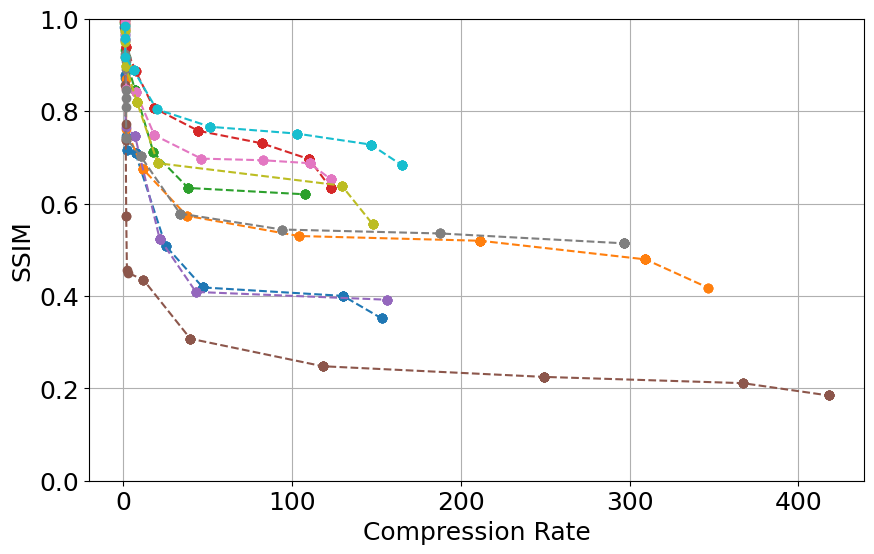

In [70]:
import optuna
import matplotlib.pyplot as plt

storage_path = "sqlite:///aqmp_studies.db"

# Get all studies
studies = optuna.study.get_all_study_summaries(storage=storage_path)

# Filter by prefix
h_images_prefix = "multiobjTPE_trials:100_seed:42_image:H"  
h_filtered_studies = [s for s in studies if s.study_name.startswith(h_images_prefix)]

# Optional: print studies with more than 90 trials
for s in h_filtered_studies:
    if s.n_trials > 90:
        print(f"Study name: {s.study_name}, Trials: {s.n_trials}")

# Plot Pareto fronts
fig, ax = plt.subplots(figsize=(10, 6))

for s in h_filtered_studies:
    study_name = s.study_name
    study = optuna.load_study(study_name=study_name, storage=storage_path)

    compression_rates = [trial.user_attrs.get("compression_rate") for trial in study.trials if "compression_rate" in trial.user_attrs]
    ssim_values = [trial.user_attrs.get("ssim") for trial in study.trials if "ssim" in trial.user_attrs]

    # Skip if no data
    if not compression_rates or not ssim_values:
        continue

    # Extract Pareto front (sort by compression objective)
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]

    ax.plot(pareto_compression, pareto_ssim, 'o--', markersize=6, label=study_name)

ax.set_ylim(0, 1)
#ax.set_xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)
#ax.legend(fontsize="small", loc="best")

fig.savefig("pareto_fronts_H.png", dpi=300)
plt.show()

In [77]:
image_names = ['H01','H02','H03','H04','H05','H06','H07','H08','H09','H10']

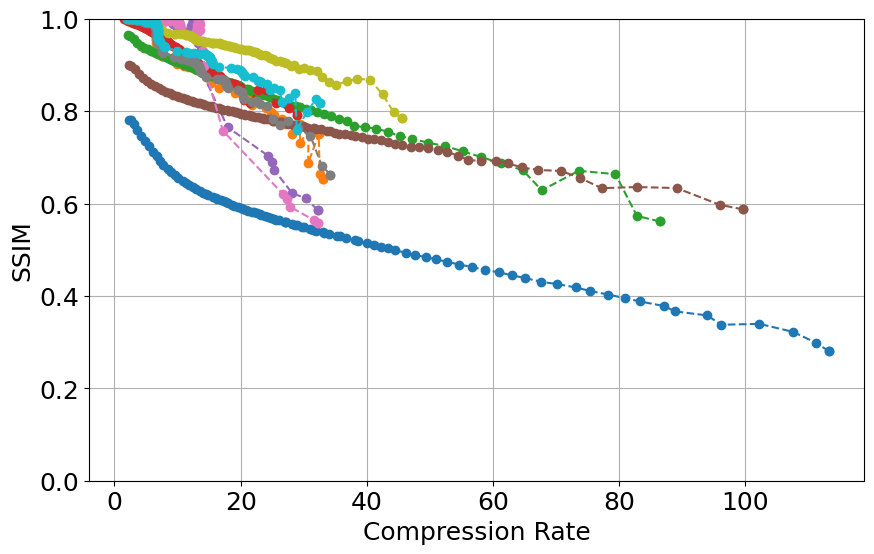

In [79]:
folder_path = '../images/H_DIBCO2010_test_images_png/'
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression
fig, ax = plt.subplots(figsize=(10, 6))
for index in range(10):
    image_name = image_names[index]
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path
    output_path = "compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', markersize=6)

plt.ylim(0, 1)
#plt.xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
#ax.legend()
ax.grid(True)
fig.savefig(f"jpeg_global.png", dpi=300)
plt.show()

H07
H06
H04
H10
H05
H01
H02
H03
H08
H09


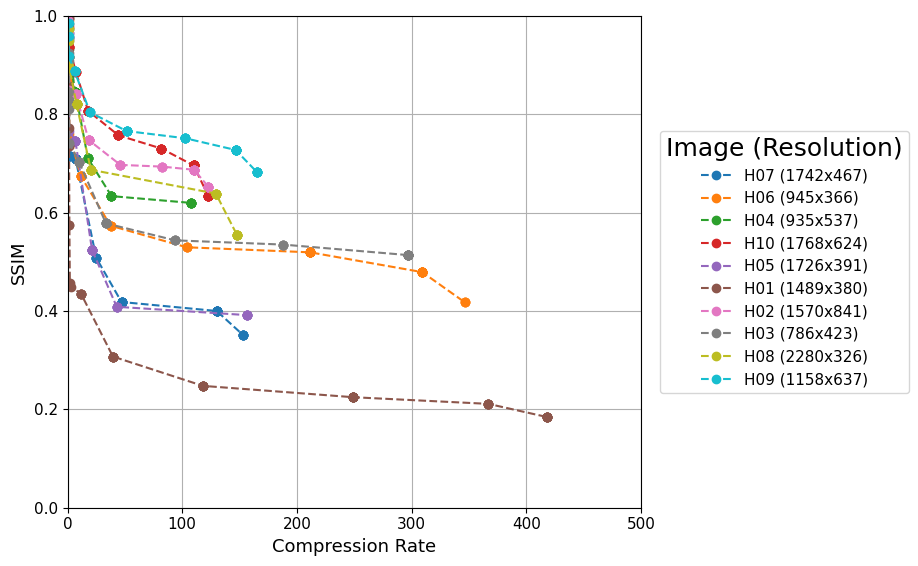

In [24]:
import optuna
import matplotlib.pyplot as plt
from PIL import Image
import os
import re

storage_path = "sqlite:///aqmp_studies.db"
images_dir = "../images/H_DIBCO2010_test_images_png/"

# Obtener todos los estudios
studies = optuna.study.get_all_study_summaries(storage=storage_path)

# Filtrar por prefijo
h_images_prefix = "multiobjTPE_trials:100_seed:42_image:H"
h_filtered_studies = [s for s in studies if s.study_name.startswith(h_images_prefix)]

# Función para obtener resolución real de una imagen
def get_image_resolution(image_name: str):
    """Devuelve la resolución (ancho x alto) si el archivo existe."""
    possible_exts = [".png", ".jpg", ".jpeg", ".webp"]
    for ext in possible_exts:
        path = os.path.join(images_dir, image_name + ext)
        if os.path.exists(path):
            with Image.open(path) as img:
                w, h = img.size
            return f"{w}x{h}"
    return "?"

# Graficar frentes de Pareto
fig, ax = plt.subplots(figsize=(12, 6))

for s in h_filtered_studies:
    study_name = s.study_name
    study = optuna.load_study(study_name=study_name, storage=storage_path)

    compression_rates = [trial.user_attrs.get("compression_rate") for trial in study.trials if "compression_rate" in trial.user_attrs]
    ssim_values = [trial.user_attrs.get("ssim") for trial in study.trials if "ssim" in trial.user_attrs]

    if not compression_rates or not ssim_values:
        continue

    # Extraer frente de Pareto
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]

    # === Extraer nombre de imagen ===
    img_match = re.search(r"image:([A-Za-z0-9_]+)", study_name)
    img_name = img_match.group(1) if img_match else study_name.split("_image:")[-1]
    img_name = img_name[:3]
    print(img_name)
    # === Leer resolución real desde la carpeta ===
    resolution = get_image_resolution(img_name)

    label = f"{img_name} ({resolution})"

    ax.plot(pareto_compression, pareto_ssim, 'o--', markersize=6, label=label)

ax.set_ylim(0, 1)
ax.set_xlim(0, 500)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)

# === Leyenda fuera de la figura ===
ax.legend(
    #fontsize="small",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Image (Resolution)"
)

fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("pareto_fronts_H.png", dpi=300, bbox_inches="tight")
plt.show()

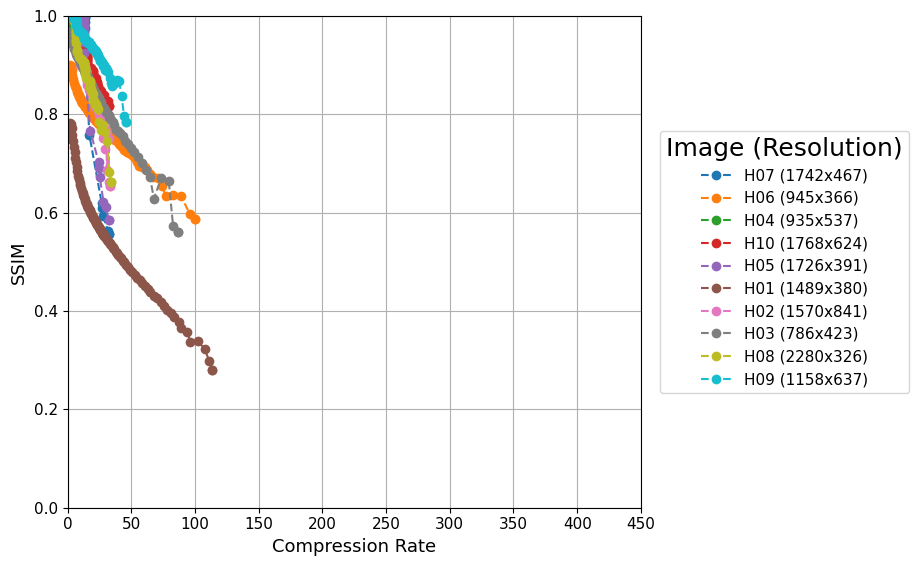

In [23]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import json

# === Configuración ===
folder_path = '../images/H_DIBCO2010_test_images_png/'
output_dir = 'compressions'
jpeg_qualities = range(1, 101)
os.makedirs(output_dir, exist_ok=True)

# Lista de imágenes (por ejemplo, nombres sin extensión)
image_names = [os.path.splitext(f)[0] for f in os.listdir(folder_path) if f.endswith('.png')]

# === Función para leer resolución real ===
def get_image_resolution(image_path: str):
    """Devuelve la resolución (ancho x alto) si el archivo existe."""
    if os.path.exists(image_path):
        with Image.open(image_path) as img:
            w, h = img.size
        return f"{w}x{h}"
    return "?"


data = {}
# === Figura ===
fig, ax = plt.subplots(figsize=(12, 6))

# === Iterar imágenes ===
for index in range(min(10, len(image_names))):  # solo las primeras 10
    image_name = image_names[index]
    image_path = os.path.join(folder_path, image_name + ".png")
    output_path = os.path.join(output_dir, f"compressed_image_jpeg_{image_name}")

    ssim_values = []
    compression_rates = []

    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)

    # === Leer resolución ===
    resolution = get_image_resolution(image_path)
    label = f"{image_name} ({resolution})"

    ax.plot(compression_rates, ssim_values, 'o--', markersize=6, label=label)


    data[image_name] = {
            "compression_rates": compression_rates,
            "ssim_values": ssim_values,
            "resolution": resolution,
        }
    
    with open("jpeg_results_h.json", "w") as f:
        json.dump(data, f)


# === Estética ===
ax.set_ylim(0, 1)
ax.set_xlim(0, 500)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)

# === Leyenda fuera del gráfico ===
ax.legend(
    #fontsize="small",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Image (Resolution)"
)

fig.tight_layout(rect=[0, 0, 0.8, 1])  # deja espacio para la leyenda
fig.savefig("jpeg_global_H.png", dpi=300, bbox_inches="tight")
plt.show()

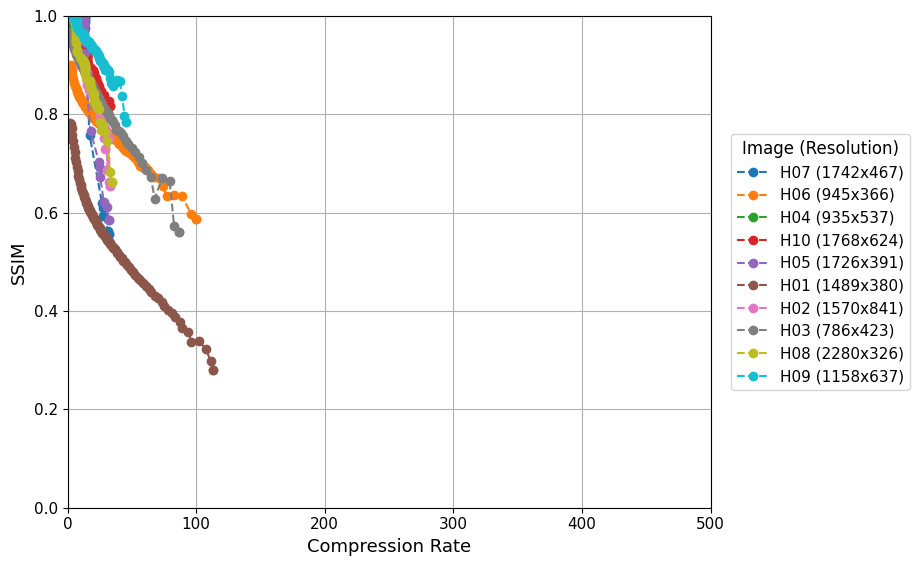

In [115]:
import json
import matplotlib.pyplot as plt

with open("jpeg_results_h.json", "r") as f:
    data = json.load(f)

fig, ax = plt.subplots(figsize=(12, 6))

for image_name, vals in data.items():
    ax.plot(vals["compression_rates"], vals["ssim_values"], 'o--', markersize=6,
            label=f"{image_name} ({vals['resolution']})")

ax.set_ylim(0, 1)
ax.set_xlim(0, 500)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, title="Image (Resolution)")

fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("jpeg_global_H.png", dpi=300, bbox_inches="tight")
plt.show()

### DIV2K

0. Study name: multiobjTPE_trials:100_seed:42_image:0878_time:2025-09-25, Trials: 100
1. Study name: multiobjTPE_trials:100_seed:42_image:0850_time:2025-09-25, Trials: 100
2. Study name: multiobjTPE_trials:100_seed:42_image:0844_time:2025-09-25, Trials: 100
3. Study name: multiobjTPE_trials:100_seed:42_image:0893_time:2025-09-26, Trials: 100
4. Study name: multiobjTPE_trials:100_seed:42_image:0887_time:2025-09-26, Trials: 100
5. Study name: multiobjTPE_trials:100_seed:42_image:0886_time:2025-09-26, Trials: 100
6. Study name: multiobjTPE_trials:100_seed:42_image:0892_time:2025-09-26, Trials: 200
7. Study name: multiobjTPE_trials:100_seed:42_image:0845_time:2025-09-26, Trials: 131
8. Study name: multiobjTPE_trials:100_seed:42_image:0851_time:2025-09-27, Trials: 100
9. Study name: multiobjTPE_trials:100_seed:42_image:0879_time:2025-09-28, Trials: 100
10. Study name: multiobjTPE_trials:100_seed:42_image:0847_time:2025-09-28, Trials: 100
11. Study name: multiobjTPE_trials:100_seed:42_image:

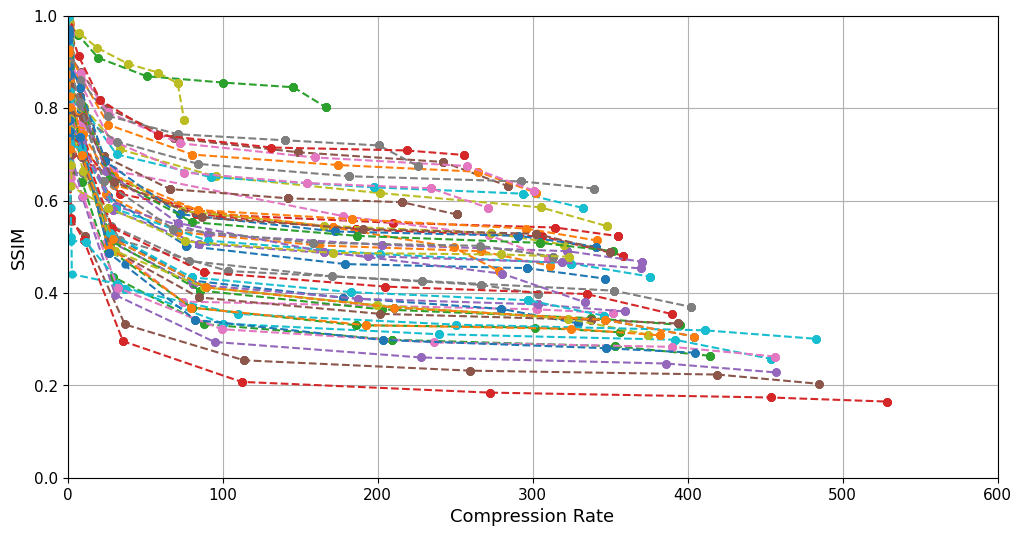

In [119]:
import optuna
import matplotlib.pyplot as plt

storage_path = "sqlite:///optuna.db"

# Get all studies
studies = optuna.study.get_all_study_summaries(storage=storage_path)

# Filter studies by prefix
images_prefix = "multiobjTPE_trials:100_seed:42_image:0"  
kk_filtered_studies = [s for s in studies if s.study_name.startswith(images_prefix)]

# Optional: print studies with more than 90 trials

for idx, s in enumerate(kk_filtered_studies):
    if s.n_trials > 90:
        print(f"{idx}. Study name: {s.study_name}, Trials: {s.n_trials}")

# Plot Pareto fronts
fig, ax = plt.subplots(figsize=(12, 6))

for s in kk_filtered_studies:
    study_name = s.study_name
    study = optuna.load_study(study_name=study_name, storage=storage_path)

    compression_rates = [trial.user_attrs.get("compression_rate") for trial in study.trials if "compression_rate" in trial.user_attrs]
    ssim_values = [trial.user_attrs.get("ssim") for trial in study.trials if "ssim" in trial.user_attrs]

    # Skip if no data
    if not compression_rates or not ssim_values:
        continue

    # Extract Pareto front (sort by compression, objective 0)
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]

    ax.plot(pareto_compression, pareto_ssim, 'o--', markersize=5, label=study_name)

ax.set_ylim(0, 1)
ax.set_xlim(0, 600)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)
#ax.legend(fontsize="small", loc="best")

fig.savefig("pareto_fronts_div2k.png", dpi=300)
plt.show()

In [32]:
storage_path = "sqlite:///optuna.db"

studies = optuna.study.get_all_study_summaries(storage=storage_path)

kk_filtered_studies_names = [s.study_name for s in studies if s.study_name.startswith(images_prefix)]

image_codes = [name.split("image:")[1].split("_")[0] for name in kk_filtered_studies_names][:-1]
print(image_codes)

['0878', '0850', '0844', '0893', '0887', '0886', '0892', '0845', '0851', '0879', '0847', '0853', '0884', '0890', '0891', '0885', '0852', '0846', '0842', '0856', '0858', '0881', '0866', '0895', '0872', '0894', '0880', '0857', '0843', '0855', '0841', '0839', '0805', '0811', '0810', '0804', '0838', '0814', '0828', '0829', '0815', '0801', '0817', '0803', '0802', '0816', '0859', '0871', '0865', '0864', '0870']


In [36]:
from collections import Counter

repeated = [item for item, count in Counter(image_codes).items() if count > 1]
print(repeated)

[]


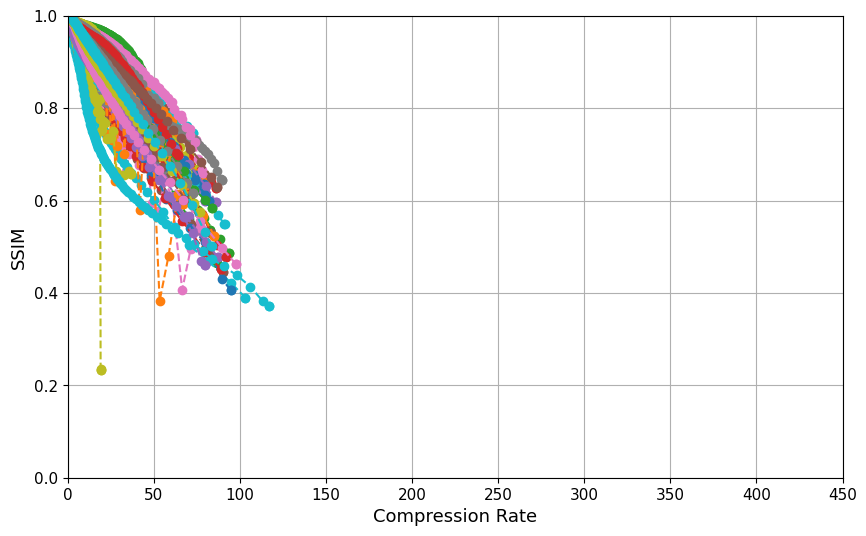

In [37]:
data = {}
folder_path = '../images/DIV2K_valid_HR/DIV2K_valid_HR/'
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression
fig, ax = plt.subplots(figsize=(12, 6))
for index in range(50):
    image_name = image_codes[index]
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path
    output_path = "compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)
    ax.plot(compression_rates, ssim_values, 'o--', markersize=6)
    
    data[image_name] = {
        "compression_rates": compression_rates,
        "ssim_values": ssim_values,
        "resolution": resolution,
    }

    with open("jpeg_results_div2k.json", "w") as f:
        json.dump(data, f)

plt.ylim(0, 1)
ax.set_xlim(0, 450)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
#ax.legend()
ax.grid(True)
fig.savefig(f"jpeg_global_div2k.png", dpi=300)
plt.show()

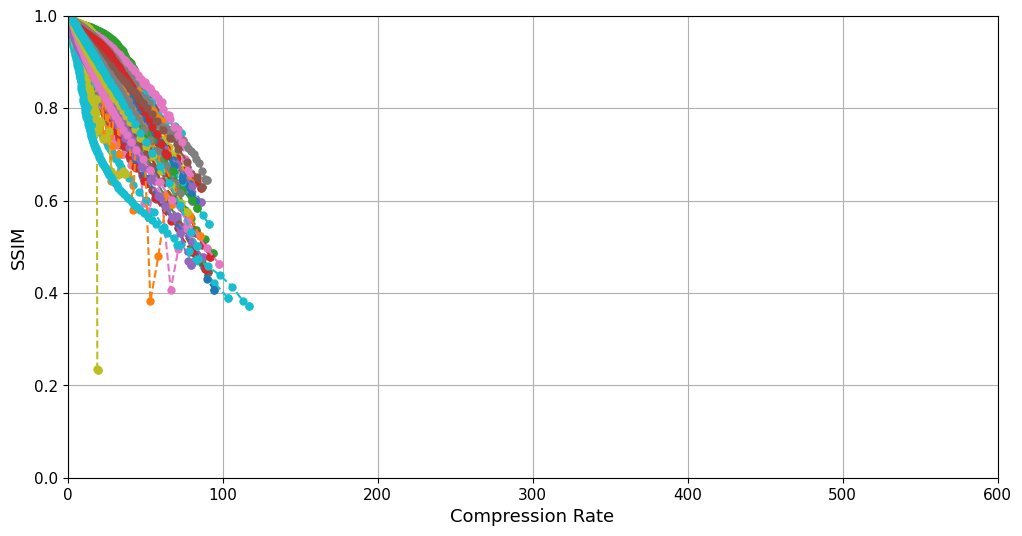

In [121]:
import json
import matplotlib.pyplot as plt

with open("jpeg_results_div2k.json", "r") as f:
    data = json.load(f)

fig, ax = plt.subplots(figsize=(12, 6))

for image_name, vals in data.items():
    ax.plot(vals["compression_rates"], vals["ssim_values"], 'o--', markersize=5)#,
           # label=f"{image_name} ({vals['resolution']})")

ax.set_ylim(0, 1)
ax.set_xlim(0, 600)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)
#ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, title="Image (Resolution)")

#fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("jpeg_div2k.png", dpi=300, bbox_inches="tight")
plt.show()

### USC database

In [56]:
study_names_usc_new = [
    "multiobjTPE_trials:100_seed:42_image:4.1.08_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.04_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.05_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.07_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.06_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.02_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:4.1.03_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-09-30",
    "multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-09-30",
]

In [57]:
storage_path_study_names_usc_old = "sqlite:///aqmp_studies.db"

study_names_usc_old = ['multiobjTPE_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13',
                         'multiobjTPE_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08',
                         'multiobjTPE_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06',
                         'multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52',
                         'multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04',
                         'multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08']

image_names_usc_old = [
'Female_(NTSC_test_image)',
'San_Diego',
'San_Francisco',
'Splash',
'Clock_rgb',
'Airplane_(U-2)_rgb'
]

In [58]:
storage = "sqlite:///aqmp_studies.db"
summaries = optuna.study.get_all_study_summaries(storage)
summaries_usc_old = [s for s in summaries if s.study_name in study_names_usc_old]
print(f"✅ Found {len(summaries_usc_old)} matching studies")

for idx, s in enumerate(summaries_usc_old):
    if s.n_trials > 90:
        print(f"{idx}. Study name: {s.study_name}, Trials: {s.n_trials}")

✅ Found 6 matching studies
0. Study name: multiobjTPE_trials:100_seed:42_image:San_Diego_time:2025-04-14_12-00-08, Trials: 100
1. Study name: multiobjTPE_trials:100_seed:42_image:Splash_time:2025-04-14_13-06-52, Trials: 100
2. Study name: multiobjTPE_trials:100_seed:42_image:Female_(NTSC_test_image)_time:2025-04-14_14-05-13, Trials: 100
3. Study name: multiobjTPE_trials:100_seed:42_image:San_Francisco_time:2025-04-14_17-06-06, Trials: 100
4. Study name: multiobjTPE_trials:100_seed:43_image:Clock_rgb_time:2025-05-14_19-12-04, Trials: 100
5. Study name: multiobjTPE_trials:100_seed:43_image:Airplane_(U-2)_rgb_time:2025-05-14_19-20-08, Trials: 100


In [59]:
storage = "sqlite:///optuna.db"
summaries = optuna.study.get_all_study_summaries(storage)
summaries_usc_new = [s for s in summaries if s.study_name in study_names_usc_new]
print(f"✅ Found {len(summaries_usc_new)} matching studies")

for idx, s in enumerate(summaries_usc_new):
    if s.n_trials > 90:
        print(f"{idx}. Study name: {s.study_name}, Trials: {s.n_trials}")

✅ Found 9 matching studies
0. Study name: multiobjTPE_trials:100_seed:42_image:4.1.08_time:2025-09-30, Trials: 100
1. Study name: multiobjTPE_trials:100_seed:42_image:4.1.04_time:2025-09-30, Trials: 100
2. Study name: multiobjTPE_trials:100_seed:42_image:4.1.05_time:2025-09-30, Trials: 100
3. Study name: multiobjTPE_trials:100_seed:42_image:4.1.07_time:2025-09-30, Trials: 100
4. Study name: multiobjTPE_trials:100_seed:42_image:4.1.06_time:2025-09-30, Trials: 100
5. Study name: multiobjTPE_trials:100_seed:42_image:4.1.02_time:2025-09-30, Trials: 100
6. Study name: multiobjTPE_trials:100_seed:42_image:4.1.03_time:2025-09-30, Trials: 100
7. Study name: multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-09-30, Trials: 100
8. Study name: multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-09-30, Trials: 100


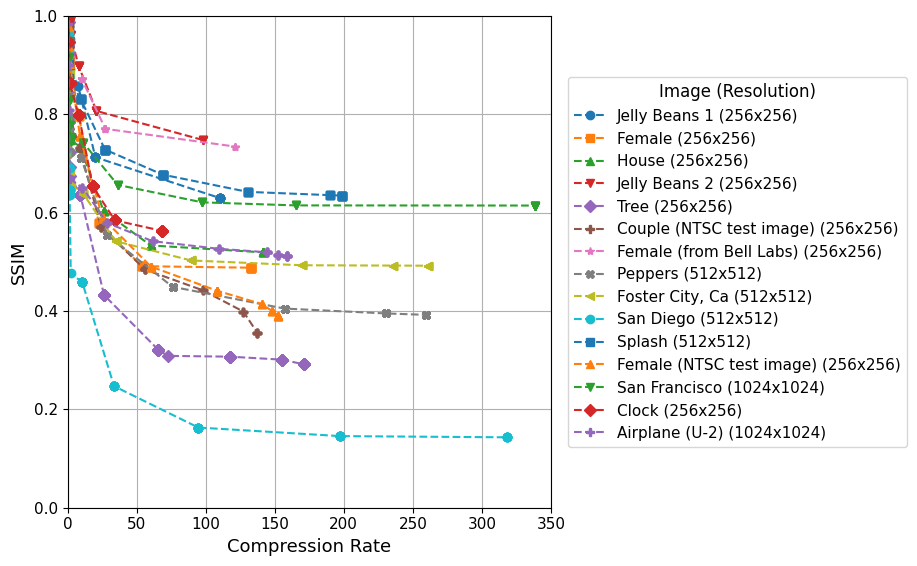

In [104]:
import itertools
import matplotlib.pyplot as plt
import optuna
import re

fig, ax = plt.subplots(figsize=(12, 6))

image_names_not_code = {
    "4.1.02": "Couple (NTSC test image)",
    "4.1.03": "Female (from Bell Labs)",
    "4.1.04": "Female",
    "4.1.05": "House",
    "4.1.06": "Tree",
    "4.1.07": "Jelly Beans 2",
    "4.1.08": "Jelly Beans 1"
}

# Combine both sources
all_summaries = [(s, "sqlite:///optuna.db") for s in summaries_usc_new] + \
                [(s, "sqlite:///aqmp_studies.db") for s in summaries_usc_old]

# Distinct marker shapes and colors
marker_styles = itertools.cycle(['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<'])
color_styles = itertools.cycle(plt.cm.tab10.colors)  # 10 distinct, repeat safely

style_map = {}  # map image_name -> (marker, color)

for s, storage in all_summaries:
    study_name = s.study_name
    study = optuna.load_study(study_name=study_name, storage=storage)

    # Extract Pareto front
    pareto_front = sorted(study.best_trials, key=lambda t: t.values[0])
    pareto_compression = [trial.values[0] for trial in pareto_front]
    pareto_ssim = [trial.values[1] for trial in pareto_front]

    # Extract image name
    img_match = re.search(r"_image:(.*?)_time:", study_name)
    img_name = img_match.group(1) if img_match else "unknown"

    resolution = get_image_resolution(img_name)

    # After extracting img_name from study_name:
    if img_name in image_names_not_code:
        label_img_name = image_names_not_code[img_name]
    else:
        label_img_name = img_name.replace("_", " ")
    
    if label_img_name.endswith("rgb"):
        label_img_name = label_img_name[:-3].rstrip()

    # Assign consistent marker and color per image
    if img_name not in style_map:
        style_map[img_name] = (next(marker_styles), next(color_styles))
    marker, color = style_map[img_name]

    label = f"{label_img_name} ({resolution})"
    ax.plot(
        pareto_compression,
        pareto_ssim,
        marker=marker,
        linestyle='--',
        markersize=6,
        color=color,
        label=label
    )

# === Axis settings ===
ax.set_ylim(0, 1)
ax.set_xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)

# === Legend outside the figure ===
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Image (Resolution)"
)

fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("pareto_global_usc.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
import re

def extract_image_name(study_name: str) -> str:
    """
    Extract everything after '_image:' up to the next '_time' (or up to the next comma/space/end).
    Keeps dots, commas, spaces, underscores, etc.
    """
    start_marker = '_image:'
    start = study_name.find(start_marker)
    if start == -1:
        return "unknown"
    start += len(start_marker)

    # Look for the next '_time' (with or without colon)
    end = study_name.find('_time', start)
    if end != -1:
        # If '_time' found, use that as end (stop before '_time')
        img = study_name[start:end]
    else:
        # No '_time' found: stop at next comma or the end of the string or newline
        m = re.search(r'[,\s]', study_name[start:])
        if m:
            end = start + m.start()
            img = study_name[start:end]
        else:
            img = study_name[start:]

    # Clean up accidental trailing separators/spaces
    return img.strip().rstrip(',').strip()

# --- Quick tests on your examples ---
examples = [
    "multiobjTPE_trials:100_seed:42_image:4.1.08_time:2025-09-30, Trials: 100",
    "multiobjTPE_trials:100_seed:42_image:4.1.04_time:2025-09-30, Trials: 100",
    "multiobjTPE_trials:100_seed:42_image:4.1.03_time:2",
    "multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-09-30, Trials: 100",
    "multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-09-30, Trials: 100",
    "multiobjTPE_trials:100_seed:42_image:4.1.03_time:2025-09-30"
]

for s in examples:
    print(s, "->", extract_image_name(s))


multiobjTPE_trials:100_seed:42_image:4.1.08_time:2025-09-30, Trials: 100 -> 4.1.08
multiobjTPE_trials:100_seed:42_image:4.1.04_time:2025-09-30, Trials: 100 -> 4.1.04
multiobjTPE_trials:100_seed:42_image:4.1.03_time:2 -> 4.1.03
multiobjTPE_trials:100_seed:42_image:Peppers_time:2025-09-30, Trials: 100 -> Peppers
multiobjTPE_trials:100_seed:42_image:Foster_City,_Ca_time:2025-09-30, Trials: 100 -> Foster_City,_Ca
multiobjTPE_trials:100_seed:42_image:4.1.03_time:2025-09-30 -> 4.1.03


In [41]:
all_image_names_usc = [
    "San_Diego",
    "Splash",
    "Female_(NTSC_test_image)",
    "San_Francisco",
    "Clock_rgb",
    "Airplane_(U-2)_rgb",
    "4.1.08",
    "4.1.04",
    "4.1.05",
    "4.1.07",
    "4.1.06",
    "4.1.02",
    "4.1.03",
    "Peppers",
    "Foster_City,_Ca"
]

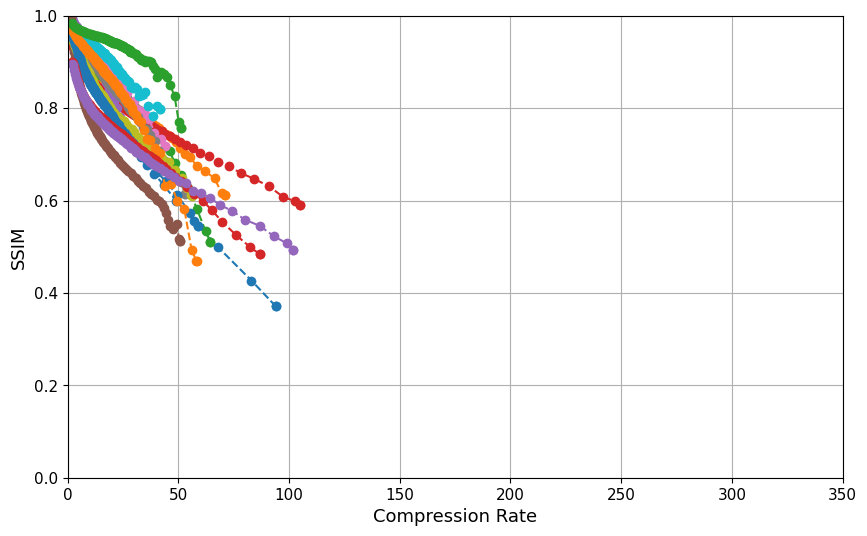

In [42]:
data = {}
folder_path = '../images/usc_images/'
jpeg_qualities = range(1, 101) # Range of qualities for JPEG compression
fig, ax = plt.subplots(figsize=(10, 6))
for index in range(15):
    image_name = all_image_names_usc[index]
    image_path = f"{folder_path}{image_name}.png" # Replace with your image path
    output_path = "compressions/compressed_image_jpeg_"+image_name
    ssim_values = []
    compression_rates = []
    for quality in jpeg_qualities:
        ssim_val, comp_rate = jpeg_compress_and_evaluate(image_path, output_path, quality)
        ssim_values.append(ssim_val)
        compression_rates.append(comp_rate)

    data[image_name] = {
        "compression_rates": compression_rates,
        "ssim_values": ssim_values,
        "resolution": resolution,
    }

    with open("jpeg_results_usc.json", "w") as f:
        json.dump(data, f)
        
    ax.plot(compression_rates, ssim_values, 'o--', markersize=6)

plt.ylim(0, 1)
plt.xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
#ax.legend()
ax.grid(True)
fig.savefig(f"jpeg_global_usc.png", dpi=300)
plt.show()

hacer graficos con misma escala de eje x

hacer una curva para cada conjunto de imagenes

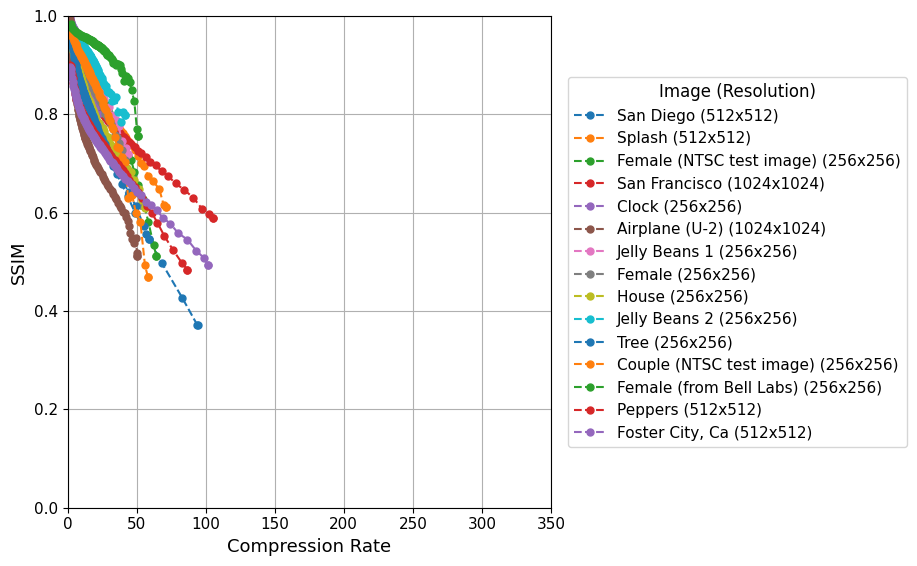

In [116]:
import json
import matplotlib.pyplot as plt

# === Load JSON results ===
with open("jpeg_results_usc.json", "r") as f:
    data = json.load(f)

fig, ax = plt.subplots(figsize=(12, 6))

for image_name, vals in data.items():
    compression_rates = vals["compression_rates"]
    ssim_values = vals["ssim_values"]
    #resolution = vals.get("resolution", "?")  # fallback if not in JSON
    resolution = get_image_resolution(image_name)

    if image_name in image_names_not_code:
        label_img_name = image_names_not_code[image_name]
    else:
        label_img_name = image_name.replace("_", " ")
    
    if label_img_name.endswith("rgb"):
        label_img_name = label_img_name[:-3].rstrip()
    
    # Plot with formatted label
    ax.plot(compression_rates, ssim_values, 'o--', markersize=5,
            label=f"{label_img_name} ({resolution})")

# === Axis settings ===
ax.set_ylim(0, 1)
ax.set_xlim(0, 350)
ax.set_xlabel("Compression Rate")
ax.set_ylabel("SSIM")
ax.grid(True)

# === Legend outside the figure ===
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Image (Resolution)"
)

fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("jpeg_global_usc.png", dpi=300, bbox_inches="tight")
plt.show()
